# Sidra: Heat on surrounding land

We looked at land that was already there before Diyar was built and compared it with coastal land farther away. The question was whether summer surface temperatures had changed differently in the two areas.

The temperature gap increased by 0.67°C. When we resampled whole years and areas, the interval ran from −0.13 to +1.23°C. Since it includes zero, this comparison is inconclusive on its own. The model picked seven cells for a field visit, five of which kept appearing when we changed the model or control group.

These results can help planners decide where to take measurements. Landsat gives us surface temperatures, while ERA5 supplies regional air temperature at 2 m above the ground. The ERA5 grid is much coarser than our 120 m cells, so measurements at the shortlisted sites would help check local air temperatures and heat exposure.

| Topic | Sections |
| --- | --- |
| Temperature change and the study area | 1–2 |
| Alternative comparisons and uncertainty | 3 |
| Prediction model and inspection shortlist | 4–5 |
| Planning a field visit | 6 |


## Setup

The figures and tables are saved in the notebook. If you just want to read the results, skip to [Section 1](#temperature-change).

To run the analysis, install the packages in the root `requirements.txt` using the [README](../README.md), select that environment in Jupyter, and run the cells in order. We used Python 3.14. The setup code is grouped below and can be folded in viewers that support it.


In [1]:
import os
import sys
from pathlib import Path
from importlib.util import find_spec

start_directory = Path.cwd()
# Find the project root when Jupyter starts in notebooks/.
project_root = next((p for p in [start_directory, *start_directory.parents]
                     if (p / "notebooks/02_surrounding_land_heat.ipynb").is_file()
                     and (p / "requirements.txt").is_file()), start_directory)
WORKDIR = Path(os.environ.get("SIDRA_ROOT", project_root)).resolve()
WORKDIR.mkdir(parents=True, exist_ok=True)

cache = WORKDIR / "data/expanded"
cache_candidates = ([Path(os.environ["SIDRA_INPUT_CACHE"])]
    if "SIDRA_INPUT_CACHE" in os.environ else
    [p / "data/expanded" for p in [start_directory, *start_directory.parents]])
markers = ["landsat_manifest.json", "sentinel_pairs.json", "weather/manifest.json",
           "landcover/manifest.json", "timeline/manifest.json"]
if not cache.exists():
    available = next((p.resolve() for p in cache_candidates
                      if all((p / marker).is_file() for marker in markers)), None)
    if available is not None:
        cache.parent.mkdir(parents=True, exist_ok=True)
        cache.symlink_to(available, target_is_directory=True)
os.chdir(WORKDIR)
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

required = ["numpy", "pandas", "scipy", "sklearn", "rasterio", "planetary_computer",
            "pystac_client", "matplotlib", "xarray", "icechunk", "eccodes", "netCDF4"]
missing = [name for name in required if find_spec(name) is None]
if missing:
    print("Missing packages:", ", ".join(missing))
    print("Install requirements.txt as described in the README, then restart the kernel.")
print("Local input and output folders are ready.")


Local input and output folders are ready.


In [2]:
def resolve_product(collection, record):
    """Read a saved STAC record, or retrieve the exact catalogue ID listed below."""
    if "item" in record:
        return Item.from_dict(record["item"])
    if record.get("type") == "Feature":
        return Item.from_dict(record)
    item = Client.open(CATALOG).get_collection(collection).get_item(record["id"])
    if item is None or item.id != record["id"]:
        raise RuntimeError(f"Product unavailable: {record['id']}")
    return item

### Study settings

We use UTM zone 39N and a 120 m analysis grid. This matches Landsat 5's native thermal resolution, the coarsest in the study.


In [3]:
"""Study configuration. Bounds are an initial inspection box, not a cadastral outline."""

from dataclasses import dataclass
from pathlib import Path


@dataclass(frozen=True)
class Study:
    name: str = "Diyar Al Muharraq inspection area"
    # lon/lat WGS84: includes the reclaimed islands and surrounding open water.
    bbox: tuple[float, float, float, float] = (50.595, 26.276, 50.676, 26.354)
    # Provisional Diyar focus box; inspect against imagery before interpreting area totals.
    focus_bbox: tuple[float, float, float, float] = (50.595, 26.290, 50.655, 26.354)
    epsg: int = 32639
    pixel_metres: int = 100  # Native Landsat 8/9 TIRS resolution.
    # Landsat 7 before its May 2003 scan-line corrector failure.
    baseline_start: str = "2000-05-01"
    baseline_end: str = "2002-10-31"
    current_start: str = "2023-05-01"
    current_end: str = "2025-10-31"


DEFAULT_STUDY = Study()
# Wider window for existing-land exposure analysis. It reaches farther into
# Muharraq so candidate controls can be evaluated outside the Diyar shore.
EXPOSURE_STUDY = Study(
    name="Muharraq coastline exposure study",
    bbox=(50.55, 26.22, 50.72, 26.355),
)
DATA = Path("data")
SCENES = DATA / "scenes"
EXPOSURE_SCENES = DATA / "exposure_scenes"
RESULTS = Path("outputs")

### Spectral indices and spatial groups

The functions below calculate the optical indices, water masks, shoreline distances and spatial blocks used later.


In [4]:
"""Optical indices, water masks and shoreline distances."""

import numpy as np
from scipy.ndimage import binary_erosion, distance_transform_edt


def safe_index(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    with np.errstate(divide="ignore", invalid="ignore"):
        out = (a - b) / (a + b)
    out[~np.isfinite(out)] = np.nan
    return out


def indices(bands: dict[str, np.ndarray]) -> dict[str, np.ndarray]:
    return {
        "ndvi": safe_index(bands["nir08"], bands["red"]),
        "mndwi": safe_index(bands["green"], bands["swir16"]),
        "ndbi": safe_index(bands["swir16"], bands["nir08"]),
        "brightness": (bands["red"] + bands["green"] + bands["blue"]) / 3,
        "nir08": bands["nir08"],
        "swir16": bands["swir16"],
    }


def water_mask(ix: dict[str, np.ndarray], valid: np.ndarray) -> np.ndarray:
    """Conservative optical water mask; needs visual review in shallow Gulf water."""
    # Atmospheric correction can produce slightly negative NIR over dark water,
    # making NDVI spuriously positive. Use absolute low NIR rather than NDVI.
    # SWIR is strongly absorbed by water; a fixed MNDWI cutoff proved unstable
    # across otherwise clear Bahrain summer scenes during visual inspection.
    return valid & (ix["mndwi"] > 0.0) & (ix["nir08"] < 0.08) & (ix["swir16"] < 0.07)


def reclamation_mask(old_water: np.ndarray, new_water: np.ndarray,
                     old_valid: np.ndarray, new_valid: np.ndarray) -> np.ndarray:
    """Remove one pixel at boundaries to limit mixed water/land thermal pixels."""
    raw = old_water & ~new_water & old_valid & new_valid
    return binary_erosion(raw, iterations=1)


def distance_to_water(water: np.ndarray, pixel_metres: float) -> np.ndarray:
    return distance_transform_edt(~water).astype(np.float32) * pixel_metres


def water_reference(lst_c: np.ndarray, water: np.ndarray,
                    pixel_metres: float) -> float:
    """Same-scene offshore reference; avoid edge mixing near the shoreline."""
    interior = water & (distance_transform_edt(water) * pixel_metres >= 300)
    values = lst_c[interior & np.isfinite(lst_c)]
    if values.size < 15:
        raise ValueError("Too few valid offshore water pixels for a reference")
    return float(np.median(values))


def spatial_blocks(shape: tuple[int, int], block_pixels: int = 10) -> np.ndarray:
    y, x = np.indices(shape)
    return (y // block_pixels) * (int(np.ceil(shape[1] / block_pixels))) + x // block_pixels

### Landsat catalogue and grid

This sets up the Landsat search, shared grid and quality mask.


In [5]:
"""Fetch windowed Landsat Collection 2 L2 scenes from Microsoft Planetary Computer."""

import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import planetary_computer
import rasterio
from pystac_client import Client
from rasterio.enums import Resampling
from rasterio.transform import from_origin
from rasterio.vrt import WarpedVRT
from rasterio.warp import transform_bounds


REFLECTANCE = ("blue", "green", "red", "nir08", "swir16")
COMMON_ASSETS = (*REFLECTANCE, "qa_pixel")
CATALOG = "https://planetarycomputer.microsoft.com/api/stac/v1"


def grid(study: Study = DEFAULT_STUDY):
    west, south, east, north = transform_bounds("EPSG:4326", f"EPSG:{study.epsg}", *study.bbox)
    p = study.pixel_metres
    west, south = np.floor([west / p, south / p]) * p
    east, north = np.ceil([east / p, north / p]) * p
    width, height = int((east - west) / p), int((north - south) / p)
    return rasterio.crs.CRS.from_epsg(study.epsg), from_origin(west, north, p, p), width, height


def search(start: str, end: str, platform: str | None = None, max_cloud: float = 30,
           require_thermal: bool = True, raw: bool = False,
           study: Study = DEFAULT_STUDY) -> list:
    catalog = Client.open(CATALOG, modifier=planetary_computer.sign_inplace)
    query_fields = {"eo:cloud_cover": {"lt": max_cloud}}
    if platform:
        query_fields["platform"] = {"eq": platform}
    query = catalog.search(
        collections=["landsat-c2-l2"], bbox=list(study.bbox),
        datetime=f"{start}/{end}",
        query=query_fields,
        max_items=200,
    )
    items = list(query.items())
    if raw:
        return items
    # Restrict all comparisons to a common hot-season window.
    return [item for item in items if item.datetime.month in (6, 7, 8, 9)
            and all(name in item.assets for name in COMMON_ASSETS)
            and (not require_thermal or any(key in item.assets for key in ("lwir11", "lwir")))]


def choose(items: list, limit: int) -> list:
    """Take clear scenes across years, avoiding near-duplicate acquisition dates."""
    items = sorted(items, key=lambda i: (i.properties.get("eo:cloud_cover", 100), i.datetime))
    chosen = []
    for item in items:
        if any(abs((item.datetime - other.datetime).days) < 35 for other in chosen):
            continue
        chosen.append(item)
        if len(chosen) == limit:
            break
    return sorted(chosen, key=lambda i: i.datetime)


def read_asset(item, name: str, crs, transform, width: int, height: int) -> np.ndarray:
    href = item.assets[name].href
    nearest = name == "qa_pixel"
    with rasterio.Env(GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR", GDAL_HTTP_MAX_RETRY="3"):
        with rasterio.open(href) as src:
            with WarpedVRT(src, crs=crs, transform=transform, width=width, height=height,
                           resampling=Resampling.nearest if nearest else Resampling.bilinear) as vrt:
                return vrt.read(1, masked=True).filled(0).astype(np.uint16 if nearest else np.float32)


def decode_qa(qa: np.ndarray) -> np.ndarray:
    # USGS QA_PIXEL bits: fill, dilated cloud, cirrus, cloud, shadow, snow.
    bad = sum(1 << bit for bit in (0, 1, 2, 3, 4, 5))
    return (qa & bad) == 0


def download(item, era: str, out_dir: Path = SCENES, study: Study = DEFAULT_STUDY) -> Path:
    out_dir.mkdir(parents=True, exist_ok=True)
    out = out_dir / f"{era}_{item.datetime:%Y%m%d}_{item.id}.npz"
    if out.exists():
        return out
    crs, transform, width, height = grid(study)
    thermal = "lwir11" if "lwir11" in item.assets else ("lwir" if "lwir" in item.assets else None)
    asset_names = (*COMMON_ASSETS, thermal) if thermal else COMMON_ASSETS
    raw = {name: read_asset(item, name, crs, transform, width, height) for name in asset_names}
    valid = decode_qa(raw["qa_pixel"])
    bands = {}
    for name in REFLECTANCE:
        arr = raw[name] * 0.0000275 - 0.2
        arr[(raw[name] == 0) | ~valid] = np.nan
        bands[name] = arr.astype(np.float32)
    if thermal:
        lst = raw[thermal] * 0.00341802 + 149.0 - 273.15
        lst[(raw[thermal] == 0) | ~valid] = np.nan
    else:
        lst = np.full((height, width), np.nan, dtype=np.float32)
    meta = {
        "id": item.id, "date": item.datetime.isoformat(), "era": era,
        "cloud_cover_scene_percent": item.properties.get("eo:cloud_cover"),
        "platform": item.properties.get("platform"), "bbox": study.bbox,
        "epsg": study.epsg, "pixel_metres": study.pixel_metres,
        "source": CATALOG, "collection": "landsat-c2-l2",
        "assets": {name: item.assets[name].get_absolute_href().split("?")[0] for name in asset_names},
        "retrieved_utc": datetime.now(timezone.utc).isoformat(),
    }
    np.savez_compressed(out, **bands, lst_c=lst.astype(np.float32),
                        valid=valid, metadata=json.dumps(meta))
    return out

In [6]:
def fetch(era: str, limit: int) -> list[Path]:
    start = getattr(DEFAULT_STUDY, f"{era}_start")
    end = getattr(DEFAULT_STUDY, f"{era}_end")
    platform = "landsat-7" if era == "baseline" else "landsat-8"
    selected = choose(search(start, end, platform, require_thermal=era != "baseline"), limit)
    if not selected:
        raise RuntimeError(f"No suitable Landsat L2SP scenes for {era} in {start}–{end}")
    result = []
    for index, item in enumerate(selected, 1):
        print(f"[{index}/{len(selected)}] {era}: {item.id} ({item.datetime.date()})", flush=True)
        result.append(download(item, era))
    return result

### Landsat and Sentinel retrieval

Clouds and other invalid samples are removed before the data are aggregated. We leave the gaps empty.


In [7]:
"""Reproducible, windowed inputs for the expanded Diyar notebook.

The 120 m analysis grid respects the coarsest native thermal resolution (L5).
QA is applied on the 30 m product grid BEFORE aggregation, with no gap filling.
Native-resolution Sentinel crops are retained as well as 120 m aggregates.
"""
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import replace
from datetime import datetime, timedelta, timezone
import hashlib
import json
from pathlib import Path
import time
import xml.etree.ElementTree as ET

import numpy as np
import planetary_computer as pc
from pystac import Item
from pystac_client import Client
import rasterio
from rasterio.enums import Resampling
from rasterio.vrt import WarpedVRT
import requests


# The inherited 50.655°E focus edge cut through the connected northeast fill.
# 50.660°E retains its 25-cell fringe; largest-component filtering still applies.
# This is a satellite-analysis search box, not an official project boundary.
STUDY = replace(EXPOSURE_STUDY, pixel_metres=120,
                focus_bbox=(50.595, 26.290, 50.660, 26.354))
INPUT = Path("data/expanded")
OPTICAL = ("blue", "green", "red", "nir08", "swir16", "swir22")
S2_BANDS = {"B02": "blue", "B03": "green", "B04": "red", "B08": "nir08",
            "B11": "swir16", "B12": "swir22"}
ERAS = {"before": (2000, 2005, 20), "transition": (2006, 2014, 10),
        "recent": (2023, 2025, 20)}


def reduce_mean(a, factor):
    h, w = a.shape
    block = a.reshape(h // factor, factor, w // factor, factor)
    count = np.isfinite(block).sum(axis=(1, 3))
    total = np.nansum(block, axis=(1, 3))
    return np.divide(total, count, out=np.full(total.shape, np.nan, dtype=np.float32), where=count > 0)


def reduce_fraction(a, factor):
    h, w = a.shape
    return a.reshape(h // factor, factor, w // factor, factor).mean(axis=(1, 3)).astype(np.float32)


def read_crop(item, asset, pixel):
    """Nearest sampling at the product resolution; fill remains raw nodata."""
    crs, transform, width, height = grid(STUDY)
    factor = STUDY.pixel_metres // pixel
    transform = transform * rasterio.Affine.scale(1 / factor, 1 / factor)
    with rasterio.Env(GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR", GDAL_HTTP_MAX_RETRY="3",
                      GDAL_HTTP_TIMEOUT="90", VSI_CACHE="TRUE"):
        with rasterio.open(item.assets[asset].href) as src:
            with WarpedVRT(src, crs=crs, transform=transform, width=width * factor,
                           height=height * factor, resampling=Resampling.nearest) as vrt:
                return vrt.read(1, masked=True).filled(-9999 if asset == "qa" else 0)


def hash_file(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()


def meta(item, assets, **extra):
    return {"id": item.id, "date": item.datetime.isoformat(),
            "platform": item.properties.get("platform"), "bbox": list(STUDY.bbox),
            "epsg": STUDY.epsg, "pixel_metres": STUDY.pixel_metres,
            "cloud_cover_scene_percent": item.properties.get("eo:cloud_cover"),
            "source": CATALOG, "collection": item.collection_id,
            "assets": {a: item.assets[a].href.split("?")[0] for a in assets},
            "retrieved_utc": datetime.now(timezone.utc).isoformat(), **extra}


def query_year(year):
    client = Client.open(CATALOG)
    items = list(client.search(collections=["landsat-c2-l2"], bbox=list(STUDY.bbox),
        datetime=f"{year}-06-01/{year}-09-30", query={"eo:cloud_cover": {"lt": 30}}).items())
    return [i for i in items if all(a in i.assets for a in (*OPTICAL, "qa_pixel", "qa_radsat", "qa"))
            and any(a in i.assets for a in ("lwir", "lwir11"))
            and "163042" in i.id and "_T1" in i.id]


def choose_balanced(items, limit):
    """Balance months and years using metadata only, never observed temperature."""
    chosen, months, years = [], {}, {}
    while len(chosen) < limit:
        candidates = [i for i in items if i not in chosen and
                      all(abs((i.datetime - j.datetime).total_seconds()) >= 7.5 * 86400 for j in chosen)]
        if not candidates:
            break
        best = min(candidates, key=lambda i: (
            10 * months.get(i.datetime.month, 0) + 3 * years.get(i.datetime.year, 0)
            + i.properties.get("eo:cloud_cover", 100) / 100
            + (0.15 if i.properties.get("platform") == "landsat-7" and i.datetime.year >= 2003 else 0),
            i.datetime, i.id))
        chosen.append(best)
        months[best.datetime.month] = months.get(best.datetime.month, 0) + 1
        years[best.datetime.year] = years.get(best.datetime.year, 0) + 1
    return sorted(chosen, key=lambda i: i.datetime)


def select_landsat():
    selection = INPUT / "landsat_selection.json"
    if selection.exists():
        return [(r["era"], resolve_product("landsat-c2-l2", r)) for r in json.loads(selection.read_text())]
    INPUT.mkdir(parents=True, exist_ok=True)
    years = [y for first, last, _ in ERAS.values() for y in range(first, last + 1)]
    by_year = {}
    with ThreadPoolExecutor(max_workers=4) as pool:
        jobs = {pool.submit(query_year, y): y for y in years}
        for future in as_completed(jobs):
            y = jobs[future]
            by_year[y] = future.result()
            print("Catalog", y, len(by_year[y]), "eligible", flush=True)
    result = []
    for era, (first, last, target) in ERAS.items():
        items = choose_balanced([i for y in range(first, last + 1) for i in by_year[y]], target)
        if len(items) != target:
            raise RuntimeError(f"{era}: only {len(items)} of {target} requested dates available")
        result.extend((era, i) for i in items)
    selection.write_text(json.dumps([{"era": era, "item": i.to_dict()} for era, i in result], indent=2))
    return result

In [8]:
def landsat_crop(pair, *, folder=None):
    era, unsigned = pair
    folder = INPUT / "landsat" if folder is None else Path(folder)
    folder.mkdir(parents=True, exist_ok=True)
    path = folder / f"{era}_{unsigned.id}.npz"
    if path.exists():
        return path
    item = pc.sign(unsigned)
    thermal = "lwir11" if "lwir11" in item.assets else "lwir"
    assets = (*OPTICAL, "qa_pixel", "qa_radsat", "qa", thermal)
    raw = {a: read_crop(item, a, 30) for a in assets}
    valid = decode_qa(raw["qa_pixel"]) & (raw["qa_radsat"] == 0)
    valid &= np.logical_and.reduce([raw[a] != 0 for a in OPTICAL])
    arrays = {}
    for name in OPTICAL:
        a = raw[name].astype(np.float32) * 0.0000275 - 0.2
        a[~valid] = np.nan
        arrays[name] = reduce_mean(a, 4)
    st_qa = raw["qa"].astype(np.float32) * 0.01
    thermal_valid = valid & (raw[thermal] != 0) & (raw["qa"] >= 0)
    lst = raw[thermal].astype(np.float32) * 0.00341802 + 149 - 273.15
    # Store unthresholded aggregate for independently reproducible uncertainty sensitivity.
    lst[~thermal_valid] = np.nan
    arrays["lst_c"] = reduce_mean(lst, 4)
    arrays["optical_clear_fraction"] = reduce_fraction(valid, 4)
    arrays["thermal_clear_fraction"] = reduce_fraction(thermal_valid, 4)
    # A conservative cell uncertainty: maximum among its valid product-grid samples.
    q = np.where(thermal_valid, st_qa, -np.inf)
    h, w = q.shape
    arrays["st_qa_k"] = q.reshape(h // 4, 4, w // 4, 4).max(axis=(1, 3))
    arrays["st_qa_k"][~np.isfinite(arrays["st_qa_k"])] = np.nan
    arrays.update(raw_qa_pixel_30m=raw["qa_pixel"], raw_qa_radsat_30m=raw["qa_radsat"],
                  raw_st_qa_30m=raw["qa"])
    metadata = meta(unsigned, assets, era=era, optical_scale=0.0000275, optical_offset=-0.2,
        temperature_scale=0.00341802, temperature_offset_k=149, uncertainty_scale_k=0.01,
        qa_rule="QA_PIXEL bits 0..5 clear; QA_RADSAT=0; nonzero optical/thermal DN; ST_QA>=0",
        aggregate_rule="30m product samples ->120m mean; require clear_fraction>=0.8 in analysis; maximum valid ST_QA",
        native_thermal_metres={"landsat-5": 120, "landsat-7": 60, "landsat-8": 100, "landsat-9": 100}[unsigned.properties["platform"]])
    np.savez_compressed(path, **arrays, metadata=json.dumps(metadata))
    print("Downloaded Landsat", era, unsigned.datetime.date(), flush=True)
    return path


def s2_candidates(landsat):
    day = landsat.datetime
    first, last = (day - timedelta(days=7)).date(), (day + timedelta(days=7)).date()
    client = Client.open(CATALOG)
    items = list(client.search(collections=["sentinel-2-l2a"], bbox=list(STUDY.bbox),
        datetime=f"{first}/{last}", query={"eo:cloud_cover": {"lt": 30}, "s2:mgrs_tile": {"eq": "39RVK"}}).items())
    return sorted([i for i in items if i.datetime.month in (6, 7, 8, 9)],
        key=lambda i: (abs((i.datetime - day).total_seconds()) / 86400 +
                       i.properties.get("eo:cloud_cover", 100) / 20, i.id))


def s2_radiometry(item):
    """Read original product quantification and per-band BOA offsets, never guess."""
    asset = next((a for name, a in item.assets.items() if name == "product-metadata"), None)
    if asset is None:
        raise RuntimeError(f"No product-metadata XML in {item.id}")
    response = requests.get(asset.href, timeout=90)
    response.raise_for_status()
    root = ET.fromstring(response.content)
    tags = lambda name: [e for e in root.iter() if e.tag.split("}")[-1] == name]
    quant = float(tags("BOA_QUANTIFICATION_VALUE")[0].text)
    offsets = {int(e.attrib["band_id"]): float(e.text) for e in tags("BOA_ADD_OFFSET")}
    band_ids = {"B02": 1, "B03": 2, "B04": 3, "B08": 7, "B11": 11, "B12": 12}
    baseline = float(item.properties.get("s2:processing_baseline", 0))
    if baseline >= 4 and not offsets:
        raise RuntimeError("Modern S2 product lacks expected radiometric offset metadata")
    return quant, {a: offsets.get(n, 0) for a, n in band_ids.items()}, response.text


def sentinel_pair(landsat):
    folder = INPUT / "sentinel"
    folder.mkdir(parents=True, exist_ok=True)
    pair_path = folder / f"pair_{landsat.id}.json"
    if pair_path.exists():
        saved = json.loads(pair_path.read_text())
        if Path(saved["path"]).exists():
            return saved
        # Restore the recorded Sentinel product when its crop is missing.
        client = Client.open(CATALOG)
        item = client.get_collection("sentinel-2-l2a").get_item(saved["sentinel_id"])
        if item is None:
            raise RuntimeError(f"Saved Sentinel product unavailable: {saved['sentinel_id']}")
        candidates = [item]
    else:
        candidates = s2_candidates(landsat)
    if not candidates:
        raise RuntimeError(f"No S2 date within 7 days for {landsat.id}")
    # Evaluate candidate local SCL coverage, independent of thermal outcomes.
    selected, scl = None, None
    for unsigned in candidates[:4]:
        item = pc.sign(unsigned)
        local = read_crop(item, "SCL", 20)
        clear = np.isin(local, (4, 5, 6, 7))
        if clear.mean() >= 0.85:
            selected, scl = unsigned, local
            break
    if selected is None:
        raise RuntimeError(f"No S2 candidate has >=85% clear study coverage for {landsat.id}")
    path = folder / f"{selected.id}.npz"
    if not path.exists():
        item = pc.sign(selected)
        quant, offsets, xml = s2_radiometry(item)
        (folder / f"{selected.id}_product_metadata.xml").write_text(xml)
        valid20 = np.isin(scl, (4, 5, 6, 7))
        arrays = {"raw_scl_20m": scl, "scl_clear_fraction": reduce_fraction(valid20, 6)}
        for asset, name in S2_BANDS.items():
            pixel = 10 if asset in ("B02", "B03", "B04", "B08") else 20
            raw = read_crop(item, asset, pixel)
            valid = np.repeat(np.repeat(valid20, 2, axis=0), 2, axis=1) if pixel == 10 else valid20
            a = (raw.astype(np.float32) + offsets[asset]) / quant
            a[(raw == 0) | ~valid] = np.nan
            arrays[f"native_{name}_{pixel}m"] = a
            arrays[name] = reduce_mean(a, 120 // pixel)
        np.savez_compressed(path, **arrays, metadata=json.dumps(meta(selected, (*S2_BANDS, "SCL", "product-metadata"),
            quantification=quant, boa_add_offsets=offsets, scl_clear_classes=[4, 5, 6, 7],
            rule="SCL-masked native reflectance then area mean to120m; no gap filling")))
    pair = {"landsat_id": landsat.id, "landsat_date": landsat.datetime.isoformat(),
            "sentinel_id": selected.id, "sentinel_date": selected.datetime.isoformat(),
            "offset_days": (selected.datetime - landsat.datetime).total_seconds() / 86400,
            "local_scl_clear_fraction": float(np.isin(scl, (4, 5, 6, 7)).mean()), "path": str(path),
            "sha256": hash_file(path), "candidates_considered": min(4, len(candidates))}
    pair_path.write_text(json.dumps(pair, indent=2))
    print("Paired Sentinel", landsat.datetime.date(), selected.datetime.date(), flush=True)
    return pair

In [9]:
def run_satellites():
    selection = select_landsat()
    paths = []
    errors = []
    with ThreadPoolExecutor(max_workers=3) as pool:
        jobs = {pool.submit(landsat_crop, pair): pair for pair in selection}
        for future in as_completed(jobs):
            try:
                paths.append(future.result())
            except Exception as exc:
                errors.append({"id": jobs[future][1].id, "error": type(exc).__name__, "detail": str(exc).split("?")[0][:250]})
    manifest = []
    for path in sorted(paths):
        with np.load(path) as z:
            m = json.loads(str(z["metadata"]))
            manifest.append({**m, "path": str(path), "sha256": hash_file(path),
                             "optical_coverage_fraction": float((z["optical_clear_fraction"] >= .8).mean()),
                             "thermal_coverage_fraction": float(((z["thermal_clear_fraction"] >= .8) & (z["st_qa_k"] <= 3)).mean())})
    (INPUT / "landsat_manifest.json").write_text(json.dumps(manifest, indent=2))
    (INPUT / "download_errors.json").write_text(json.dumps(errors, indent=2))
    if errors:
        raise RuntimeError(f"{len(errors)} satellite downloads failed; resumable; see download_errors.json")
    pairs = []
    with ThreadPoolExecutor(max_workers=3) as pool:
        for pair in pool.map(sentinel_pair, [i for era, i in selection if era == "recent"]):
            pairs.append(pair)
    (INPUT / "sentinel_pairs.json").write_text(json.dumps(pairs, indent=2))
    print("Finished", len(paths), "Landsat crops and", len(pairs), "Sentinel pairs", flush=True)

### Temperature comparisons and prediction

Here we define the nearby and control groups, calculate their temperature differences and fit the initial prediction model.


In [10]:
"""Existing-land observations and weather-aware ML for the expanded notebook.

Proximity, observational comparisons and residual screening are not causal effects.
"""
from datetime import datetime
import json
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import transform as transform_xy
from scipy.ndimage import binary_erosion, distance_transform_edt, label
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.inspection import permutation_importance
import xarray as xr


OUT = RESULTS / "surrounding_land"
MIN_CLEAR = .8
MAX_ST_QA = 3.0
SPECTRAL = ["ndvi", "ndbi", "mndwi", "brightness", "swir22", "historical_coast_km",
            "season_sin", "season_cos", "sensor_l9"]
WEATHER = ["air_c", "dewpoint_c", "u10_ms", "v10_ms", "solar_wm2", "rain24_mm"]
SENTINEL = ["s2_ndvi", "s2_ndbi", "s2_mndwi", "s2_brightness", "s2_swir22", "s2_vegetation_fraction"]
FEATURES = SPECTRAL + WEATHER + SENTINEL


def optical_indices(b):
    return {"ndvi": safe_index(b["nir08"], b["red"]),
            "ndbi": safe_index(b["swir16"], b["nir08"]),
            "ndmi": safe_index(b["nir08"], b["swir16"]),
            "mndwi": safe_index(b["green"], b["swir16"]),
            "brightness": (b["blue"] + b["green"] + b["red"]) / 3,
            "nir08": b["nir08"], "swir16": b["swir16"], "swir22": b["swir22"]}


def load_inputs():
    manifest = json.loads((INPUT / "landsat_manifest.json").read_text())
    scenes = []
    for row in sorted(manifest, key=lambda r: r["date"]):
        with np.load(row["path"], allow_pickle=False) as z:
            scene = {k: z[k].copy() for k in (*OPTICAL, "lst_c", "st_qa_k", "optical_clear_fraction", "thermal_clear_fraction")}
            scene["metadata"] = json.loads(str(z["metadata"]))
        scene["valid"] = (scene["optical_clear_fraction"] >= MIN_CLEAR) & np.isfinite(scene["nir08"])
        scene["ix"] = optical_indices(scene)
        scene["water"] = water_mask(scene["ix"], scene["valid"])
        scenes.append(scene)
    return scenes, pd.DataFrame([{k: r[k] for k in ("id", "date", "era", "platform", "path", "sha256", "optical_coverage_fraction", "thermal_coverage_fraction")} for r in manifest])


def median_stack(arrays):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        return np.nanmedian(np.stack(arrays), axis=0)


def consensus(scenes, minimum):
    count = np.sum([s["valid"] for s in scenes], axis=0)
    wet = np.sum([s["water"] for s in scenes], axis=0)
    frequency = np.divide(wet, count, out=np.full(count.shape, np.nan), where=count > 0)
    known = count >= minimum
    return {"count": count, "water": known & (frequency >= .8),
            "land": known & (frequency <= .1), "frequency": frequency, "known": known}


def study_geometry(scenes):
    old = consensus([s for s in scenes if s["metadata"]["era"] == "before"], 8)
    new = consensus([s for s in scenes if s["metadata"]["era"] == "recent"], 8)
    crs, affine, width, height = grid(STUDY)
    yy, xx = np.indices((height, width))
    east, north = rasterio.transform.xy(affine, yy.ravel(), xx.ravel())
    east, north = np.array(east).reshape(yy.shape), np.array(north).reshape(yy.shape)
    lon, lat = transform_xy(crs, "EPSG:4326", east.ravel(), north.ravel())
    lon, lat = np.array(lon).reshape(yy.shape), np.array(lat).reshape(yy.shape)
    west, south, right, top = STUDY.focus_bbox
    focus = (lon >= west) & (lon <= right) & (lat >= south) & (lat <= top)
    raw_fill = focus & old["water"] & new["land"]
    components, n = label(raw_fill, np.ones((3, 3)))
    if n == 0:
        raise ValueError("No provisional connected Diyar fill component")
    sizes = np.bincount(components.ravel()); sizes[0] = 0
    fill = components == sizes.argmax()
    old_d = distance_transform_edt(~old["water"]) * 120
    new_d = distance_transform_edt(~new["water"]) * 120
    to_fill = distance_transform_edt(~fill) * 120
    # Change only water cells inside the core footprint to isolate its geometric contribution.
    core_only_d = distance_transform_edt(~(old["water"] & ~fill)) * 120
    existing = binary_erosion(old["land"] & new["land"], iterations=1)
    eligible = existing & (old_d >= 240) & (old_d <= 1200) & (new_d >= 240) & (new_d <= 2040)
    nearby = eligible & (to_fill <= 2000)
    controls = eligible & (to_fill >= 2500) & (np.abs(new_d - old_d) <= 120)
    if nearby.sum() < 30 or controls.sum() < 100:
        raise ValueError("Insufficient existing land/control cells")
    return {"old_water": old["water"], "new_water": new["water"], "old_known": old["known"],
            "new_known": new["known"], "fill": fill, "excluded_disconnected_fill": raw_fill & ~fill,
            "existing": existing, "eligible": eligible, "nearby": nearby, "control": controls,
            "old_distance_m": old_d, "new_distance_m": new_d, "distance_to_fill_m": to_fill,
            "core_only_distance_change_m": core_only_d - old_d,
            "lon": lon, "lat": lat, "east": east, "north": north,
            "blocks": spatial_blocks(yy.shape, 8)}


def thermal(scene, max_qa=MAX_ST_QA):
    good = (scene["thermal_clear_fraction"] >= MIN_CLEAR) & np.isfinite(scene["lst_c"])
    if max_qa is not None:
        good &= scene["st_qa_k"] <= max_qa
    return np.where(good, scene["lst_c"], np.nan)


def gap_table(scenes, masks, max_qa=MAX_ST_QA, radius=2000, *, nearby=None, control=None):
    near = masks["eligible"] & (masks["distance_to_fill_m"] <= radius) if nearby is None else nearby
    control = masks["control"] if control is None else control
    if not near.any() or not control.any():
        raise ValueError("Empty comparison cohort")
    rows = []
    for s in scenes:
        m = s["metadata"]; temp = thermal(s, max_qa)
        a, b = temp[near], temp[control]
        first, second = np.isfinite(a).mean(), np.isfinite(b).mean()
        rows.append({"id": m["id"], "date": m["date"][:10], "month": int(m["date"][5:7]),
            "year": int(m["date"][:4]), "era": m["era"], "platform": m["platform"],
            "nearby_coverage": first, "control_coverage": second,
            "included": bool(min(first, second) >= .8),
            "nearby_median_c": float(np.nanmedian(a)) if np.isfinite(a).any() else np.nan,
            "control_median_c": float(np.nanmedian(b)) if np.isfinite(b).any() else np.nan,
            "gap_c": float(np.nanmedian(a) - np.nanmedian(b)) if np.isfinite(a).any() and np.isfinite(b).any() else np.nan})
    return pd.DataFrame(rows)

In [11]:
def balanced_change(table):
    usable = table[table.included]
    rows = []
    for month in (6, 7, 8, 9):
        before = usable[(usable.era == "before") & (usable.month == month)].gap_c
        recent = usable[(usable.era == "recent") & (usable.month == month)].gap_c
        if len(before) and len(recent):
            rows.append({"month": month, "before_dates": len(before), "recent_dates": len(recent),
                         "before_gap_c": before.mean(), "recent_gap_c": recent.mean(),
                         "change_c": recent.mean() - before.mean()})
    if not rows:
        raise ValueError("No overlapping summer months remain after quality checks")
    return pd.DataFrame(rows)


def bootstrap_dates(table, repeats=1000):
    """Whole-date resampling within month/era; conditional on the fixed spatial masks."""
    usable = table[table.included]; rng = np.random.default_rng(42)
    monthly = balanced_change(table)
    changes = []
    for _ in range(repeats):
        terms = []
        for month in monthly.month:
            first = usable[(usable.era == "before") & (usable.month == month)].gap_c.to_numpy()
            last = usable[(usable.era == "recent") & (usable.month == month)].gap_c.to_numpy()
            terms.append(rng.choice(last, len(last)).mean() - rng.choice(first, len(first)).mean())
        changes.append(np.mean(terms))
    return {"date_bootstrap_2_5_c": float(np.percentile(changes, 2.5)),
            "date_bootstrap_97_5_c": float(np.percentile(changes, 97.5)), "repeats": repeats,
            "scope": "Date variability conditional on selected scenes, four-month weighting and fixed masks; not a causal interval; years not independently resampled"}


def shoreline_history(scenes, masks):
    rows = []
    for s in scenes:
        good = masks["fill"] & s["valid"]
        land = good & ~s["water"]
        rows.append({"date": s["metadata"]["date"][:10], "era": s["metadata"]["era"],
                     "coverage": good.sum() / masks["fill"].sum(),
                     "observed_land_fraction": land.sum() / good.sum() if good.sum() else np.nan})
    return pd.DataFrame(rows)


def weather_for_scenes(scenes):
    files = sorted((INPUT / "weather").glob("era5_*.nc"))
    if not files:
        raise FileNotFoundError("Download the ERA5 mirror subset first")
    datasets = []
    for p in files:
        with xr.open_dataset(p) as d:
            datasets.append(d.load())
    full = xr.concat(datasets, dim="valid_time").sortby("valid_time")
    # One regional series, not fabricated weather at 120m resolution.
    local = full.interp(latitude=26.2875, longitude=50.635)
    rows = []
    for s in scenes:
        m = s["metadata"]
        date = np.datetime64(m["date"].replace("+00:00", "").replace("Z", ""), "ns")
        instant = local.interp(valid_time=date)
        # Energy and rainfall are interval totals: do not difference ERA5 hourly accumulations.
        hour = date.astype("datetime64[h]")
        upper = hour + np.timedelta64(1, "h")
        radiation = float(local.ssrd.sel(valid_time=upper)) / 3600
        past24 = local.tp.sel(valid_time=slice(hour - np.timedelta64(23, "h"), hour))
        if past24.size != 24:
            raise ValueError(f"Expected 24 pre-overpass rainfall hours for {m['id']}")
        u, v = float(instant.u10), float(instant.v10)
        rows.append({"id": m["id"], "date": m["date"][:10], "era": m["era"],
                     "overpass_utc": str(date), "air_c": float(instant.t2m) - 273.15,
                     "dewpoint_c": float(instant.d2m) - 273.15,
                     "u10_ms": u, "v10_ms": v, "wind_speed_ms": float(np.hypot(u, v)),
                     "wind_from_deg": float(np.degrees(np.arctan2(-u, -v)) % 360),
                     "solar_wm2": radiation, "rain24_mm": float(past24.sum()) * 1000})
    return pd.DataFrame(rows), full


def sentinel_maps():
    pairs = json.loads((INPUT / "sentinel_pairs.json").read_text())
    result = {}
    for pair in pairs:
        with np.load(pair["path"], allow_pickle=False) as z:
            b = {k: z[k] for k in OPTICAL}
            ix = optical_indices(b)
            clear = z["scl_clear_fraction"] >= MIN_CLEAR
            maps = {"s2_" + k: np.where(clear, ix[k], np.nan) for k in ("ndvi", "ndbi", "mndwi", "brightness", "swir22")}
            raw = z["raw_scl_20m"]
            vegetation = (raw == 4).reshape(raw.shape[0] // 6, 6, raw.shape[1] // 6, 6).mean(axis=(1, 3))
            maps["s2_vegetation_fraction"] = np.where(clear, vegetation, np.nan)
            maps["s2_clear"] = clear
            maps["s2_ndmi"] = np.where(clear, ix["ndmi"], np.nan)
            result[pair["landsat_id"]] = maps
    return result, pd.DataFrame(pairs)


def feature_maps(scene, masks, weather, s2):
    m = scene["metadata"]; date = datetime.fromisoformat(m["date"])
    doy = date.timetuple().tm_yday
    shape = scene["lst_c"].shape
    fields = {k: scene["ix"][k] for k in ("ndvi", "ndbi", "mndwi", "brightness", "swir22")}
    fields.update(historical_coast_km=masks["old_distance_m"] / 1000,
                  season_sin=np.full(shape, np.sin(2 * np.pi * doy / 365.25)),
                  season_cos=np.full(shape, np.cos(2 * np.pi * doy / 365.25)),
                  sensor_l9=np.full(shape, float(m["platform"] == "landsat-9")))
    fields.update({k: np.full(shape, weather[k]) for k in WEATHER})
    fields.update({k: s2[k] for k in SENTINEL})
    return np.stack([fields[k] for k in FEATURES], axis=-1)


def regression_table(scenes, masks, weather, sentinel):
    parts = []
    lookup = weather.set_index("id")
    for s in scenes:
        m = s["metadata"]
        if m["era"] != "recent":
            continue
        x = feature_maps(s, masks, lookup.loc[m["id"]], sentinel[m["id"]])
        temp = thermal(s)
        good = masks["control"] & np.isfinite(temp) & np.isfinite(x).all(axis=-1)
        frame = pd.DataFrame(x[good], columns=FEATURES)
        frame["lst_c"] = temp[good]
        frame["block"] = masks["blocks"][good]
        frame["date"] = m["date"][:10]
        frame["cell"] = np.flatnonzero(good)
        parts.append(frame)
    return pd.concat(parts, ignore_index=True)

In [12]:
def validation_split(frame, n_dates=4):
    dates = sorted(frame.date.unique())
    held = dates[-n_dates:]
    earlier = frame.date.isin(held).to_numpy() == False
    split = GroupShuffleSplit(n_splits=1, test_size=.2, random_state=42)
    a, b = next(split.split(frame[earlier], groups=frame.loc[earlier, "block"]))
    preceding = np.flatnonzero(earlier)
    train, space = preceding[a], preceding[b]
    later = np.flatnonzero(~earlier)
    combined = later[frame.iloc[later].block.isin(frame.iloc[space].block.unique()).to_numpy()]
    assert not set(frame.iloc[train].block) & set(frame.iloc[space].block)
    assert not set(frame.iloc[train].date) & set(frame.iloc[later].date)
    return train, {"space": space, "date": later, "space_and_date": combined}, held


def new_model():
    return HistGradientBoostingRegressor(max_iter=180, max_leaf_nodes=15, learning_rate=.07,
        l2_regularization=5, min_samples_leaf=35, random_state=42)


def fit_and_validate(frame):
    train, tests, held = validation_split(frame)
    x, y = frame[FEATURES], frame.lst_c
    configurations = {"training_median": [], "Landsat": SPECTRAL,
                      "Landsat+ERA5": SPECTRAL + WEATHER, "Landsat+ERA5+Sentinel": FEATURES}
    results = []
    full = None
    for name, features in configurations.items():
        model = new_model() if features else DummyRegressor(strategy="median")
        input_x = x[features] if features else np.zeros((len(x), 1))
        model.fit(input_x.iloc[train] if features else input_x[train], y.iloc[train])
        for split, ids in tests.items():
            pred = model.predict(input_x.iloc[ids] if features else input_x[ids])
            results.append({"model": name, "test": split, "rows": len(ids),
                "dates": frame.iloc[ids].date.nunique(), "blocks": frame.iloc[ids].block.nunique(),
                "mae_c": mean_absolute_error(y.iloc[ids], pred), "r2": r2_score(y.iloc[ids], pred)})
        if features == FEATURES:
            full = model
    ids = tests["space"]
    if len(ids) > 2500:
        ids = np.random.default_rng(42).choice(ids, 2500, replace=False)
    perm = permutation_importance(full, x.iloc[ids], y.iloc[ids], scoring="neg_mean_absolute_error",
                                 n_repeats=3, random_state=42)
    importance = pd.DataFrame({"feature": FEATURES, "mae_increase_c": perm.importances_mean,
                               "sd_c": perm.importances_std}).sort_values("mae_increase_c", ascending=False)
    final = new_model().fit(x, y)
    record = {"held_out_dates": held, "training_rows": len(train),
              "train_blocks": sorted(int(b) for b in frame.iloc[train].block.unique()),
              "space_test_blocks": sorted(int(b) for b in frame.iloc[tests["space"]].block.unique()),
              "features": FEATURES, "full_model_predefined": True,
              "caution": "Few independent dates; spatial importance permutes individual rows and is descriptive; recent controls only; no causal temperature estimate"}
    return final, pd.DataFrame(results), importance, record


def screening(model, frame, scenes, masks, weather, sentinel):
    lookup = weather.set_index("id")
    minimum, maximum = frame[FEATURES].min().to_numpy(), frame[FEATURES].max().to_numpy()
    residuals, ndvis, vegetation = [], [], []
    for s in scenes:
        m = s["metadata"]
        if m["era"] != "recent":
            continue
        x = feature_maps(s, masks, lookup.loc[m["id"]], sentinel[m["id"]])
        temp = thermal(s)
        finite = np.isfinite(x).all(axis=-1) & np.isfinite(temp)
        # A univariate support screen is conservative about ranges, but not proof of joint overlap.
        support = np.logical_and(x >= minimum, x <= maximum).all(axis=-1)
        good = masks["nearby"] & finite & support
        residual = np.full(temp.shape, np.nan)
        residual[good] = temp[good] - model.predict(pd.DataFrame(x[good], columns=FEATURES))
        residuals.append(residual)
        ndvis.append(sentinel[m["id"]]["s2_ndvi"])
        vegetation.append(sentinel[m["id"]]["s2_vegetation_fraction"])
    count = np.isfinite(residuals).sum(axis=0)
    median = median_stack(residuals)
    v = median_stack(vegetation)
    n = median_stack(ndvis)
    supported = masks["nearby"] & (count >= 10)
    cell = np.flatnonzero(masks["nearby"])
    result = pd.DataFrame({"cell": cell, "longitude": masks["lon"].ravel()[cell],
        "latitude": masks["lat"].ravel()[cell], "supported_dates": count.ravel()[cell],
        "supported": supported.ravel()[cell], "median_residual_c": median.ravel()[cell],
        "s2_median_ndvi": n.ravel()[cell], "s2_vegetation_fraction": v.ravel()[cell],
        "distance_to_fill_m": masks["distance_to_fill_m"].ravel()[cell]})
    result["review_priority"] = result.supported & (result.median_residual_c > 1)
    result["suggested_review"] = np.where(result.s2_vegetation_fraction < .1,
        "Check roofs/paving/bare ground in native RGB; assess shade, reflective roofs and water-budgeted planting",
        "Inspect canopy gaps and pedestrian shade; preserve healthy vegetation and assess water demand")
    result.loc[~result.review_priority, "suggested_review"] = "No residual-based priority assigned"
    return result.sort_values("median_residual_c", ascending=False), median, count


def wind_comparison(table, weather, masks):
    merged = table.merge(weather, on=["id", "date", "era"])
    # Fixed regional vector from provisional fill centroid toward the nearby-land centroid.
    dx = masks["east"][masks["nearby"]].mean() - masks["east"][masks["fill"]].mean()
    dy = masks["north"][masks["nearby"]].mean() - masks["north"][masks["fill"]].mean()
    length = np.hypot(dx, dy)
    merged["wind_toward_nearby_ms"] = merged.u10_ms * dx / length + merged.v10_ms * dy / length
    merged["wind_group"] = np.where(merged.wind_toward_nearby_ms > 1, "toward nearby land",
                                    np.where(merged.wind_toward_nearby_ms < -1, "away", "weak/crosswind"))
    return merged


def save_geometry(masks):
    from rasterio.features import shapes
    from rasterio.warp import transform_geom
    crs, affine, _, _ = grid(STUDY)
    features = [{"type": "Feature", "geometry": transform_geom(crs, "EPSG:4326", geom),
                 "properties": {"status": "Provisional satellite-derived largest connected fill component; not cadastral",
                                "pixel_metres": 120}}
                for geom, value in shapes(masks["fill"].astype(np.uint8), mask=masks["fill"], transform=affine) if value == 1]
    (OUT / "provisional_diyar_fill.geojson").write_text(json.dumps({"type": "FeatureCollection", "features": features}))
    np.savez_compressed(OUT / "geometry_masks.npz", **masks)

In [13]:
def prepare_analysis():
    OUT.mkdir(parents=True, exist_ok=True)
    scenes, manifest = load_inputs()
    masks = study_geometry(scenes)
    gaps = gap_table(scenes, masks)
    months = balanced_change(gaps)
    weather, full_weather = weather_for_scenes(scenes)
    sentinel, pairs = sentinel_maps()
    history = shoreline_history(scenes, masks)
    merged = wind_comparison(gaps, weather, masks)
    sensitivities = []
    for qa in (2., 3., 4., None):
        for radius in (1000, 1500, 2000):
            if (masks["eligible"] & (masks["distance_to_fill_m"] <= radius)).sum() < 10:
                continue
            t = gap_table(scenes, masks, qa, radius)
            try:
                m = balanced_change(t)
                month_label, change = ",".join(str(i) for i in m.month), m.change_c.mean()
            except ValueError:
                month_label, change = "none: insufficient overlap", np.nan
            sensitivities.append({"max_st_qa_k": qa, "radius_m": radius,
                "nearby_cells": int((masks["eligible"] & (masks["distance_to_fill_m"] <= radius)).sum()),
                "included_before": int(((t.era == "before") & t.included).sum()),
                "included_recent": int(((t.era == "recent") & t.included).sum()),
                "months": month_label, "gap_change_c": change})
    sensitivity = pd.DataFrame(sensitivities)
    for name, table in {"scene_manifest": manifest, "scene_gaps": merged, "month_comparison": months,
                        "weather_overpass": weather, "sentinel_pairs": pairs, "shoreline_history": history,
                        "quality_and_radius_sensitivity": sensitivity}.items():
        table.to_csv(OUT / f"{name}.csv", index=False)
    save_geometry(masks)
    return scenes, masks, gaps, months, weather, sentinel, history, sensitivity, pairs, manifest, merged

### Control choices and validation splits

We repeat the comparison with different controls. For the model tests, we hold back whole dates and groups of locations rather than individual rows.


In [14]:
"""Reproducible sensitivity analyses for the existing-land notebook.

These comparisons describe stability under analysis choices, not causal effects.
No control selection uses temperature or the sign of the resulting estimate.
"""
import json

import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from scipy.spatial import cKDTree
from scipy.stats import spearmanr
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupShuffleSplit


VALIDATION_MODELS = {
    "Landsat": SPECTRAL,
    "Landsat+ERA5": SPECTRAL + WEATHER,
    "Landsat+ERA5+Sentinel": FEATURES,
}
MATCH_FEATURES = ["historical_coast_km", "historical_ndvi", "historical_ndbi", "historical_brightness"]
SPATIAL_SEEDS = (11, 23, 37)
BUFFER_M = 240


def control_variants(scenes, masks):
    """Unique matching on historical covariates, with a fixed 2-SD-distance caliper."""
    old = [s for s in scenes if s["metadata"]["era"] == "before"]
    covariates = np.stack([
        masks["old_distance_m"] / 1000,
        *[median_stack([np.where(s["valid"], s["ix"][k], np.nan) for s in old])
          for k in ("ndvi", "ndbi", "brightness")],
    ], axis=-1)
    finite = np.isfinite(covariates).all(axis=-1)
    near_cells = np.flatnonzero(masks["nearby"] & finite)
    control_cells = np.flatnonzero(masks["control"] & finite)
    a = covariates.reshape(-1, len(MATCH_FEATURES))[near_cells]
    b = covariates.reshape(-1, len(MATCH_FEATURES))[control_cells]
    scale = b.std(axis=0)
    scale = np.where(scale > 1e-8, scale, 1.)
    distance = np.linalg.norm((a[:, None] - b[None, :]) / scale, axis=2)
    # Dummy columns make dropping an unmatched cell cheaper than exceeding the caliper.
    costs = np.concatenate([np.where(distance <= 2., distance, 1e6),
                            np.full((len(a), len(a)), 2.001)], axis=1)
    ai, bi = linear_sum_assignment(costs)
    keep = bi < len(b)
    ai, bi = ai[keep], bi[keep]
    matched_near = np.zeros_like(masks["nearby"])
    matched_control = np.zeros_like(masks["control"])
    matched_near.ravel()[near_cells[ai]] = True
    matched_control.ravel()[control_cells[bi]] = True
    variants = {
        "original": (masks["nearby"], masks["control"]),
        "controls_2.5_to_5km": (masks["nearby"], masks["control"] & (masks["distance_to_fill_m"] < 5000)),
        "controls_at_least_5km": (masks["nearby"], masks["control"] & (masks["distance_to_fill_m"] >= 5000)),
        "historically_matched": (matched_near, matched_control),
    }
    balance = []
    for cohort, (near, control) in variants.items():
        x, y = covariates[near & finite], covariates[control & finite]
        for k, feature in enumerate(MATCH_FEATURES):
            balance.append({"cohort": cohort, "feature": feature,
                "nearby_cells": len(x), "control_cells": len(y),
                "nearby_mean": x[:, k].mean() if len(x) else np.nan,
                "control_mean": y[:, k].mean() if len(y) else np.nan,
                "standardized_mean_difference": (x[:, k].mean() - y[:, k].mean()) / scale[k]
                    if len(x) and len(y) else np.nan})
    matches = pd.DataFrame({"nearby_cell": near_cells[ai], "control_cell": control_cells[bi],
                            "standardized_distance": distance[ai, bi]})
    return variants, pd.DataFrame(balance), matches


def comparison_summary(table, label, nearby_cells, control_cells):
    """Keep the four-month estimand fixed; missing a month never silently reweights it."""
    valid = table[table.included]
    try:
        months = balanced_change(table)
    except ValueError:
        months = pd.DataFrame(columns=["month", "change_c"])
    complete = set(months.month) == {6, 7, 8, 9}
    return {"comparison": label, "nearby_cells": int(nearby_cells), "control_cells": int(control_cells),
        "before_dates": int((valid.era == "before").sum()),
        "recent_dates": int((valid.era == "recent").sum()),
        "overlapping_months": ",".join(str(int(x)) for x in months.month),
        "gap_change_c": float(months.change_c.mean()) if complete else np.nan,
        "status": "all four summer months" if complete else "insufficient four-month coverage"}


def year_bootstrap(table, repeats=2000):
    """Resample whole years within era, retaining the same four-month target."""
    rng = np.random.default_rng(42)
    usable = table[table.included & table.era.isin(["before", "recent"])]
    groups = {era: {int(year): t for year, t in usable[usable.era == era].groupby("year")}
              for era in ("before", "recent")}
    if any(len(g) < 2 for g in groups.values()):
        return {"status": "insufficient years", "requested_repeats": repeats, "valid_repeats": 0}
    estimates = []
    for _ in range(repeats):
        sample = pd.concat([groups[era][int(y)] for era in groups
                            for y in rng.choice(list(groups[era]), len(groups[era]), replace=True)])
        try:
            months = balanced_change(sample)
        except ValueError:
            continue
        if set(months.month) == {6, 7, 8, 9}:
            estimates.append(float(months.change_c.mean()))
    return {"status": "conditional on replicates retaining all four months" if estimates else "insufficient coverage",
        "requested_repeats": repeats, "valid_repeats": len(estimates),
        "missing_month_repeats": repeats - len(estimates),
        "before_years": sorted(groups["before"]), "recent_years": sorted(groups["recent"]),
        "lower_c": float(np.percentile(estimates, 2.5)) if estimates else None,
        "upper_c": float(np.percentile(estimates, 97.5)) if estimates else None,
        "scope": "Exploratory whole-year resampling; only three years per era. Conditional on fixed masks, sensors and observed years; not a causal interval."}

In [15]:
def comparison_robustness(scenes, masks, gaps):
    variants, balance, matches = control_variants(scenes, masks)
    tables, summaries = [], []
    for name, (near, control) in variants.items():
        if near.sum() < 10 or control.sum() < 30:
            summaries.append({"comparison": name, "nearby_cells": int(near.sum()),
                "control_cells": int(control.sum()), "gap_change_c": np.nan, "status": "insufficient cells"})
            continue
        table = gap_table(scenes, masks, nearby=near, control=control)
        summaries.append(comparison_summary(table, name, near.sum(), control.sum()))
        tables.append(table.assign(comparison=name))
        # Isolate control choice from changes in which dates pass local coverage QA.
        if name != "original":
            same_dates = table.copy()
            same_dates["included"] &= same_dates.id.isin(set(gaps.loc[gaps.included, "id"]))
            label = name + "_original_dates"
            summaries.append(comparison_summary(same_dates, label, near.sum(), control.sum()))
            tables.append(same_dates.assign(comparison=label))
    # Fixed complete-case cohorts on dates admitted by the original coverage rule.
    original_dates = set(gaps.loc[gaps.included & gaps.era.isin(["before", "recent"]), "id"])
    common = np.logical_and.reduce([np.isfinite(thermal(s)) for s in scenes
                                    if s["metadata"]["id"] in original_dates])
    near, control = masks["nearby"] & common, masks["control"] & common
    if near.sum() >= 10 and control.sum() >= 30:
        table = gap_table(scenes, masks, nearby=near, control=control)
        table["included"] &= table.id.isin(original_dates)
        summaries.append(comparison_summary(table, "same_cells_every_date", near.sum(), control.sum()))
        tables.append(table.assign(comparison="same_cells_every_date"))
    else:
        summaries.append({"comparison": "same_cells_every_date", "nearby_cells": int(near.sum()),
            "control_cells": int(control.sum()), "gap_change_c": np.nan, "status": "insufficient cells"})
    for lower, upper in ((0, 1000), (1000, 1500), (1500, 2000)):
        near = masks["nearby"] & (masks["distance_to_fill_m"] > lower) & (masks["distance_to_fill_m"] <= upper)
        table = gap_table(scenes, masks, nearby=near)
        name = f"distance_band_{lower}_{upper}m"
        summaries.append(comparison_summary(table, name, near.sum(), masks["control"].sum()))
        tables.append(table.assign(comparison=name))
    leave_year = []
    for era in ("before", "recent"):
        for year in sorted(gaps.loc[gaps.included & (gaps.era == era), "year"].unique()):
            table = gaps[~((gaps.era == era) & (gaps.year == year))]
            row = comparison_summary(table, f"omit_{era}_{year}", masks["nearby"].sum(), masks["control"].sum())
            leave_year.append({**row, "omitted_era": era, "omitted_year": int(year)})
    coverage = gaps.groupby(["era", "year", "month"]).agg(
        downloaded_dates=("id", "size"), usable_dates=("included", "sum")).reset_index()
    outputs = {"comparison_robustness": pd.DataFrame(summaries), "control_covariate_balance": balance,
        "historical_control_matches": matches, "leave_year_out": pd.DataFrame(leave_year),
        "historical_coverage": coverage, "robustness_scene_gaps": pd.concat(tables, ignore_index=True)}
    for name, table in outputs.items():
        table.to_csv(OUT / f"{name}.csv", index=False)
    interval = year_bootstrap(gaps)
    (OUT / "year_bootstrap.json").write_text(json.dumps(interval, indent=2))
    return variants, outputs, interval


def robustness_splits(frame, masks, n_date_folds=5):
    """Date-balanced folds, repeated spatial splits, simultaneous splits and forward year."""
    dates = sorted(frame.date.unique(), key=lambda d: (d[5:7], d[:4], d))
    date_folds = [dates[i::n_date_folds] for i in range(n_date_folds)]
    cells = frame.cell.to_numpy()
    xy = np.column_stack([masks["east"].ravel()[cells], masks["north"].ravel()[cells]])
    definitions = []
    for i, held in enumerate(date_folds):
        test = np.flatnonzero(frame.date.isin(held))
        train = np.flatnonzero(~frame.date.isin(held))
        definitions.append((f"date_fold_{i + 1}", "date", train, test, {"held_dates": held}))
    for seed in SPATIAL_SEEDS:
        train, test = next(GroupShuffleSplit(n_splits=1, test_size=.2, random_state=seed)
                           .split(frame, groups=frame.block))
        held_blocks = sorted(int(b) for b in frame.iloc[test].block.unique())
        tree = cKDTree(np.unique(xy[test], axis=0))
        train = train[tree.query(xy[train])[0] > BUFFER_M]
        definitions.append((f"space_seed_{seed}", "space", train, test,
                            {"held_blocks": held_blocks, "buffer_m": BUFFER_M}))
        held_dates = date_folds[SPATIAL_SEEDS.index(seed)]
        joint_train = train[~frame.iloc[train].date.isin(held_dates).to_numpy()]
        joint_test = test[frame.iloc[test].date.isin(held_dates).to_numpy()]
        definitions.append((f"space_date_seed_{seed}", "space_and_date", joint_train, joint_test,
                            {"held_blocks": held_blocks, "held_dates": held_dates, "buffer_m": BUFFER_M}))
    forward_train = np.flatnonzero(frame.date.str[:4] < "2025")
    forward_test = np.flatnonzero(frame.date.str[:4] == "2025")
    definitions.append(("forward_2025", "forward_year", forward_train, forward_test,
                        {"held_dates": sorted(frame.iloc[forward_test].date.unique())}))
    return definitions


def predict_nearby(model, training, scenes, masks, weather, sentinel, features=FEATURES, dates=None):
    """Preserve the original all-feature range screen for fair model comparisons."""
    minimum = training[FEATURES].min().to_numpy()
    maximum = training[FEATURES].max().to_numpy()
    cell = np.flatnonzero(masks["nearby"])
    lookup = weather.set_index("id")
    rows = []
    for s in scenes:
        m = s["metadata"]
        date = m["date"][:10]
        if m["era"] != "recent" or (dates is not None and date not in dates):
            continue
        x = feature_maps(s, masks, lookup.loc[m["id"]], sentinel[m["id"]]).reshape(-1, len(FEATURES))[cell]
        observed = thermal(s).ravel()[cell]
        finite = np.isfinite(x).all(axis=1) & np.isfinite(observed)
        supported = finite & ((x >= minimum) & (x <= maximum)).all(axis=1)
        predicted = np.full(len(cell), np.nan)
        if supported.any():
            inputs = pd.DataFrame(x[supported], columns=FEATURES)
            predicted[supported] = model.predict(inputs[features])
        rows.append(pd.DataFrame({"cell": cell, "date": date, "supported": supported,
            "observed_c": observed, "predicted_c": predicted, "residual_c": observed - predicted}))
    return pd.concat(rows, ignore_index=True)


def residual_summary(observations):
    rows = []
    for cell, t in observations.groupby("cell"):
        residual = t.residual_c.dropna()
        count = len(residual)
        rows.append({"cell": int(cell), "supported_dates": count, "supported": count >= 10,
            "median_residual_c": float(residual.median()) if count else np.nan,
            "residual_p10_c": float(residual.quantile(.1)) if count else np.nan,
            "residual_p90_c": float(residual.quantile(.9)) if count else np.nan,
            "positive_date_fraction": float((residual > 0).mean()) if count else np.nan,
            "above_1c_date_fraction": float((residual > 1).mean()) if count else np.nan,
            "supported_years": t.loc[t.residual_c.notna(), "date"].str[:4].nunique(),
            "review_priority": bool(count >= 10 and residual.median() > 1)})
    result = pd.DataFrame(rows)
    # Ranking applies only to sufficiently supported cells, not to incomplete extrapolations.
    result["rank"] = result.median_residual_c.where(result.supported).rank(ascending=False, method="min")
    return result

In [16]:
def repeated_validation(frame, scenes, masks, weather, sentinel):
    scores, per_date, records, crossfit = [], [], [], []
    for name, kind, train_ids, test_ids, details in robustness_splits(frame, masks):
        train, test = frame.iloc[train_ids], frame.iloc[test_ids]
        if train.empty or test.empty:
            raise ValueError(f"Empty validation split: {name}")
        assert not set(train.index) & set(test.index)
        if kind in ("date", "space_and_date", "forward_year"):
            assert not set(train.date) & set(test.date)
        if kind in ("space", "space_and_date"):
            assert not set(train.block) & set(test.block)
        records.append({"split": name, "kind": kind, "train_rows": len(train), "test_rows": len(test),
            "train_dates": sorted(train.date.unique()), "train_blocks": sorted(int(b) for b in train.block.unique()),
            **details})
        for model_name, features in {"training_median": [], **VALIDATION_MODELS}.items():
            model = new_model() if features else DummyRegressor(strategy="median")
            model.fit(train[features] if features else np.zeros((len(train), 1)), train.lst_c)
            prediction = model.predict(test[features] if features else np.zeros((len(test), 1)))
            errors = prediction - test.lst_c.to_numpy()
            scores.append({"split": name, "kind": kind, "model": model_name, "rows": len(test),
                "dates": test.date.nunique(), "blocks": test.block.nunique(),
                "mae_c": mean_absolute_error(test.lst_c, prediction), "bias_c": errors.mean(),
                "r2": r2_score(test.lst_c, prediction)})
            dated = pd.DataFrame({"date": test.date.to_numpy(), "error": errors})
            for date, group in dated.groupby("date"):
                per_date.append({"split": name, "kind": kind, "model": model_name, "date": date,
                    "rows": len(group), "mae_c": group.error.abs().mean(), "bias_c": group.error.mean()})
            if kind == "date" and features == FEATURES:
                near = predict_nearby(model, train, scenes, masks, weather, sentinel,
                                      dates=set(details["held_dates"]))
                crossfit.append(near.assign(fold=name))
    scores, per_date = pd.DataFrame(scores), pd.DataFrame(per_date)
    for name, table in {"repeated_ml_validation": scores, "repeated_ml_per_date": per_date}.items():
        table.to_csv(OUT / f"{name}.csv", index=False)
    (OUT / "repeated_ml_splits.json").write_text(json.dumps(records, indent=2))
    observations = pd.concat(crossfit, ignore_index=True)
    assert not observations.duplicated(["cell", "date"]).any()
    observations.to_csv(OUT / "date_crossfit_nearby_observations.csv", index=False)
    return scores, per_date, observations


def candidate_stability(frame, final_model, variants, scenes, masks, weather, sentinel, crossfit):
    """Compare predefined model/control variants; no selection of a favorable winner."""
    summaries, observation_tables = [], []
    for cohort, (_, controls) in variants.items():
        if controls.sum() < 30:
            continue
        training = frame if cohort == "original" else regression_table(
            scenes, {**masks, "control": controls}, weather, sentinel)
        for model_name, features in VALIDATION_MODELS.items():
            model = final_model if cohort == "original" and features == FEATURES else new_model().fit(
                training[features], training.lst_c)
            observations = predict_nearby(model, training, scenes, masks, weather, sentinel, features)
            variant = f"{cohort} / {model_name}"
            summaries.append(residual_summary(observations).assign(variant=variant))
            observation_tables.append(observations.assign(variant=variant))
    summaries.append(residual_summary(crossfit).assign(variant="original / full model date-crossfit"))
    all_cells = pd.concat(summaries, ignore_index=True)
    baseline_name = "original / Landsat+ERA5+Sentinel"
    baseline = all_cells[all_cells.variant == baseline_name].set_index("cell")
    stability, comparisons = [], []
    total_variants = all_cells.variant.nunique()
    baseline_priority = set(baseline.index[baseline.review_priority])
    for variant, group in all_cells.groupby("variant", sort=False):
        other = group.set_index("cell")
        shared = baseline.supported & other.supported.reindex(baseline.index, fill_value=False)
        common = baseline.index[shared]
        corr = float(spearmanr(baseline.loc[common, "rank"], other.loc[common, "rank"]).statistic) if len(common) > 2 else np.nan
        priorities = set(other.index[other.review_priority])
        union = baseline_priority | priorities
        comparisons.append({"variant": variant, "supported_cells": int(other.supported.sum()),
            "priority_cells": len(priorities), "baseline_candidates_retained": len(priorities & baseline_priority),
            "rank_spearman_on_common_support": corr,
            "priority_jaccard": len(priorities & baseline_priority) / len(union) if union else np.nan})
    for cell, group in all_cells.groupby("cell"):
        supported = group[group.supported]
        assessed, selected = len(supported), int(supported.review_priority.sum())
        stability.append({"cell": int(cell), "defined_variants": total_variants,
            "assessable_variants": assessed, "selected_variants": selected,
            "selection_fraction": selected / assessed if assessed else np.nan,
            "variant_residual_min_c": supported.median_residual_c.min(),
            "variant_residual_max_c": supported.median_residual_c.max(),
            "best_rank": supported["rank"].min(), "worst_rank": supported["rank"].max(),
            "stable_review": bool(assessed >= np.ceil(.8 * total_variants) and selected >= np.ceil(.8 * assessed))})
    stability = pd.DataFrame(stability)
    comparisons = pd.DataFrame(comparisons)
    observations = pd.concat(observation_tables, ignore_index=True)
    for name, table in {"candidate_variant_scores": all_cells, "candidate_rank_stability": stability,
        "candidate_variant_comparison": comparisons, "candidate_variant_observations": observations}.items():
        table.to_csv(OUT / f"{name}.csv", index=False)
    (OUT / "robustness_settings.json").write_text(json.dumps({
        "historical_match_features": MATCH_FEATURES, "match_caliper_standardized_distance": 2.,
        "matching": "global minimum-cost unique controls with unmatched dummy columns; no temperature used",
        "alternative_control_distances_m": [2500, 5000], "spatial_seeds": SPATIAL_SEEDS,
        "spatial_buffer_m": BUFFER_M, "date_folds": 5, "forward_year": 2025,
        "review_threshold_c": 1., "minimum_supported_dates": 10,
        "stability_rule": "assessable in >=80% of variants and selected in >=80% of assessable variants",
        "support_rule": "all full-model features inside each training set's marginal ranges, shared across model ablations; joint overlap unverified",
        "caution": "Variant fractions are sensitivity summaries, not probabilities. Crossfit uses held-out dates; other variants fit all control dates. No causal or intervention-effect validation."
    }, indent=2))
    original_obs = observations[observations.variant == baseline_name].drop(columns="variant")
    return stability, comparisons, all_cells, original_obs, baseline.reset_index()

### Annual land-cover inputs

The 2017 and 2023 maps let us check recent changes in built area and vegetation.


In [17]:
"""Pinned Sentinel-based land-cover crops on the notebook's native 10m grid."""
from datetime import datetime, timezone
import json
from pathlib import Path

import numpy as np
import planetary_computer as pc
from pystac_client import Client
import rasterio
from rasterio.enums import Resampling
from rasterio.vrt import WarpedVRT


LANDCOVER_FOLDER = INPUT / "landcover"
LANDCOVER_YEARS = (2017, 2023)
COLLECTION = "io-lulc-annual-v02"


def fetch_landcover():
    """Restore exact annual products; retain only the study-window categorical crops."""
    LANDCOVER_FOLDER.mkdir(parents=True, exist_ok=True)
    manifest_path = LANDCOVER_FOLDER / "manifest.json"
    saved = {r["year"]: r for r in json.loads(manifest_path.read_text())} if manifest_path.exists() else {}
    rows = []
    crs, affine, width, height = grid(STUDY)
    for year in LANDCOVER_YEARS:
        path = LANDCOVER_FOLDER / f"io_39R_{year}_10m.npz"
        if path.exists() and year in saved:
            if hash_file(path) != saved[year]["sha256"]:
                raise ValueError(f"Land-cover hash mismatch: {path}")
            rows.append(saved[year])
            continue
        unsigned = Client.open(CATALOG).get_collection(COLLECTION).get_item(f"39R-{year}")
        if unsigned is None:
            raise RuntimeError(f"Pinned land-cover product unavailable: 39R-{year}")
        item = pc.sign(unsigned)
        with rasterio.Env(GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR", GDAL_HTTP_MAX_RETRY="3",
                          GDAL_HTTP_TIMEOUT="90"):
            with rasterio.open(item.assets["data"].href) as src:
                with WarpedVRT(src, crs=crs, transform=affine @ rasterio.Affine.scale(1 / 12, 1 / 12),
                               width=width * 12, height=height * 12,
                               resampling=Resampling.nearest, nodata=0) as vrt:
                    codes = vrt.read(1)
        metadata = {"year": year, "item_id": unsigned.id, "collection": COLLECTION,
            "source": CATALOG, "url": unsigned.assets["data"].href.split("?")[0],
            "license": "CC-BY-4.0", "attribution": "Esri, Impact Observatory and Microsoft; derived from Copernicus Sentinel-2 imagery",
            "documentation": "https://docs.impactobservatory.com/lulc-maps/maps-for-good.html",
            "bbox": list(STUDY.bbox), "epsg": STUDY.epsg, "pixel_metres": 10,
            "grid_shape": list(codes.shape), "sampling": "nearest categorical resampling to aligned 10m grid",
            "retrieved_utc": datetime.now(timezone.utc).isoformat()}
        temporary = path.with_name(path.stem + ".partial.npz")
        np.savez_compressed(temporary, codes=codes, metadata=json.dumps(metadata))
        temporary.replace(path)
        rows.append({**metadata, "path": str(path), "sha256": hash_file(path)})
        manifest_path.write_text(json.dumps(rows, indent=2))
        print("Saved land cover", year, codes.shape, flush=True)
    manifest_path.write_text(json.dumps(rows, indent=2))
    return rows


def load_landcover():
    path = LANDCOVER_FOLDER / "manifest.json"
    if not path.exists():
        raise FileNotFoundError("Missing land-cover inputs. Run python -m scripts.fetch_landcover_change")
    manifest = json.loads(path.read_text())
    if sorted(r["year"] for r in manifest) != list(LANDCOVER_YEARS):
        raise ValueError("Expected exact 2017 and 2023 land-cover products")
    _, _, width, height = grid(STUDY)
    codes = {}
    for row in manifest:
        if hash_file(Path(row["path"])) != row["sha256"]:
            raise ValueError(f"Land-cover hash mismatch: {row['path']}")
        with np.load(row["path"], allow_pickle=False) as z:
            codes[row["year"]] = z["codes"].copy()
        if codes[row["year"]].shape != (height * 12, width * 12):
            raise ValueError("Land-cover crop does not align with the 120m analysis grid")
    return codes, manifest

### Comparing surface changes

These checks pair nearby cells with controls whose measured surface histories are similar.


In [18]:
"""Surface-change sensitivity checks; these do not estimate a causal reclamation effect."""
import json
import math

import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment


SUMMER_MONTHS = (6, 7, 8, 9)
INDICES = ("ndvi", "ndbi", "brightness")
CLASSES = {"built": (7,), "vegetation": (2, 4, 5, 11), "bare": (8,), "water": (1,)}
KNOWN_CLASSES = (1, 2, 4, 5, 7, 8, 9, 11)
OPTICAL_MATCH = ("historical_coast_km", "before_ndvi", "before_ndbi", "before_brightness",
                 "change_ndvi", "change_ndbi", "change_brightness")
RECENT_MATCH = OPTICAL_MATCH + ("built_2017", "change_built_2017_2023",
                               "vegetation_2017", "change_vegetation_2017_2023")


def cover_fractions(codes, factor=12):
    """Exclude unknown/cloud codes; keep missing cover missing rather than treating it as zero."""
    if codes.ndim != 2 or any(n % factor for n in codes.shape):
        raise ValueError("Categorical crop must align with the analysis grid")
    h, w = (n // factor for n in codes.shape)
    blocks = codes.reshape(h, factor, w, factor)
    known = np.isin(blocks, KNOWN_CLASSES)
    count = known.sum(axis=(1, 3))
    result = {"known_fraction": count / factor ** 2}
    for name, classes in CLASSES.items():
        numerator = np.isin(blocks, classes).sum(axis=(1, 3))
        result[name] = np.divide(numerator, count, out=np.full((h, w), np.nan), where=count > 0)
    return result


def optical_history(scenes, admitted_ids, min_fraction=.8):
    """Equal-month optical summaries aligned to the original admitted temperature dates."""
    shape = scenes[0]["valid"].shape
    fields, coverage = {}, []
    for era in ("before", "recent"):
        for index in INDICES:
            monthly = []
            for month in SUMMER_MONTHS:
                group = [s for s in scenes if s["metadata"]["id"] in admitted_ids
                         and s["metadata"]["era"] == era
                         and int(s["metadata"]["date"][5:7]) == month]
                if not group:
                    raise ValueError(f"Missing optical month: {era} {month}")
                arrays = [np.where(s["valid"], s["ix"][index], np.nan) for s in group]
                count = np.isfinite(np.stack(arrays)).sum(axis=0)
                minimum = math.ceil(min_fraction * len(group))
                value = median_stack(arrays)
                value[count < minimum] = np.nan
                monthly.append(value)
                coverage.append({"era": era, "month": month, "index": index,
                    "source_dates": len(group), "minimum_valid_dates": minimum,
                    "supported_grid_cells": int(np.isfinite(value).sum())})
            # Ordinary mean propagates a missing month instead of silently reweighting.
            fields[f"{era}_{index}"] = np.mean(np.stack(monthly), axis=0)
    for index in INDICES:
        fields[f"change_{index}"] = fields[f"recent_{index}"] - fields[f"before_{index}"]
    frame = pd.DataFrame({"cell": np.arange(np.prod(shape)),
                          **{k: v.ravel() for k, v in fields.items()}})
    return frame, pd.DataFrame(coverage)


def unique_matches(frame, nearby, controls, features, caliper=2.):
    """Maximum-cardinality, then minimum-distance matching; no temperature enters selection."""
    values = frame[list(features)].to_numpy(dtype=float)
    finite = np.isfinite(values).all(axis=1)
    near_ids = np.flatnonzero(nearby.ravel() & finite)
    control_ids = np.flatnonzero(controls.ravel() & finite)
    near_mask, control_mask = np.zeros_like(nearby), np.zeros_like(controls)
    empty = pd.DataFrame(columns=["nearby_cell", "control_cell", "standardized_distance"])
    if not len(near_ids) or not len(control_ids):
        return near_mask, control_mask, empty, np.ones(len(features))
    scale = np.nanstd(values[control_ids], axis=0)
    scale = np.where(scale > 1e-8, scale, 1.)
    distances = np.linalg.norm((values[near_ids, None] - values[None, control_ids]) / scale, axis=2)
    # A large dummy cost prioritizes retaining all feasible unique matches. Each
    # near cell has a dummy so infeasible cells are explicitly dropped.
    penalty = (len(near_ids) + 1) * (caliper + 1)
    costs = np.concatenate([np.where(distances <= caliper, distances, penalty * 2),
                            np.full((len(near_ids), len(near_ids)), penalty)], axis=1)
    ai, bi = linear_sum_assignment(costs)
    keep = bi < len(control_ids)
    ai, bi = ai[keep], bi[keep]
    near_mask.ravel()[near_ids[ai]] = True
    control_mask.ravel()[control_ids[bi]] = True
    matches = pd.DataFrame({"nearby_cell": near_ids[ai], "control_cell": control_ids[bi],
                            "standardized_distance": distances[ai, bi]})
    return near_mask, control_mask, matches, scale


def fixed_date_comparison(scenes, masks, original, near, controls, name):
    """A changed spatial group must not silently change the original date sample."""
    baseline_ids = set(original.loc[original.included & original.era.isin(["before", "recent"]), "id"])
    if near.sum() < 10 or controls.sum() < 30:
        return {"comparison": name, "nearby_cells": int(near.sum()), "control_cells": int(controls.sum()),
                "before_dates": 0, "recent_dates": 0, "gap_change_c": np.nan,
                "original_dates_retained": False, "status": "insufficient cells"}, pd.DataFrame()
    table = gap_table(scenes, masks, nearby=near, control=controls)
    table["included"] &= table.id.isin(baseline_ids)
    kept_ids = set(table.loc[table.included, "id"])
    row = comparison_summary(table, name, near.sum(), controls.sum())
    row["original_dates_retained"] = kept_ids == baseline_ids
    if not row["original_dates_retained"]:
        row["gap_change_c"] = np.nan
        row["status"] = "insufficient coverage on the original dates"
    return row, table.assign(comparison=name)


def analyse_surface_change(scenes, masks, gaps, codes, manifest):
    """Describe cover histories and compare groups with similar measured changes."""
    admitted = set(gaps.loc[gaps.included & gaps.era.isin(["before", "recent"]), "id"])
    frame, coverage = optical_history(scenes, admitted)
    frame["historical_coast_km"] = masks["old_distance_m"].ravel() / 1000
    frame["cohort"] = np.where(masks["nearby"].ravel(), "nearby",
                               np.where(masks["control"].ravel(), "control", "other"))
    covers = {year: cover_fractions(codes[year]) for year in (2017, 2023)}
    for year, values in covers.items():
        for key, value in values.items():
            frame[f"{key}_{year}"] = value.ravel()
    for key in CLASSES:
        frame[f"change_{key}_2017_2023"] = frame[f"{key}_2023"] - frame[f"{key}_2017"]
    reliable_cover = np.logical_and.reduce([
        frame.known_fraction_2017 >= .8, frame.known_fraction_2023 >= .8,
        frame.water_2017 <= .1, frame.water_2023 <= .1]).reshape(masks["nearby"].shape)
    frame["reliable_recent_cover"] = reliable_cover.ravel()
    finite_optical = np.isfinite(frame[list(OPTICAL_MATCH)]).all(axis=1).to_numpy().reshape(reliable_cover.shape)
    variants = {"original": (masks["nearby"], masks["control"])}
    for limit in (.03, .05, .10):
        selected = (np.abs(frame.change_ndvi.to_numpy()) <= limit).reshape(reliable_cover.shape)
        variants[f"small_ndvi_change_{limit:.2f}"] = (masks["nearby"] & selected, masks["control"] & selected)
    small_optical = np.logical_and.reduce([np.abs(frame[f"change_{k}"]) <= .05 for k in INDICES])
    selected = small_optical.reshape(reliable_cover.shape) & finite_optical
    variants["small_optical_change"] = (masks["nearby"] & selected, masks["control"] & selected)
    small_recent = np.logical_and.reduce([np.abs(frame[f"change_{k}_2017_2023"]) <= .10
                                          for k in ("built", "vegetation")]).reshape(reliable_cover.shape)
    selected = reliable_cover & small_recent
    variants["small_recent_cover_change"] = (masks["nearby"] & selected, masks["control"] & selected)
    selected &= finite_optical & (np.abs(frame.change_ndvi.to_numpy()) <= .05).reshape(reliable_cover.shape)
    variants["small_vegetation_and_recent_cover_change"] = (masks["nearby"] & selected, masks["control"] & selected)
    matches, match_specs = [], {}
    for name, features, eligible in [
        ("matched_optical_history", OPTICAL_MATCH, finite_optical),
        ("matched_optical_and_recent_cover", RECENT_MATCH, finite_optical & reliable_cover),
    ]:
        a, b, record, scale = unique_matches(frame, masks["nearby"] & eligible,
                                            masks["control"] & eligible, features)
        variants[name] = (a, b)
        matches.append(record.assign(comparison=name))
        match_specs[name] = {"features": list(features), "control_standard_deviations": scale.tolist(),
                             "caliper": 2., "unique_matches": len(record)}
        # Compare the identical retained nearby cells to the original controls.
        variants[name + "_same_nearby_original_controls"] = (a, masks["control"])
    summaries, tables, balances = [], [], []
    values = frame[list(RECENT_MATCH)].to_numpy()
    baseline_scale = np.nanstd(values[masks["control"].ravel()], axis=0)
    baseline_scale = np.where(baseline_scale > 1e-8, baseline_scale, 1.)
    for name, (near, controls) in variants.items():
        row, table = fixed_date_comparison(scenes, masks, gaps, near, controls, name)
        summaries.append(row)
        if not table.empty:
            tables.append(table)
        a, b = values[near.ravel()], values[controls.ravel()]
        for i, feature in enumerate(RECENT_MATCH):
            first = float(np.nanmean(a[:, i])) if len(a) and np.isfinite(a[:, i]).any() else np.nan
            second = float(np.nanmean(b[:, i])) if len(b) and np.isfinite(b[:, i]).any() else np.nan
            balances.append({"comparison": name, "feature": feature, "nearby_mean": first,
                "control_mean": second, "standardized_mean_difference": (first - second) / baseline_scale[i]})
    profile = []
    columns = [f"{era}_{k}" for era in ("before", "recent", "change") for k in INDICES]
    columns += [f"{k}_{y}" for y in (2017, 2023) for k in ("built", "vegetation", "bare")]
    columns += [f"change_{k}_2017_2023" for k in ("built", "vegetation", "bare")]
    for cohort in ("nearby", "control"):
        sub = frame[frame.cohort == cohort]
        for key in columns:
            valid = np.isfinite(sub[key])
            for index in INDICES:
                if key in (f"before_{index}", f"recent_{index}", f"change_{index}"):
                    valid &= np.isfinite(sub[f"before_{index}"]) & np.isfinite(sub[f"recent_{index}"])
            if "2017" in key or "2023" in key:
                valid &= sub.reliable_recent_cover
            v = sub.loc[valid, key]
            profile.append({"cohort": cohort, "feature": key, "supported_cells": len(v),
                "median": float(v.median()) if len(v) else np.nan,
                "mean": float(v.mean()) if len(v) else np.nan})
    summary = pd.DataFrame(summaries)
    outputs = {"surface_change_comparisons": summary, "surface_change_profiles": pd.DataFrame(profile),
        "surface_change_cells": frame[frame.cohort != "other"], "surface_change_balance": pd.DataFrame(balances),
        "surface_change_matches": pd.concat(matches, ignore_index=True),
        "surface_change_optical_coverage": coverage, "surface_change_scene_gaps": pd.concat(tables, ignore_index=True)}
    for name, table in outputs.items():
        table.to_csv(OUT / f"{name}.csv", index=False)
    settings = {"optical_dates": sorted(admitted), "optical_month_weighting": "four equal summer months",
        "minimum_monthly_optical_date_fraction": .8, "ndvi_thresholds": [.03, .05, .10],
        "small_optical_absolute_change": .05, "small_recent_cover_fraction_change": .10,
        "recent_known_cover_minimum": .8, "recent_water_fraction_maximum": .10,
        "minimum_comparison_cells": {"nearby": 10, "controls": 30}, "matching": match_specs,
        "landcover_sources": manifest, "same_original_dates_required": True,
        "scope": "Descriptive conditioning on optical changes and 2017–2023 cover, not a total causal reclamation effect",
        "limitations": ["Landsat indices are not cross-sensor harmonized", "NDBI does not distinguish sand from buildings",
            "Brightness is not calibrated albedo", "Annual cover classification needs local validation",
            "No building-cover baseline for 2000–2002; 2017–2023 does not cover the full comparison period",
            "Post-development changes can be consequences of reclamation; conditioning changes the question",
            "Subgroups change the spatial population; retained-cell comparisons are reported explicitly"]}
    (OUT / "surface_change_settings.json").write_text(json.dumps(settings, indent=2))
    return summary, outputs, covers, settings

### Additional historical observations

We keep a historical date only when there is enough usable data in both land groups.


In [19]:
"""Extend the temperature record with metadata-ranked, locally QA-screened Landsat crops."""
from concurrent.futures import ThreadPoolExecutor, as_completed
import json
from pathlib import Path

import numpy as np
from pystac import Item


TIMELINE_FOLDER = INPUT / "timeline"
TIMELINE_YEARS = range(1995, 2015)
TIMELINE_MONTHS = (6, 7, 8, 9)
MAX_CANDIDATES = 3


def read_scene(path):
    with np.load(path, allow_pickle=False) as z:
        scene = {k: z[k].copy() for k in (*OPTICAL, "lst_c", "st_qa_k", "optical_clear_fraction", "thermal_clear_fraction")}
        scene["metadata"] = json.loads(str(z["metadata"]))
    scene["valid"] = (scene["optical_clear_fraction"] >= MIN_CLEAR) & np.isfinite(scene["nir08"])
    scene["ix"] = optical_indices(scene)
    scene["water"] = water_mask(scene["ix"], scene["valid"])
    return scene


def metadata_rank(item, year):
    preferred = "landsat-5" if year <= 2012 else "landsat-8"
    return (item.properties.get("platform") != preferred, item.properties.get("eo:cloud_cover", 100),
            abs(item.datetime.day - 15), item.id)


def select_candidates():
    path = TIMELINE_FOLDER / "selection.json"
    if path.exists():
        return json.loads(path.read_text())
    TIMELINE_FOLDER.mkdir(parents=True, exist_ok=True)
    items_by_year = {}
    with ThreadPoolExecutor(max_workers=4) as pool:
        jobs = {pool.submit(query_year, year): year for year in TIMELINE_YEARS}
        for future in as_completed(jobs):
            year = jobs[future]
            items_by_year[year] = future.result()
            print("Timeline catalogue", year, len(items_by_year[year]), flush=True)
    rows = []
    for year in TIMELINE_YEARS:
        for month in TIMELINE_MONTHS:
            items = sorted([i for i in items_by_year[year] if i.datetime.month == month],
                           key=lambda i: metadata_rank(i, year))[:MAX_CANDIDATES]
            rows.append({"year": year, "month": month, "candidates": [i.to_dict() for i in items]})
    path.write_text(json.dumps(rows, indent=2))
    return rows


def land_temperature(scene):
    """Earlier water is excluded even if its temperature is otherwise clear."""
    return np.where(scene["valid"] & ~scene["water"], thermal(scene), np.nan)


def coverage(scene, masks):
    temp = land_temperature(scene)
    return {name + "_coverage": float(np.isfinite(temp[masks[name]]).mean()) for name in ("nearby", "control")}


def fetch_timeline(masks):
    """Take the first of up to three ranked candidates passing local coverage; never rank LST values."""
    selection = select_candidates()
    originals = {r["id"]: r for r in json.loads((INPUT / "landsat_manifest.json").read_text())}
    existing_path = TIMELINE_FOLDER / "manifest.json"
    previous = {r["id"]: r for r in json.loads(existing_path.read_text())} if existing_path.exists() else {}
    def fetch_month(row):
        records, audit = [], []
        for rank, raw in enumerate(row["candidates"], 1):
            item = resolve_product("landsat-c2-l2", raw)
            era = "before" if row["year"] <= 2005 else "transition"
            try:
                path = Path(originals[item.id]["path"]) if item.id in originals else landsat_crop((era, item), folder=TIMELINE_FOLDER / "landsat")
                if item.id in previous and hash_file(path) != previous[item.id]["sha256"]:
                    raise ValueError("Saved timeline input hash mismatch")
                scene = read_scene(path)
                counts = coverage(scene, masks)
                passed = min(counts.values()) >= .8
                record = {**scene["metadata"], "path": str(path), "sha256": hash_file(path), **counts,
                    "requested_year": row["year"], "requested_month": row["month"], "candidate_rank": rank,
                    "selected_for_month": passed}
                records.append(record)
                audit.append({"year": row["year"], "month": row["month"], "id": item.id,
                    "rank": rank, **counts, "selected": passed, "status": "passes local land/thermal QA" if passed else "insufficient local land/thermal coverage"})
                if passed:
                    return records, audit
            except Exception as exc:
                audit.append({"year": row["year"], "month": row["month"], "id": item.id,
                              "rank": rank, "selected": False, "status": type(exc).__name__,
                              "detail": str(exc).split("?")[0][:180]})
        if not row["candidates"]:
            audit.append({"year": row["year"], "month": row["month"], "selected": False, "status": "no catalogue candidate"})
        return records, audit
    records, audits = [], []
    with ThreadPoolExecutor(max_workers=3) as pool:
        jobs = {pool.submit(fetch_month, row): row for row in selection}
        for future in as_completed(jobs):
            result, audit = future.result()
            records.extend(result); audits.extend(audit)
            existing_path.write_text(json.dumps(sorted(records, key=lambda r: r["date"]), indent=2))
            (TIMELINE_FOLDER / "selection_audit.json").write_text(json.dumps(audits, indent=2))
            row = jobs[future]
            print("Timeline month", row["year"], row["month"], "selected", sum(r["selected_for_month"] for r in result), flush=True)
    (TIMELINE_FOLDER / "settings.json").write_text(json.dumps({"years": [1995, 2014], "months": list(TIMELINE_MONTHS),
        "maximum_candidates_per_month": MAX_CANDIDATES, "source_selection": "prefer L5 through 2012 / L8 thereafter; cloud metadata, mid-month proximity, ID",
        "local_admission": "first candidate with >=80% thermal/optical/non-water coverage in both original cohorts",
        "max_st_qa_k": MAX_ST_QA, "clear_cell_fraction": MIN_CLEAR,
        "temperature_values_not_used_for_selection": True, "cohorts": "fixed original 215/768; no reclassification with added years",
        "weather": "not needed for same-date gap timeline; original ML/weather inputs unchanged"}, indent=2))
    return records, audits

In [20]:
def load_timeline(original_scenes):
    path = TIMELINE_FOLDER / "manifest.json"
    if not path.exists():
        raise FileNotFoundError("Run the data-loading cell first")
    records = json.loads(path.read_text())
    by_id = {s["metadata"]["id"]: s for s in original_scenes}
    for row in records:
        if hash_file(Path(row["path"])) != row["sha256"]:
            raise ValueError(f"Timeline input hash mismatch: {row['id']}")
        if row["id"] not in by_id:
            by_id[row["id"]] = read_scene(row["path"])
    return sorted(by_id.values(), key=lambda s: s["metadata"]["date"]), records

### Year and area resampling

The code below resamples years and spatial blocks. It also runs the comparison on other coastal patches to see what happens away from Diyar.


In [21]:
"""Longer temperature histories, refitted cluster resampling and coastal placebos.

All three are observational diagnostics. Neither matching on later cover nor
calling an area a placebo establishes an untreated causal counterfactual.
"""
import json
import warnings

import numpy as np
import pandas as pd
from scipy.spatial import cKDTree



def annual_gaps(table):
    """Require all four summer months; average dates within month first."""
    usable = table[table.included]
    monthly = usable.groupby(["year", "month"]).gap_c.mean().reset_index()
    annual = monthly.groupby("year").agg(months=("month", "nunique"),
                                         gap_c=("gap_c", "mean")).reset_index()
    annual["complete_summer"] = annual.months == len(SUMMER_MONTHS)
    annual.loc[~annual.complete_summer, "gap_c"] = np.nan
    counts = usable.groupby("year").size().rename("dates").reset_index()
    return annual.merge(counts, on="year"), monthly


def timeline_analysis(scenes, masks):
    # Per-date land screening prevents earlier water being treated as land.
    guarded = [{**s, "lst_c": land_temperature(s)} for s in scenes]
    table = gap_table(guarded, masks, nearby=masks["nearby"], control=masks["control"])
    annual, monthly = annual_gaps(table)
    old = annual[annual.complete_summer & annual.year.between(1995, 2002)]
    recent = annual[annual.complete_summer & annual.year.between(2023, 2025)]
    historical_slope, slope_lo, slope_hi = np.nan, np.nan, np.nan
    trend_repeats = 0
    if len(old) >= 4:
        x, y = old.year.to_numpy(), old.gap_c.to_numpy()
        historical_slope = float(np.polyfit(x - x.mean(), y, 1)[0])
        rng = np.random.default_rng(710)
        slopes = []
        for _ in range(2000):
            ids = rng.integers(0, len(x), len(x))
            if len(np.unique(x[ids])) >= 3:
                slopes.append(np.polyfit(x[ids] - x[ids].mean(), y[ids], 1)[0])
        slope_lo, slope_hi = np.percentile(slopes, [2.5, 97.5]).tolist()
        trend_repeats = len(slopes)
    summary = {"total_cached_scenes": len(scenes), "admitted_dates": int(table.included.sum()),
        "admitted_historical_dates_1995_2002": int((table.included & table.year.between(1995, 2002)).sum()),
        "complete_historical_years": old.year.tolist(), "complete_recent_years": recent.year.tolist(),
        "year_balanced_extended_gap_change_c": float(recent.gap_c.mean() - old.gap_c.mean())
            if len(old) and len(recent) else np.nan,
        "historical_gap_slope_c_per_year": historical_slope,
        "historical_slope_resampling_lower": slope_lo, "historical_slope_resampling_upper": slope_hi,
        "historical_slope_resampling": {"attempts": 2000, "valid_repeats": trend_repeats,
            "seed": 710, "minimum_distinct_years": 3},
        "scope": "Fixed original land cohorts; additional per-date land screening; complete summers with equal months and equal years",
        "limitations": ["Historical-era trend is not a validated pre-treatment trend",
            "No event date or parallel-trends identification", "Missing years are not interpolated",
            "Sensor changes remain; additional dates do not resolve instrument differences"]}
    for name, frame in [("extended_timeline_dates", table), ("extended_timeline_annual", annual),
                        ("extended_timeline_months", monthly)]:
        frame.to_csv(OUT / f"{name}.csv", index=False)
    (OUT / "extended_timeline_summary.json").write_text(json.dumps(summary, indent=2))
    return summary, annual, monthly, table


def draw_blocks(cell_ids, block_ids, rng):
    """Resample whole occupied blocks; multiplicity represents bootstrap weights."""
    labels = block_ids[cell_ids]
    occupied = np.unique(labels)
    draws = rng.choice(occupied, len(occupied), replace=True)
    return np.concatenate([cell_ids[labels == block] for block in draws])


def sampled_change(temperatures, rows, near_ids, control_ids):
    """Keep every drawn date and four months, or withhold the replicate."""
    if len(near_ids) < 10 or len(control_ids) < 30:
        return np.nan, "insufficient cells"
    a, b = temperatures[:, near_ids], temperatures[:, control_ids]
    if min(np.isfinite(a).mean(axis=1).min(), np.isfinite(b).mean(axis=1).min()) < .8:
        return np.nan, "date coverage"
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        date_gaps = np.nanmedian(a, axis=1) - np.nanmedian(b, axis=1)
    changes = []
    for month in SUMMER_MONTHS:
        values = []
        for era in ("before", "recent"):
            keep = (rows.era.to_numpy() == era) & (rows.month.to_numpy() == month)
            if not keep.any():
                return np.nan, "missing month"
            values.append(date_gaps[keep].mean())
        changes.append(values[1] - values[0])
    return float(np.mean(changes)), "valid"


def matched_uncertainty(scenes, masks, gaps, cell_frame, comparisons, repeats=500, seed=731):
    """Resample years and 960m blocks, recompute optical history and refit matching."""
    admitted = set(gaps.loc[gaps.included & gaps.era.isin(["before", "recent"]), "id"])
    base_scenes = [s for s in scenes if s["metadata"]["id"] in admitted]
    rows = pd.DataFrame([{"era": s["metadata"]["era"], "year": int(s["metadata"]["date"][:4]),
                          "month": int(s["metadata"]["date"][5:7])} for s in base_scenes])
    frame = cell_frame.sort_values("cell").reset_index(drop=True).copy()
    cells = frame.cell.to_numpy(dtype=int)
    temperatures = np.stack([thermal(s).ravel()[cells] for s in base_scenes])
    short_scenes = [{"metadata": s["metadata"], "valid": s["valid"].ravel()[cells][None],
                     "ix": {k: s["ix"][k].ravel()[cells][None] for k in INDICES}} for s in base_scenes]
    near_ids = np.flatnonzero(frame.cohort.to_numpy() == "nearby")
    control_ids = np.flatnonzero(frame.cohort.to_numpy() == "control")
    blocks = masks["blocks"].ravel()[cells]
    specs = [("matched_optical_history", OPTICAL_MATCH), ("matched_optical_and_recent_cover", RECENT_MATCH)]
    rng, optical_cache, records = np.random.default_rng(seed), {}, []
    for iteration in range(repeats):
        ids, year_draw = [], {}
        for era in ("before", "recent"):
            years = np.unique(rows.loc[rows.era == era, "year"])
            year_draw[era] = rng.choice(years, len(years), replace=True).tolist()
            for year in year_draw[era]:
                ids.extend(np.flatnonzero((rows.era == era) & (rows.year == year)).tolist())
        sampled_rows = rows.iloc[ids]
        a = draw_blocks(near_ids, blocks, rng)
        b = draw_blocks(control_ids, blocks, rng)
        value, status = sampled_change(temperatures[ids], sampled_rows, a, b)
        info = {"replicate": iteration, "before_years": ",".join(map(str, year_draw["before"])),
                "recent_years": ",".join(map(str, year_draw["recent"]))}
        records.append({**info, "comparison": "original", "gap_change_c": value, "status": status,
                        "sampled_nearby_rows": len(a), "sampled_control_rows": len(b),
                        "unique_nearby_cells": len(np.unique(a)), "unique_control_cells": len(np.unique(b))})
        key = tuple(sorted(ids))
        if key not in optical_cache:
            try:
                optical_cache[key] = optical_history([short_scenes[i] for i in ids], admitted)[0]
            except ValueError:
                optical_cache[key] = None
        optics = optical_cache[key]
        for name, features in specs:
            record = {**info, "comparison": name, "gap_change_c": np.nan, "status": "missing month"}
            if optics is not None:
                updated = frame.copy()
                for column in optics.columns:
                    if column != "cell":
                        updated[column] = optics[column].to_numpy()
                selected = np.concatenate([a, b])
                pseudo = updated.iloc[selected].reset_index(drop=True)
                near = np.arange(len(selected)) < len(a)
                ctrl = ~near
                if features == RECENT_MATCH:
                    reliable = pseudo.reliable_recent_cover.to_numpy(dtype=bool)
                    near &= reliable; ctrl &= reliable
                _, _, pairs, _ = unique_matches(pseudo, near, ctrl, features)
                first = selected[pairs.nearby_cell.to_numpy(dtype=int)]
                second = selected[pairs.control_cell.to_numpy(dtype=int)]
                value, status = sampled_change(temperatures[ids], sampled_rows, first, second)
                record.update(gap_change_c=value, status=status, sampled_nearby_rows=len(first),
                              sampled_control_rows=len(second), unique_nearby_cells=len(np.unique(first)),
                              unique_control_cells=len(np.unique(second)))
            records.append(record)
        if (iteration + 1) % 100 == 0:
            print(f"Year/block resampling: {iteration+1}/{repeats}", flush=True)
    replicas, summaries = pd.DataFrame(records), []
    points = comparisons.set_index("comparison").gap_change_c
    for name in ("original", *[s[0] for s in specs]):
        sub = replicas[replicas.comparison == name]
        values = sub.loc[sub.status == "valid", "gap_change_c"]
        # Do not report an interval estimated from a tiny accepted subset.
        report = len(values) >= .8 * repeats and len(values) >= 100
        summaries.append({"comparison": name, "point_c": float(points[name]), "repeats": repeats,
            "valid_repeats": len(values), "valid_fraction": len(values) / repeats,
            "lower_c": float(values.quantile(.025)) if report else np.nan,
            "upper_c": float(values.quantile(.975)) if report else np.nan,
            "status": "conditional interval" if report else "interval withheld: insufficient accepted resamples"})
    summary = pd.DataFrame(summaries)
    summary.to_csv(OUT / "matched_uncertainty_summary.csv", index=False)
    replicas.to_csv(OUT / "matched_uncertainty_replicates.csv", index=False)
    settings = {"seed": seed, "repeats": repeats, "spatial_block_metres": 960,
        "years": {era: sorted(rows.loc[rows.era == era, "year"].unique().tolist()) for era in ("before", "recent")},
        "method": "Draw whole years within era and whole occupied blocks within cohort, independently. Recompute year-weighted optical histories, control scales and unique matching in every replicate.",
        "bootstrap_multiplicity": "Repeated cells represent cluster weights; matching is unique across sampled copies, not across physical source cells in a resample",
        "coverage": "Every drawn date must retain 80% coverage; all four months required; failures recorded",
        "interval_reporting": "2.5–97.5 percentiles only if at least 80% and 100 resamples are valid",
        "limitations": ["Only three historical and three recent years in the matched comparison",
            "Blocks are a working dependence scale, not independently verified thermal units",
            "Sensor bias, classification error, cohort definitions and unmeasured confounding are not resampled",
            "2017/2023 classifications are held fixed", "Not an interval for a causal reclamation effect"]}
    (OUT / "matched_uncertainty_settings.json").write_text(json.dumps(settings, indent=2))
    return summary, replicas, settings

In [22]:
def placebo_candidates(masks, minimum_cells=30, buffer_metres=240):
    """Select occupied stable-coast blocks using geometry only, before inspecting LST."""
    pool = masks["control"].ravel()
    blocks = masks["blocks"].ravel()
    yy, xx = np.indices(masks["control"].shape)
    xy = np.column_stack([xx.ravel(), yy.ravel()]) * 120.
    result = []
    for block in np.unique(blocks[pool]):
        patch = pool & (blocks == block)
        if patch.sum() < minimum_cells:
            continue
        distance, _ = cKDTree(xy[patch]).query(xy)
        reference = pool & ~patch & (distance > buffer_metres)
        if reference.sum() >= 100:
            result.append((int(block), patch.reshape(masks["control"].shape),
                           reference.reshape(masks["control"].shape)))
    return result


def coastal_placebos(scenes, masks, gaps, cell_frame):
    shape = masks["control"].shape
    full = pd.DataFrame(index=range(np.prod(shape)), columns=cell_frame.columns)
    full.loc[cell_frame.cell.to_numpy(dtype=int), :] = cell_frame.to_numpy()
    for feature in OPTICAL_MATCH:
        full[feature] = pd.to_numeric(full[feature])
    summaries, labels, pair_tables = [], np.zeros(shape, int), []
    features = ("historical_coast_km", "before_ndvi", "before_ndbi", "before_brightness")
    for number, (block, patch, reference) in enumerate(placebo_candidates(masks), 1):
        name = f"PL-{number:02d}"
        labels[patch] = number
        raw, _ = fixed_date_comparison(scenes, masks, gaps, patch, reference, name)
        raw.update(placebo=name, variant="unmatched", block=block)
        summaries.append(raw)
        # Match on historical features only, avoiding temperature or later changes.
        a, b, pairs, _ = unique_matches(full, patch, reference, features)
        matched, _ = fixed_date_comparison(scenes, masks, gaps, a, b, name + "_matched")
        matched.update(placebo=name, variant="historically matched", block=block)
        summaries.append(matched)
        pair_tables.append(pairs.assign(placebo=name))
    table = pd.DataFrame(summaries, columns=None if summaries else ["placebo", "variant", "gap_change_c"])
    table.to_csv(OUT / "coastal_placebos.csv", index=False)
    match_table = pd.concat(pair_tables, ignore_index=True) if pair_tables else pd.DataFrame(
        columns=["nearby_cell", "control_cell", "standardized_distance", "placebo"])
    match_table.to_csv(OUT / "coastal_placebo_matches.csv", index=False)
    np.savez_compressed(OUT / "coastal_placebo_labels.npz", labels=labels)
    settings = {"selection": "Every original stable-coast control block with >=30 cells and >=100 reference cells; no temperature-based selection",
        "block_metres": 960, "reference_buffer_metres": 240, "matching_features": list(features),
        "temperature_dates": "all original eleven historical and twenty recent dates required",
        "limitations": ["Patches are smaller than the 215-cell Diyar nearby group",
            "References overlap across patches; placebos are dependent", "Same sensors and dates as the main result",
            "Stable mapped shoreline is not proof of no reclamation influence or other development",
            "No randomized treatment assignment; no randomization p-value or causal test"]}
    (OUT / "coastal_placebo_settings.json").write_text(json.dumps(settings, indent=2))
    return table, labels, settings

### Inspection cards

The cards bring together imagery, model results and notes for a field visit.


In [23]:
"""Inspection cards for the shortlisted cells."""
import base64
import html
import json
import textwrap

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
from rasterio.warp import transform_geom
from scipy.ndimage import label



def candidate_polygons(cards):
    crs, affine, width, _ = grid(STUDY)
    features = []
    for row in cards.to_dict("records"):
        y, x = divmod(int(row["cell"]), width)
        corners = [affine * (x, y), affine * (x + 1, y), affine * (x + 1, y + 1),
                   affine * (x, y + 1), affine * (x, y)]
        geometry = transform_geom(crs, "EPSG:4326", {"type": "Polygon", "coordinates": [corners]})
        properties = {k: v for k, v in row.items() if k not in ("longitude", "latitude")}
        properties["status"] = "Provisional 120m satellite review cell; not a parcel or validated intervention site"
        # Missing values are null, not nonstandard GeoJSON NaN tokens.
        properties = {k: None if isinstance(v, float) and not np.isfinite(v) else v for k, v in properties.items()}
        features.append({"type": "Feature", "geometry": geometry, "properties": properties})
    return {"type": "FeatureCollection", "features": features}


def _inspection_text(row):
    if row.s2_vegetation_fraction < .1:
        evidence = "The satellite classification suggests little vegetation. A field visit should distinguish roofs, paving and bare ground."
        action = "Confirm surface material and occupied routes. Evaluate shade or reflective treatment only after ownership, glare and use checks."
    else:
        evidence = "The satellite classification suggests some vegetation. A field visit should check canopy cover and pedestrian shade."
        action = "Inspect canopy gaps and high-use paths. Assess shade design and water demand before proposing planting."
    next_step = "Record material, ownership, canopy and pedestrian use; measure surface, air and radiant temperature alongside a comparable reference site."
    return evidence, action, next_step


def write_site_cards(review, stability, baseline_summary, observations, variants, pairs, masks):
    """Preserve every baseline candidate, including any failing robustness checks."""
    cards = review[review.review_priority].merge(stability, on="cell", validate="one_to_one")
    extra = ["cell", "residual_p10_c", "residual_p90_c", "positive_date_fraction", "above_1c_date_fraction", "supported_years"]
    cards = cards.merge(baseline_summary[extra], on="cell", validate="one_to_one")
    cards = cards.sort_values(["median_residual_c", "cell"], ascending=[False, True]).reset_index(drop=True)
    cards["site_id"] = [f"DY-{i + 1:02d}" for i in range(len(cards))]
    candidate_mask = np.zeros_like(masks["nearby"])
    candidate_mask.ravel()[cards.cell.to_numpy(dtype=int)] = True
    clusters, cluster_count = label(candidate_mask, np.ones((3, 3)))
    cards["inspection_area"] = [f"AREA-{int(clusters.ravel()[cell]):02d}" for cell in cards.cell]
    cards["surface_identity"] = "Unconfirmed; native RGB and field inspection required"
    cards["evidence_scope"] = "Recent daytime surface-temperature residual; not causal warming or human heat stress"
    cards["next_inspection"] = [_inspection_text(row)[2] for row in cards.itertuples()]
    cards.to_csv(OUT / "candidate_site_cards.csv", index=False)
    (OUT / "candidate_site_cells.geojson").write_text(json.dumps(candidate_polygons(cards), indent=2, allow_nan=False))
    folder = OUT / "site_cards"
    folder.mkdir(exist_ok=True)
    crs, affine, width, height = grid(STUDY)
    sections = []
    recent_pairs = pairs.sort_values("landsat_date", ascending=False)
    for row in cards.itertuples():
        y, x = divmod(int(row.cell), width)
        # Use the latest locally clear S2 pair rather than silently displaying cloud.
        selected, raw_rgb, raw_scl = None, None, None
        for pair in recent_pairs.itertuples():
            with np.load(pair.path, allow_pickle=False) as z:
                if float(z["scl_clear_fraction"][y, x]) >= .8:
                    raw_rgb = np.stack([z[f"native_{n}_10m"] for n in ("red", "green", "blue")], axis=-1)
                    raw_scl = z["raw_scl_20m"].copy()
                    selected = pair
                    break
        if selected is None:
            raise ValueError(f"No clear Sentinel illustration for candidate {row.cell}")
        rgb = np.clip(raw_rgb / .35, 0, 1) ** (1 / 2.2)
        rgb[~np.repeat(np.repeat(np.isin(raw_scl, (4, 5, 6, 7)), 2, axis=0), 2, axis=1)] = .65
        rgb = np.nan_to_num(rgb, nan=.65)
        y0, y1 = max(0, y - 2), min(height, y + 3)
        x0, x1 = max(0, x - 2), min(width, x + 3)
        extent = [affine.c + x0 * 120, affine.c + x1 * 120,
                  affine.f - y1 * 120, affine.f - y0 * 120]
        fig = plt.figure(figsize=(12, 8.7), layout="constrained")
        spec = fig.add_gridspec(2, 2, height_ratios=[1.65, 1])
        image_ax, time_ax, text_ax = fig.add_subplot(spec[0, 0]), fig.add_subplot(spec[0, 1]), fig.add_subplot(spec[1, :])
        image_ax.imshow(rgb[y0 * 12:y1 * 12, x0 * 12:x1 * 12], extent=extent, interpolation="nearest")
        image_ax.add_patch(Rectangle((affine.c + x * 120, affine.f - (y + 1) * 120), 120, 120,
                                    fill=False, edgecolor="#ffdd00", linewidth=2.5))
        image_ax.plot([extent[0] + 20, extent[0] + 140], [extent[2] + 25] * 2, color="white", lw=4)
        image_ax.text(extent[0] + 80, extent[2] + 40, "120 m", color="white", ha="center", fontsize=9,
                      bbox={"facecolor": "black", "alpha": .5, "edgecolor": "none"})
        image_ax.set(title=f"Native 10m Sentinel RGB · {selected.sentinel_date[:10]}",
                     xlabel="UTM easting (m)", ylabel="UTM northing (m)")
        image_ax.ticklabel_format(useOffset=False, style="plain")
        data = observations[observations.cell == row.cell].sort_values("date")
        dates = pd.to_datetime(data.date)
        time_ax.scatter(dates, data.residual_c, s=35, color="#bd4c36", label="Supported observation")
        time_ax.axhline(0, color="#555", lw=.8)
        time_ax.axhline(1, color="#d19000", ls="--", label="+1°C selection threshold")
        time_ax.axhline(row.median_residual_c, color="#bd4c36", ls=":", label="Across-date median")
        time_ax.set(title="Observed minus predicted LST by date", ylabel="Surface-temperature residual (°C)")
        time_ax.tick_params(axis="x", rotation=25)
        time_ax.legend(fontsize=8, loc="best")
        text_ax.axis("off")
        evidence, action, inspection = _inspection_text(row)
        stability_label = "Consistent across variants" if row.stable_review else "Sensitive to analysis choices"
        lines = [
            f"Temperature   Median residual {row.median_residual_c:+.2f}°C; {row.supported_dates} supported dates across {row.supported_years} years. "
            f"Positive on {row.positive_date_fraction:.0%} of dates; >1°C on {row.above_1c_date_fraction:.0%}.",
            f"Variation   Date P10–P90: {row.residual_p10_c:+.2f} to {row.residual_p90_c:+.2f}°C. "
            f"Median across assessable variants: {row.variant_residual_min_c:+.2f} to {row.variant_residual_max_c:+.2f}°C. These are spreads, not confidence intervals.",
            f"Consistency   Selected in {row.selected_variants}/{row.assessable_variants} assessable variants "
            f"({row.defined_variants} defined); rank {row.best_rank:.0f}–{row.worst_rank:.0f}. {stability_label}.",
            f"Surface cover   {evidence} {action}",
            f"Field visit   {inspection}",
        ]
        text_ax.text(0, 1, "\n\n".join(textwrap.fill(line, 145) for line in lines),
                     va="top", fontsize=9.5, linespacing=1.3)
        fig.suptitle(f"{row.site_id} · {row.inspection_area} · cell {row.cell} · {row.latitude:.5f}°N, {row.longitude:.5f}°E\n"
                     "120m analysis cell selected for field review", fontsize=14)
        path = folder / f"{row.site_id}_cell_{row.cell}.png"
        fig.savefig(path, dpi=145, bbox_inches="tight")
        plt.close(fig)
        encoded = base64.b64encode(path.read_bytes()).decode("ascii")
        candidate_variants = variants[variants.cell == row.cell]
        detail = candidate_variants[["variant", "supported_dates", "median_residual_c", "rank", "review_priority"]].to_html(
            index=False, float_format=lambda x: f"{x:.2f}", na_rep="unassessable", escape=True)
        sections.append(f'<section id="{row.site_id}"><h2>{html.escape(row.site_id)} · cell {row.cell}</h2>'
            f'<img alt="Evidence card for {row.site_id}" src="data:image/png;base64,{encoded}">'
            f'<details><summary>Model and control sensitivity for this cell</summary>{detail}</details></section>')
    title = f"Diyar existing-land heat · {len(cards)} review cells in {cluster_count} inspection area(s)"
    document = '<!doctype html><html lang="en"><meta charset="utf-8"><meta name="viewport" content="width=device-width, initial-scale=1">'
    document += f'<title>{html.escape(title)}</title><style>body{{font:16px system-ui;margin:0;background:#f4f6f7;color:#172d36}}'
    document += 'main{max-width:1200px;margin:auto;padding:28px}section{background:white;padding:22px;margin:24px 0;border-radius:12px}'
    document += 'img{width:100%;height:auto}table{border-collapse:collapse;font-size:13px;width:100%}td,th{padding:8px;border-bottom:1px solid #ddd;text-align:left}'
    document += 'details{overflow:auto;margin-top:16px}a{color:#075d6c}summary{cursor:pointer}p{max-width:950px;line-height:1.6}</style><main>'
    document += f'<h1>{html.escape(title)}</h1><p>These cards support site inspection. Yellow boxes mark 120m analysis cells, not parcels. '
    document += 'The baseline model’s candidates remain visible even when alternative choices weaken their priority. '
    document += 'Adjacent candidate cells share an inspection-area ID and should be assessed together; they are not independent sites. '
    document += 'Residuals describe daytime surface temperature; they do not estimate reclamation-caused warming, human heat stress or intervention benefits.</p>'
    document += '<p>Robustness rule: assessable in at least 80% of defined variants and selected in at least 80% of assessable variants. '
    document += 'Selection fractions are sensitivity summaries, not probabilities. Full-model date crossfit excludes each assessed date from training. '
    document += 'All variants retain marginal feature-range checks; joint feature overlap remains unverified.</p><nav>'
    document += ' · '.join(f'<a href="#{r.site_id}">{r.site_id}</a>' for r in cards.itertuples()) + '</nav>'
    document += ''.join(sections) + '</main></html>'
    (OUT / "site_review.html").write_text(document)
    return cards

In [24]:
def plot_candidate_overview(native_rgb, masks, cards, residual):
    """A nearby-cohort inset with labeled baseline candidates and a residual overlay."""
    _, affine, width, height = grid(STUDY)
    ys, xs = np.where(masks["nearby"])
    y0, y1 = max(0, ys.min() - 3), min(height, ys.max() + 4)
    x0, x1 = max(0, xs.min() - 3), min(width, xs.max() + 4)
    extent = np.array([affine.c + x0 * 120, affine.c + x1 * 120, affine.f - y1 * 120, affine.f - y0 * 120]) / 1000
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), layout="constrained")
    for ax in axes:
        ax.imshow(native_rgb[y0 * 12:y1 * 12, x0 * 12:x1 * 12], extent=extent, interpolation="nearest")
        ax.set(xlabel="UTM easting (km)", ylabel="UTM northing (km)")
    axes[0].set_title("Inspection candidates on native Sentinel RGB")
    for i, row in enumerate(cards.itertuples()):
        y, x = divmod(int(row.cell), width)
        left, bottom = (affine.c + x * 120) / 1000, (affine.f - (y + 1) * 120) / 1000
        axes[0].add_patch(Rectangle((left, bottom), .12, .12, fill=False, edgecolor="#ffd900", lw=1.7))
        axes[0].annotate(row.site_id, (left + .06, bottom + .06),
            xytext=(extent[0] + .15, extent[3] - .35 - i * .31), color="#172d36", fontsize=9,
            bbox={"facecolor": "white", "alpha": .9, "edgecolor": "none"},
            arrowprops={"arrowstyle": "-", "color": "#333", "lw": .8})
    shown = np.where(masks["nearby"], residual, np.nan)[y0:y1, x0:x1]
    im = axes[1].imshow(shown, extent=extent, cmap="coolwarm", vmin=-3, vmax=3, alpha=.85)
    axes[1].set_title("Baseline median surface-temperature residual")
    fig.colorbar(im, ax=axes[1], label="Observed minus predicted LST (°C)", shrink=.8)
    fig.savefig(OUT / "12_candidate_site_overview.png", dpi=160, bbox_inches="tight")
    return fig

### Maps and comparison figures

These functions draw the study-area maps and temperature comparisons.


In [25]:
"""Figures for the existing-land analysis."""
import html

import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
import numpy as np
import pandas as pd


NAVY = "#183844"
TEAL = "#087f8c"
ORANGE = "#ef963b"
PURPLE = "#8465b6"
GREY = "#70818a"


def theme():
    plt.rcParams.update({"figure.dpi": 115, "figure.facecolor": "white", "axes.facecolor": "white",
        "axes.spines.top": False, "axes.spines.right": False, "axes.labelcolor": NAVY,
        "text.color": NAVY, "xtick.color": NAVY, "ytick.color": NAVY,
        "font.size": 10, "axes.titlesize": 13, "axes.titleweight": "bold",
        "savefig.facecolor": "white"})


def headline_html(change, stable, candidates, comparison, scenes, gaps):
    control = comparison[comparison.comparison.isin([
        "original", "controls_2.5_to_5km", "controls_at_least_5km", "historically_matched"])]
    usable = gaps[gaps.included].groupby('era').size()
    items = [
        (f"{change:+.2f}°C", "change in the nearby–control temperature gap", "Nearby land's temperature advantage narrowed"),
        (f"{control.gap_change_c.min():+.2f} to {control.gap_change_c.max():+.2f}°C", "range across control choices", "Sensitivity range, not a confidence interval"),
        (f"{stable} / {candidates}", "shortlisted cells are consistent across variants", "One connected area for a field visit"),
        (str(len(scenes)), "Landsat scenes reviewed", f"{usable.get('before', 0)} historical and {usable.get('recent', 0)} recent dates meet temperature-quality criteria"),
    ]
    blocks = ''.join('<div style="flex:1;min-width:180px;padding:18px;background:#f2f7f8;border-top:3px solid #087f8c;">'
        f'<div style="font-size:27px;font-weight:700;color:#183844">{html.escape(number)}</div>'
        f'<div style="margin:8px 0;color:#183844">{html.escape(label)}</div>'
        f'<div style="font-size:12px;color:#526972">{html.escape(note)}</div></div>'
        for number, label, note in items)
    return '<div style="display:flex;flex-wrap:wrap;gap:12px;margin:18px 0">' + blocks + '</div>'


def cohort_diagnostics(scenes, masks):
    old = consensus([s for s in scenes if s["metadata"]["era"] == "before"], 8)
    new = consensus([s for s in scenes if s["metadata"]["era"] == "recent"], 8)
    distance = masks["distance_to_fill_m"]
    outside_core = new["land"] & ~masks["fill"]
    known_existing = old["land"] & new["land"]
    excluded = known_existing & ~masks["eligible"] & (distance <= 2000)
    historical_water = old["water"] & new["land"] & ~masks["fill"] & (distance <= 2000)
    uncertain = outside_core & ~old["water"] & ~old["land"] & (distance <= 2000)
    rows = []
    for limit in (500, 1000, 1500, 2000):
        area = outside_core & (distance <= limit)
        rows.append({"distance_to_core_m": limit, "recent_land_outside_core_cells": int(area.sum()),
            "historically_water_cells": int((area & old["water"]).sum()),
            "historically_uncertain_cells": int((area & ~old["water"] & ~old["land"]).sum()),
            "land_in_both_eras_cells": int((area & known_existing).sum()),
            "eligible_existing_cells": int((area & masks["eligible"]).sum())})
    table = pd.DataFrame(rows)
    table.to_csv(OUT / "cohort_selection_audit.csv", index=False)
    return {"old": old, "new": new, "excluded_existing": excluded,
            "other_water_to_land": historical_water, "uncertain_history": uncertain}, table


def _overlay(ax, mask, extent, colour, alpha):
    layer = np.zeros((*mask.shape, 4))
    layer[mask] = (*plt.matplotlib.colors.to_rgb(colour), alpha)
    ax.imshow(layer, extent=extent, interpolation="nearest")


def _scale(ax, x, y, length=1.):
    ax.plot([x, x + length], [y, y], c=NAVY, lw=3)
    ax.text(x + length / 2, y + .1, f"{length:g} km", ha="center", fontsize=9,
            bbox={"facecolor": "white", "alpha": .8, "edgecolor": "none"})


def plot_cohorts(scenes, masks, diagnostics, native_rgb):
    _, affine, width, height = grid(STUDY)
    extent = np.array([affine.c, affine.c + width * 120, affine.f - height * 120, affine.f]) / 1000
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 7), layout="constrained")
    for ax in axes:
        ax.imshow(native_rgb, extent=extent, interpolation="nearest")
        _overlay(ax, masks["fill"], extent, "#16bdc9", .32)
        _overlay(ax, masks["nearby"], extent, ORANGE, .65)
        ax.set(xlabel="UTM easting (km)", ylabel="UTM northing (km)")
    _overlay(axes[0], masks["control"], extent, PURPLE, .65)
    axes[0].set(xlim=(455.5, 471.5), ylim=(2900.0, 2915.2), title="Where the comparison takes place")
    axes[0].legend(handles=[Patch(color="#16bdc9", label="Connected water → land core (provisional)"),
        Patch(color=ORANGE, label="Nearby eligible existing land"),
        Patch(color=PURPLE, label="Farther stable-coast controls")], fontsize=8, loc="lower right")
    _scale(axes[0], 456.1, 2900.7, 2)
    ax = axes[1]
    _overlay(ax, diagnostics["other_water_to_land"], extent, GREY, .4)
    # One-cell outlines keep excluded shoreline cells legible without implying inclusion.
    for key, color in [("excluded_existing", PURPLE), ("uncertain_history", GREY)]:
        if diagnostics[key].any():
            ax.contour(diagnostics[key], levels=[.5], colors=[color], extent=extent, origin="upper", linewidths=.9)
    ax.set(xlim=(460.5, 467.5), ylim=(2905.4, 2913.7), title="Why immediately adjacent land is excluded")
    ax.legend(handles=[Patch(color=GREY, alpha=.6, label="Other recent land that was historically water"),
        Patch(facecolor="none", edgecolor=PURPLE, label="Existing land failing shoreline / erosion rules"),
        Patch(facecolor="none", edgecolor=GREY, label="Uncertain historical land status")],
        fontsize=8, loc="upper left")
    ax.annotate("Existing-land cohort\nstarts about 540m from the core", xy=(463.0, 2907.1), xytext=(461.0, 2905.7),
                fontsize=9, arrowprops={"arrowstyle": "->", "color": NAVY},
                bbox={"facecolor": "white", "alpha": .92, "edgecolor": "none"})
    _scale(ax, 465.9, 2905.8)
    fig.savefig(OUT / "01_fixed_cohorts.png", dpi=165, bbox_inches="tight")
    return fig


def plot_gap_story(months, interval):
    before, recent = float(months.before_gap_c.mean()), float(months.recent_gap_c.mean())
    change = recent - before
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), layout="constrained")
    ax = axes[0]
    ax.axhline(0, c=GREY, lw=.8)
    ax.plot([0, 1], [before, recent], c=TEAL, lw=2)
    ax.scatter([0, 1], [before, recent], c=[TEAL, ORANGE], s=130, zorder=3)
    for x, value in enumerate([before, recent]):
        ax.annotate(f"{value:+.2f}°C", (x, value), xytext=(0, -24), textcoords="offset points", ha="center", fontsize=12)
    ax.text(.5, (before + recent) / 2 + .13, f"Gap change: {change:+.2f}°C", ha="center", fontsize=13, weight="bold")
    ax.set(xticks=[0, 1], xticklabels=["Historical · 2000–2002", "Recent · 2023–2025"], xlim=(-.3, 1.3),
           ylim=(min(before, recent) - .45, max(.15, recent + .35)), ylabel="Nearby minus control LST (°C)",
           title="Nearby land's cooling advantage narrowed")
    axes[1].bar(np.arange(len(months)), months.change_c, color=[TEAL, TEAL, TEAL, GREY], width=.55)
    axes[1].axhline(0, c=GREY, lw=.8)
    axes[1].set(xticks=np.arange(len(months)), xticklabels=["Jun", "Jul", "Aug", "Sep"],
        ylabel="Historical → recent change in the LST gap (°C)", title="The change varies across summer")
    for i, row in enumerate(months.itertuples()):
        axes[1].text(i, row.change_c + .035, f"{row.change_c:+.2f}°C", ha="center", fontsize=10)
        axes[1].text(i, -.16, f"{row.before_dates} / {row.recent_dates} dates", ha="center", fontsize=8)
    axes[1].set_ylim(-.25, max(months.change_c) + .3)
    fig.suptitle("Summer daytime surface temperature on pre-existing land", fontsize=15, weight="bold")
    fig.savefig(OUT / "13_headline_temperature_story.png", dpi=165, bbox_inches="tight")
    return fig

In [26]:
def plot_control_robustness(comparison, leave_year, change):
    wanted = ["original", "controls_2.5_to_5km_original_dates", "controls_at_least_5km_original_dates",
              "historically_matched_original_dates", "same_cells_every_date"]
    labels = ["Original controls", "Closer controls · 2.5–5km", "Farther controls · ≥5km",
              "Historically matched controls", "Same observed cells every date"]
    data = comparison.set_index("comparison").reindex(wanted)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), layout="constrained")
    for ax, values, names, title in [(axes[0], data.gap_change_c, labels, "Change the controls; retain the original dates"),
        (axes[1], leave_year.gap_change_c, [f"Omit {int(y)}" for y in leave_year.omitted_year], "Omit one usable year at a time")]:
        ax.axvline(0, c=GREY, lw=.8)
        ax.axvline(change, c=ORANGE, ls="--", label=f"Original {change:+.2f}°C")
        ax.scatter(values, np.arange(len(values)), c=TEAL, s=65, zorder=3)
        ax.set(yticks=np.arange(len(values)), yticklabels=names, xlabel="Four-month gap change (°C)", title=title, xlim=(-.05, 1.2))
        ax.invert_yaxis()
        for i, value in enumerate(values):
            if np.isfinite(value): ax.text(value + .025, i, f"{value:+.2f}", va="center", fontsize=9)
    axes[0].legend(fontsize=8, loc="lower right")
    fig.savefig(OUT / "14_control_year_robustness_story.png", dpi=165, bbox_inches="tight")
    return fig


def plot_validation_story(validation):
    kinds = ["space", "date", "space_and_date", "forward_year"]
    labels = ["Unseen spatial blocks", "Unseen dates", "Unseen space + dates", "Forward test · 2025"]
    models = ["training_median", "Landsat", "Landsat+ERA5+Sentinel"]
    colours = [GREY, ORANGE, TEAL]
    names = ["Simple median baseline", "Landsat only", "Landsat + weather + Sentinel"]
    fig, ax = plt.subplots(figsize=(11, 5), layout="constrained")
    values = validation.pivot(index="kind", columns="model", values="mean_mae_c").reindex(kinds)
    y = np.arange(len(kinds))
    for i, (model, color, name) in enumerate(zip(models, colours, names)):
        ax.barh(y + (i - 1) * .23, values[model], height=.2, color=color, label=name)
    ax.set(yticks=y, yticklabels=labels, xlabel="Mean absolute error (°C) · smaller is better",
           title="Prediction works better across locations than across both location and time")
    ax.invert_yaxis(); ax.legend(loc="lower right", fontsize=9)
    fig.savefig(OUT / "15_ml_validation_story.png", dpi=165, bbox_inches="tight")
    return fig


def plot_surface_change(profiles, comparisons):
    """Show measured cover histories and keep subgroup counts beside conditional estimates."""
    fig = plt.figure(figsize=(13, 9), layout="constrained")
    layout = fig.add_gridspec(2, 2, height_ratios=[1, 1.5])
    ndvi_ax, cover_ax, estimate_ax = fig.add_subplot(layout[0, 0]), fig.add_subplot(layout[0, 1]), fig.add_subplot(layout[1, :])
    profile = profiles.set_index(["cohort", "feature"])
    for cohort, color, label in [("nearby", ORANGE, "Nearby"), ("control", PURPLE, "Controls")]:
        values = [profile.loc[(cohort, f"{era}_ndvi"), "mean"] for era in ("before", "recent")]
        ndvi_ax.plot([0, 1], values, marker="o", color=color, lw=2, label=label)
    ndvi_ax.set(xticks=[0, 1], xticklabels=["2000–2002", "2023–2025"],
                ylabel="Mean vegetation index (NDVI)", title="Vegetation signals in both periods")
    ndvi_ax.legend(fontsize=9)
    for i, year in enumerate((2017, 2023)):
        values = [100 * profile.loc[(cohort, f"built_{year}"), "mean"] for cohort in ("nearby", "control")]
        bars = cover_ax.bar(np.arange(2) + (i - .5) * .32, values, width=.3,
                           color=[GREY, TEAL][i], label=str(year))
        for bar, value in zip(bars, values):
            cover_ax.text(bar.get_x() + bar.get_width() / 2, value + 1, f"{value:.1f}%", ha="center", fontsize=8)
    cover_ax.set(xticks=[0, 1], xticklabels=["Nearby", "Controls"], ylim=(0, 112),
                 ylabel="Mean mapped built-area share (%)", title="Recent built-cover change · Sentinel-based maps")
    cover_ax.legend(fontsize=9)
    names = ["original", "small_ndvi_change_0.05", "small_optical_change", "small_recent_cover_change",
             "small_vegetation_and_recent_cover_change", "matched_optical_history", "matched_optical_and_recent_cover"]
    labels = ["Original comparison", "Small vegetation-index change", "Small change in all three optical indicators",
              "Small recent built/vegetation-cover change", "Small vegetation-index and recent cover change",
              "Matched optical history and changes", "Matched optical history + recent cover"]
    rows = comparisons.set_index("comparison")
    estimate_ax.axvline(0, color=GREY, lw=.8)
    estimate_ax.axvline(rows.loc["original", "gap_change_c"], color=ORANGE, ls="--", lw=1)
    for i, name in enumerate(names):
        row = rows.loc[name]
        value = row.gap_change_c
        if name.startswith("matched_"):
            retained = rows.loc[name + "_same_nearby_original_controls", "gap_change_c"]
            if np.isfinite(retained):
                estimate_ax.scatter(retained, i, c=GREY, marker="s", s=45,
                    label="Same retained nearby cells, original controls" if name == "matched_optical_history" else None)
                if np.isfinite(value):
                    estimate_ax.plot([retained, value], [i, i], color=GREY, lw=1, alpha=.6)
        if np.isfinite(value):
            estimate_ax.scatter(value, i, c=TEAL, s=65, zorder=3,
                label="Selected nearby and control groups" if i == 0 else None)
            text = f"{value:+.2f}°C   ({int(row.nearby_cells)} / {int(row.control_cells)} cells)"
            estimate_ax.text(value + .025, i, text, va="center", fontsize=9)
        else:
            estimate_ax.text(.1, i, "Insufficient cells or original-date coverage", va="center", fontsize=9)
    estimate_ax.set(yticks=np.arange(len(names)), yticklabels=labels, xlim=(-.05, 1.7),
                    ylim=(-.7, len(names) + .1), xlabel="Equal-month change in nearby minus control LST (°C)",
                    title="Comparison after accounting for measured surface changes")
    estimate_ax.invert_yaxis()
    estimate_ax.legend(fontsize=8, loc="lower right")
    fig.savefig(OUT / "17_surface_change_comparison.png", dpi=165, bbox_inches="tight")
    return fig

### Uncertainty figures

These plots show the longer temperature record, resampling intervals and comparisons elsewhere on the coast.


In [27]:
"""Figures for extended historical and comparison diagnostics."""
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_extended_timeline(annual, monthly, dates):
    fig, (ax, support) = plt.subplots(2, 1, figsize=(12, 6.8), sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}, layout="constrained")
    ax.axhline(0, c=GREY, lw=.8)
    ax.scatter(monthly.year, monthly.gap_c, c=GREY, s=22, alpha=.4, label="Individual summer-month means")
    good = annual[annual.complete_summer]
    ax.scatter(good.year, good.gap_c, s=85, c=TEAL, edgecolors="white", zorder=4,
               label="Complete June–September mean")
    for row in good.itertuples():
        ax.annotate(f"{row.gap_c:+.2f}", (row.year, row.gap_c), xytext=(0, 9),
                    textcoords="offset points", ha="center", fontsize=8)
    ax.set(ylabel="Nearby minus control surface temperature (°C)",
           title="The longer record shows variation before the recent comparison")
    ax.legend(loc="lower left", fontsize=9)
    years = np.arange(1995, 2026)
    counts = dates[dates.included].groupby("year").size().reindex(years, fill_value=0)
    support.bar(years, counts, color=TEAL, width=.75)
    support.set(xlabel="Observation year", ylabel="Usable dates", xticks=[1995, 2000, 2005, 2010, 2015, 2020, 2025],
                xlim=(1994, 2026))
    support.text(2018, max(counts.max() * .65, 1), "2015–2022 not sampled", ha="center", fontsize=9, color=GREY)
    fig.savefig(OUT / "18_extended_temperature_timeline.png", dpi=165, bbox_inches="tight")
    return fig


def plot_matched_uncertainty(summary):
    fig, ax = plt.subplots(figsize=(11, 4.5), layout="constrained")
    names = {"original": "Original comparison", "matched_optical_history": "Matched optical histories and changes",
             "matched_optical_and_recent_cover": "Matched optical history + recent cover"}
    ax.axvline(0, c=GREY, lw=.8)
    for i, row in enumerate(summary.itertuples()):
        if np.isfinite(row.lower_c) and np.isfinite(row.upper_c):
            ax.plot([row.lower_c, row.upper_c], [i, i], c=TEAL, lw=4, alpha=.65)
            ax.text(row.upper_c + .06, i,
                    f"{row.point_c:+.2f}°C  [{row.lower_c:+.2f}, {row.upper_c:+.2f}]\n{row.valid_repeats}/{row.repeats} valid resamples",
                    va="center", fontsize=9)
        else:
            ax.text(row.point_c + .08, i, "Interval withheld: too few accepted resamples", va="center", fontsize=9)
        ax.scatter(row.point_c, i, s=75, color=ORANGE, zorder=4)
    finite = summary[["lower_c", "upper_c", "point_c"]].to_numpy()
    ax.set(yticks=np.arange(len(summary)), yticklabels=[names[n] for n in summary.comparison],
           xlabel="Change in nearby minus control temperature (°C)",
           title="Resampling whole years and 960m areas broadens the uncertainty",
           xlim=(min(0, np.nanmin(finite)) - .2, np.nanmax(finite) + 1.65), ylim=(-.7, len(summary) - .3))
    ax.invert_yaxis()
    fig.savefig(OUT / "19_matched_comparison_uncertainty.png", dpi=165, bbox_inches="tight")
    return fig


def plot_coastal_placebos(placebos, labels, masks, observed):
    fig, (map_ax, estimate_ax) = plt.subplots(1, 2, figsize=(13, 6.4), layout="constrained",
                                             gridspec_kw={"width_ratios": [1, 1.4]})
    extent = [masks["east"].min() / 1000 - .06, masks["east"].max() / 1000 + .06,
              masks["north"].min() / 1000 - .06, masks["north"].max() / 1000 + .06]
    map_ax.imshow(np.where(masks["existing"], 1., np.nan), extent=extent, cmap="Greys", vmin=0, vmax=4)
    map_ax.imshow(np.ma.masked_where(labels == 0, labels), extent=extent, cmap="tab20", interpolation="nearest")
    map_ax.contour(masks["nearby"], [.5], colors=[ORANGE], extent=extent, origin="upper", linewidths=1)
    map_ax.contour(masks["fill"], [.5], colors=[TEAL], extent=extent, origin="upper", linewidths=1)
    for number in np.unique(labels[labels > 0]):
        take = labels == number
        map_ax.text(masks["east"][take].mean() / 1000, masks["north"][take].mean() / 1000,
                    f"{number:02d}", ha="center", va="center", fontsize=8, weight="bold",
                    bbox={"facecolor": "white", "alpha": .85, "edgecolor": "none", "pad": 1})
    map_ax.set(xlabel="Easting (km)", ylabel="Northing (km)", title="Stable-shoreline control patches")
    map_ax.legend(handles=[Line2D([], [], color=TEAL, label="Mapped Diyar fill"),
                           Line2D([], [], color=ORANGE, label="Nearby cohort")],
                  loc="upper left", fontsize=8)
    names = placebos.placebo.unique()
    estimate_ax.axvline(0, c=GREY, lw=.8)
    estimate_ax.axvline(observed, c=ORANGE, ls="--", lw=1.5, label=f"Diyar nearby: {observed:+.2f}°C")
    for i, name in enumerate(names):
        for variant, marker, color, offset in [("unmatched", "o", PURPLE, -.1),
                                               ("historically matched", "s", TEAL, .1)]:
            row = placebos[(placebos.placebo == name) & (placebos.variant == variant)].iloc[0]
            if np.isfinite(row.gap_change_c):
                estimate_ax.scatter(row.gap_change_c, i + offset, c=color, marker=marker, s=50,
                                    label=variant.capitalize() if i == 0 else None)
                estimate_ax.annotate(f"{row.gap_change_c:+.2f}", (row.gap_change_c, i + offset),
                                     xytext=(6, -2), textcoords="offset points", fontsize=8)
            else:
                estimate_ax.text(-.1, i + offset, "Withheld", fontsize=8)
    estimate_ax.set(yticks=np.arange(len(names)), yticklabels=names,
                    xlabel="Change in patch minus reference temperature (°C)",
                    title="Does a similar change appear away from Diyar?")
    estimate_ax.invert_yaxis(); estimate_ax.margins(x=.25); estimate_ax.legend(fontsize=8, loc="best")
    fig.savefig(OUT / "20_coastal_placebo_comparisons.png", dpi=165, bbox_inches="tight")
    return fig

### Additional satellite features

We test the extra feature groups using the same observations and validation splits.


In [28]:
"""Satellite feature ablations with fixed outer splits and explicit cover vintages.

Only optical reflectance and categorical cover enter the added predictors. The
original temperature comparison and published model remain separate benchmarks.
"""
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import convolve
from sklearn.dummy import DummyRegressor


COVER = [f"cover_{name}" for name in ("built", "bare", "vegetation")]
NEIGHBORHOOD = [f"surrounding_{name}_{radius}m" for radius in (240, 480)
                for name in ("built", "bare", "vegetation", "water")]
VARIATION = ["s2_ndvi_std", "s2_ndvi_p90_p10", "s2_brightness_std",
             "s2_brightness_edge_difference", "s2_ndbi_std"]
ADDED = COVER + NEIGHBORHOOD + VARIATION
SATELLITE_MODELS = {
    "Training median": [],
    "Original features": FEATURES,
    "+ Cell cover (2017)": FEATURES + COVER,
    "+ Surroundings (2017)": FEATURES + NEIGHBORHOOD,
    "+ Sentinel variation": FEATURES + VARIATION,
    "+ All additions (2017)": FEATURES + ADDED,
    "+ All additions (2023 retrospective)": FEATURES + ADDED,
}


def model_inputs(frame, features):
    return frame[features] if features else np.zeros((len(frame), 1))


def fit_model(frame, features):
    model = new_model() if features else DummyRegressor(strategy="median")
    return model.fit(model_inputs(frame, features), frame.lst_c)


def surrounding_fraction(values, radius_m, minimum_fraction=.8):
    """Mean over a circular ring excluding the center; require full-window support.

    Missing pixels and pixels beyond the crop both count against coverage. An
    observed zero (e.g. no vegetation) is retained rather than treated as missing.
    """
    radius = radius_m // 120
    yy, xx = np.mgrid[-radius:radius + 1, -radius:radius + 1]
    kernel = ((xx ** 2 + yy ** 2 <= radius ** 2) & ((xx != 0) | (yy != 0))).astype(float)
    finite = np.isfinite(values)
    count = convolve(finite.astype(float), kernel, mode="constant", cval=0.)
    total = convolve(np.where(finite, values, 0.), kernel, mode="constant", cval=0.)
    return np.divide(total, count, out=np.full(values.shape, np.nan),
                     where=(count >= minimum_fraction * kernel.sum()) & (count > 0))


def cover_maps(codes):
    fractions = cover_fractions(codes)
    reliable = fractions["known_fraction"] >= .8
    maps = {f"cover_{name}": np.where(reliable, fractions[name], np.nan)
            for name in ("built", "bare", "vegetation")}
    for radius in (240, 480):
        for name in ("built", "bare", "vegetation", "water"):
            values = np.where(reliable, fractions[name], np.nan)
            maps[f"surrounding_{name}_{radius}m"] = surrounding_fraction(values, radius)
    return maps


def blocks(values, factor):
    h, w = values.shape
    if h % factor or w % factor:
        raise ValueError("Native optical crop must align with 120m cells")
    return values.reshape(h // factor, factor, w // factor, factor).transpose(0, 2, 1, 3)


def variation_stat(values, factor, statistic):
    tiles = blocks(values, factor)
    enough = np.isfinite(tiles).mean(axis=(2, 3)) >= .8
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        if statistic == "std":
            result = np.nanstd(tiles, axis=(2, 3))
        elif statistic == "spread":
            result = (np.nanpercentile(tiles, 90, axis=(2, 3))
                      - np.nanpercentile(tiles, 10, axis=(2, 3)))
        else:
            raise ValueError(statistic)
    return np.where(enough, result, np.nan)


def edge_difference(values, factor=12):
    """Average absolute adjacent brightness difference, entirely within each cell."""
    tiles = blocks(values, factor)
    differences = np.concatenate([np.abs(np.diff(tiles, axis=2)).reshape(*tiles.shape[:2], -1),
                                  np.abs(np.diff(tiles, axis=3)).reshape(*tiles.shape[:2], -1)], axis=2)
    enough = np.isfinite(differences).mean(axis=2) >= .8
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        result = np.nanmean(differences, axis=2)
    return np.where(enough, result, np.nan)


def native_variation(crop):
    clear20 = np.isin(crop["raw_scl_20m"], (4, 5, 6, 7))
    clear10 = np.repeat(np.repeat(clear20, 2, axis=0), 2, axis=1)
    band = lambda name: np.where(clear10, crop[f"native_{name}_10m"], np.nan)
    red, nir = band("red"), band("nir08")
    ndvi = safe_index(nir, red)
    brightness = (band("blue") + band("green") + red) / 3
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        nir20 = np.nanmean(blocks(nir, 2), axis=(2, 3))
    swir = np.where(clear20, crop["native_swir16_20m"], np.nan)
    ndbi = safe_index(swir, nir20)
    return {
        "s2_ndvi_std": variation_stat(ndvi, 12, "std"),
        "s2_ndvi_p90_p10": variation_stat(ndvi, 12, "spread"),
        "s2_brightness_std": variation_stat(brightness, 12, "std"),
        "s2_brightness_edge_difference": edge_difference(brightness),
        "s2_ndbi_std": variation_stat(ndbi, 6, "std"),
    }

In [29]:
def build_feature_tables(training, scenes, masks, weather, sentinel, pairs, cover_codes):
    """Append features by exact date/cell keys, without changing row order or labels."""
    covers = {year: cover_maps(cover_codes[year]) for year in (2017, 2023)}
    variation = {}
    for pair in pairs.itertuples():
        with np.load(pair.path, allow_pickle=False) as crop:
            variation[pair.landsat_id] = native_variation(crop)
    lookup = weather.set_index("id")
    added_rows, nearby_rows = [], []
    for scene in scenes:
        m = scene["metadata"]
        if m["era"] != "recent":
            continue
        date, identifier = m["date"][:10], m["id"]
        added = {**covers[2017], **variation[identifier]}
        added.update({"retro_" + name: values for name, values in covers[2023].items()})
        for destination, cell in [(added_rows, training.loc[training.date == date, "cell"].to_numpy()),
                                  (nearby_rows, np.flatnonzero(masks["nearby"]))]:
            row = pd.DataFrame({"cell": cell, "date": date,
                                **{name: values.ravel()[cell] for name, values in added.items()}})
            if destination is nearby_rows:
                x = feature_maps(scene, masks, lookup.loc[identifier], sentinel[identifier])
                for i, name in enumerate(FEATURES):
                    row[name] = x.reshape(-1, len(FEATURES))[cell, i]
                row["observed_c"] = thermal(scene).ravel()[cell]
            destination.append(row)
    extras = pd.concat(added_rows, ignore_index=True)
    joined = training.merge(extras, on=["date", "cell"], how="left", validate="one_to_one", sort=False)
    assert joined[["date", "cell"]].equals(training[["date", "cell"]].reset_index(drop=True))
    return joined, pd.concat(nearby_rows, ignore_index=True)


def configuration_frame(frame, name):
    if "2023 retrospective" not in name:
        return frame
    # The same feature names refer to the explicitly labelled retrospective map.
    result = frame.copy()
    for feature in COVER + NEIGHBORHOOD:
        result[feature] = result["retro_" + feature]
    return result


def nearby_predictions(model, training, nearby, features, support_features):
    inputs = model_inputs(nearby, features)
    ranges = training[support_features]
    values = nearby[support_features]
    supported = (np.isfinite(values).all(axis=1)
                 & values.ge(ranges.min()).all(axis=1) & values.le(ranges.max()).all(axis=1)
                 & np.isfinite(nearby.observed_c))
    result = nearby[["cell", "date", "observed_c"]].copy()
    result["supported"] = supported
    result["predicted_c"] = np.nan
    if supported.any():
        result.loc[supported, "predicted_c"] = model.predict(inputs.loc[supported] if features else inputs[supported])
    result["residual_c"] = result.observed_c - result.predicted_c
    return result


def benchmark_satellite_features(training, scenes, masks, weather, sentinel, pairs, cover_codes, original_review=None):
    frame, nearby = build_feature_tables(training, scenes, masks, weather, sentinel, pairs, cover_codes)
    # All models, including the original-feature benchmark, use identical rows.
    common_columns = FEATURES + ADDED + ["retro_" + f for f in COVER + NEIGHBORHOOD]
    eligible = np.isfinite(frame[common_columns]).all(axis=1).to_numpy()
    scores, dated_scores, splits, crossfit = [], [], [], []
    for split, kind, train_ids, test_ids, details in robustness_splits(training, masks):
        train_ids, test_ids = train_ids[eligible[train_ids]], test_ids[eligible[test_ids]]
        if not len(train_ids) or not len(test_ids):
            raise ValueError("Added feature support leaves an empty outer split")
        splits.append({"split": split, "kind": kind, "train_rows": len(train_ids), "test_rows": len(test_ids),
                       "train_dates": sorted(frame.iloc[train_ids].date.unique()),
                       "test_dates": sorted(frame.iloc[test_ids].date.unique()),
                       "train_blocks": sorted(int(b) for b in frame.iloc[train_ids].block.unique()),
                       "test_blocks": sorted(int(b) for b in frame.iloc[test_ids].block.unique()), **details})
        for name, features in SATELLITE_MODELS.items():
            configured = configuration_frame(frame, name)
            train, test = configured.iloc[train_ids], configured.iloc[test_ids]
            model = fit_model(train, features)
            errors = model.predict(model_inputs(test, features)) - test.lst_c.to_numpy()
            scores.append({"split": split, "kind": kind, "model": name, "rows": len(test),
                           "dates": test.date.nunique(), "mae_c": float(np.abs(errors).mean()),
                           "bias_c": float(errors.mean())})
            for date, group in pd.DataFrame({"date": test.date.to_numpy(), "error": errors}).groupby("date"):
                dated_scores.append({"split": split, "kind": kind, "model": name, "date": date,
                                     "mae_c": group.error.abs().mean(), "bias_c": group.error.mean()})
            if kind == "date":
                near = configuration_frame(nearby[nearby.date.isin(test.date.unique())], name)
                # Common conservative support for the five primary ablations;
                # the retrospective variant adds its own marginal-range checks.
                support = list(dict.fromkeys(FEATURES + ADDED + features))
                prediction = nearby_predictions(model, train, near, features, support)
                crossfit.append(prediction.assign(model=name, split=split, evaluation="date crossfit"))
        print(f"Satellite feature comparison: {split} complete", flush=True)
    scores = pd.DataFrame(scores)
    summary = scores.groupby(["kind", "model"]).agg(splits=("split", "size"),
        mean_mae_c=("mae_c", "mean"), min_mae_c=("mae_c", "min"),
        max_mae_c=("mae_c", "max"), mean_bias_c=("bias_c", "mean")).reset_index()
    baseline = summary[summary.model == "Original features"].set_index("kind").mean_mae_c
    summary["mae_change_vs_original_c"] = summary.mean_mae_c - summary.kind.map(baseline)
    final_observations = []
    for name, features in SATELLITE_MODELS.items():
        configured = configuration_frame(frame, name)
        train = configured.loc[eligible]
        model = fit_model(train, features)
        near = configuration_frame(nearby, name)
        prediction = nearby_predictions(model, train, near, features, FEATURES + ADDED)
        final_observations.append(prediction.assign(model=name, evaluation="all control dates"))
    observations = pd.concat(final_observations + crossfit, ignore_index=True)
    candidates = pd.concat([residual_summary(t).assign(model=name, evaluation=evaluation)
        for (name, evaluation), t in observations.groupby(["model", "evaluation"])], ignore_index=True)
    candidates["longitude"] = masks["lon"].ravel()[candidates.cell.to_numpy()]
    candidates["latitude"] = masks["lat"].ravel()[candidates.cell.to_numpy()]
    original_cells = (set(original_review.loc[original_review.review_priority, "cell"])
                      if original_review is not None else set())
    candidate_comparison = []
    for (name, evaluation), group in candidates.groupby(["model", "evaluation"]):
        selected = set(group.loc[group.review_priority, "cell"])
        supported = set(group.loc[group.supported, "cell"])
        candidate_comparison.append({"model": name, "evaluation": evaluation,
            "supported_cells": len(supported), "shortlisted_cells": len(selected),
            "original_card_cells": len(original_cells), "original_cards_retained": len(selected & original_cells),
            "original_cards_unassessable": len(original_cells - supported),
            "original_cards_below_threshold": len((original_cells & supported) - selected)})
    support = pd.DataFrame([{"feature": feature, "control_rows": len(frame),
                             "finite_control_rows": int(np.isfinite(frame[feature]).sum()),
                             "finite_nearby_observations": int(np.isfinite(nearby[feature]).sum())}
                            for feature in common_columns])
    settings = {
        "configurations": SATELLITE_MODELS, "cover_sources": [2017, 2023],
        "primary_cover_year": 2017, "primary_temporal_scope": "Fixed pre-observation map; may be stale",
        "retrospective_scope": "Fixed 2023 annual map for all dates; not an operational forecast evaluation",
        "surroundings": "Circular center-excluding rings at 240/480m; >=80% of full window reliable",
        "native_variation": "QA-masked reflectance at native 10/20m; >=80% valid samples/edges within cell",
        "original_rows": len(frame), "common_rows": int(eligible.sum()), "dropped_rows": int((~eligible).sum()),
        "algorithm": "Original HistGradientBoostingRegressor, unchanged parameters and seed",
        "model_selection": "Predefined ablations; no tuning or winner chosen from outer tests",
        "support": "Primary ablations share full-added-feature marginal ranges; joint overlap unverified",
        "limitations": ["No thermal predictors or held-out thermal neighbors", "Paired Sentinel may be +/-7 days",
                        "Annual cover is classified and needs local checks", "Features do not establish causation",
                        "Original 13-variant inspection stability is separate from these feature ablations"],
    }
    for name, table in {"satellite_feature_validation": scores, "satellite_feature_summary": summary,
                        "satellite_feature_per_date": pd.DataFrame(dated_scores),
                        "satellite_feature_support": support, "satellite_feature_candidates": candidates,
                        "satellite_feature_candidate_comparison": pd.DataFrame(candidate_comparison),
                        "satellite_feature_nearby_observations": observations,
                        "satellite_feature_training": frame}.items():
        table.to_csv(OUT / f"{name}.csv", index=False)
    (OUT / "satellite_feature_settings.json").write_text(json.dumps(settings, indent=2))
    (OUT / "satellite_feature_splits.json").write_text(json.dumps(splits, indent=2))
    return summary, candidates, support, settings

In [30]:
def plot_feature_comparison(summary):
    fig, axes = plt.subplots(1, 3, figsize=(14, 5), layout="constrained", sharey=True)
    names = list(SATELLITE_MODELS)
    for ax, kind, title in zip(axes, ("date", "space_and_date", "forward_year"),
                               ("Withheld dates", "Withheld locations and dates", "Forward 2025")):
        values = summary[summary.kind == kind].set_index("model").reindex(names)
        colors = ["#bac4c8", "#70818a", "#087f8c", "#087f8c", "#087f8c", "#ef963b", "#bba3cc"]
        ax.barh(np.arange(len(names)), values.mean_mae_c, color=colors)
        for i, value in enumerate(values.mean_mae_c):
            ax.text(value + .025, i, f"{value:.2f}", va="center", fontsize=9)
        ax.set(title=title, xlabel="Mean absolute error (°C); lower is better", xlim=(0, values.mean_mae_c.max() + .45))
        ax.set_yticks(np.arange(len(names)), names)
    axes[0].invert_yaxis()
    fig.suptitle("Do additional satellite features improve prediction?\nSame rows, outer splits and model parameters", fontsize=14)
    fig.savefig(OUT / "21_satellite_feature_comparison.png", dpi=165, bbox_inches="tight")
    return fig


def plot_feature_screening(candidates, original_review, masks, native_rgb):
    """Locate retained, dropped and new exploratory cells without parcel claims."""
    from matplotlib.patches import Rectangle
    _, affine, width, height = grid(STUDY)
    yy, xx = np.where(masks["nearby"])
    y0, y1 = max(0, yy.min() - 3), min(height, yy.max() + 4)
    x0, x1 = max(0, xx.min() - 3), min(width, xx.max() + 4)
    extent = np.array([affine.c + x0 * 120, affine.c + x1 * 120,
                       affine.f - y1 * 120, affine.f - y0 * 120]) / 1000
    primary = candidates[(candidates.model == "+ All additions (2017)")
                         & (candidates.evaluation == "all control dates")]
    selected = primary[primary.review_priority]
    reference = original_review[original_review.review_priority]
    residual = np.full(masks["nearby"].shape, np.nan)
    shown = primary[primary.supported]
    residual.ravel()[shown.cell.to_numpy()] = shown.median_residual_c
    fig, ax = plt.subplots(figsize=(11, 5.5), layout="constrained")
    ax.imshow(native_rgb[y0 * 12:y1 * 12, x0 * 12:x1 * 12], extent=extent, interpolation="nearest")
    heat = ax.imshow(residual[y0:y1, x0:x1], extent=extent, cmap="coolwarm", vmin=-3, vmax=3, alpha=.6)
    for cell in reference.cell:
        y, x = divmod(int(cell), width)
        ax.add_patch(Rectangle(((affine.c + x * 120) / 1000, (affine.f - (y + 1) * 120) / 1000),
                               .12, .12, fill=False, edgecolor="#ffd900", linewidth=2))
    ax.scatter(masks["east"].ravel()[selected.cell.to_numpy()] / 1000,
               masks["north"].ravel()[selected.cell.to_numpy()] / 1000,
               c="#172d36", marker="+", s=75, label=f"Additional-feature shortlist: {len(selected)} cells")
    ax.plot([], [], color="#ffd900", linewidth=2, label=f"Original reference: {len(reference)} cells")
    original_cells = set(reference.cell)
    for row in selected[~selected.cell.isin(original_cells)].itertuples():
        x = masks["east"].ravel()[row.cell] / 1000
        y = masks["north"].ravel()[row.cell] / 1000
        ax.annotate(f"New review cell {row.cell}", (x, y), xytext=(12, -25), textcoords="offset points",
                    fontsize=9, bbox={"facecolor": "white", "alpha": .9, "edgecolor": "none"},
                    arrowprops={"arrowstyle": "-", "color": "#172d36"})
    ax.set(title="How additional satellite features change inspection priorities\n2017 cover + surroundings + Sentinel variation; all control dates",
           xlabel="UTM easting (km)", ylabel="UTM northing (km)")
    ax.legend(loc="upper left", fontsize=9)
    fig.colorbar(heat, ax=ax, label="Median observed minus predicted LST (°C)", shrink=.8)
    fig.savefig(OUT / "22_satellite_feature_screening.png", dpi=165, bbox_inches="tight")
    return fig

### Weather file verification

We convert the weather subset to GRIB locally and check every field against the NetCDF data.


In [31]:
"""Write and verify GRIB2 copies of the mirror subset; these are local conversions.

IEEE single-precision packing preserves the mirror's Float32 values. For hourly
accumulations, synthetic reference times encode the correct one-hour interval;
they do not reconstruct ECMWF's original forecast initialization/step metadata.
"""
from datetime import datetime, timedelta
import json

import eccodes as ec
import numpy as np
import xarray as xr


PARAMS = {"t2m": 167, "d2m": 168, "u10": 165, "v10": 166, "ssrd": 169, "tp": 228}


def convert_grib():
    folder = INPUT / "weather"
    manifest_path = folder / "manifest.json"
    manifest = json.loads(manifest_path.read_text())
    for row in manifest:
        source = folder / f"era5_{row['year']}.nc"
        target = source.with_suffix(".grib")
        with xr.open_dataset(source) as ds:
            ds.load()
            if not target.exists():
                with target.open("wb") as output:
                    for time in ds.valid_time.values:
                        valid = datetime.fromisoformat(np.datetime_as_string(time, unit="s"))
                        for name, param in PARAMS.items():
                            g = ec.codes_grib_new_from_samples("regular_ll_sfc_grib2")
                            try:
                                for key, value in {"centre": "ecmf", "Ni": 3, "Nj": 3,
                                    "latitudeOfFirstGridPointInDegrees": 26.5, "latitudeOfLastGridPointInDegrees": 26.0,
                                    "longitudeOfFirstGridPointInDegrees": 50.25, "longitudeOfLastGridPointInDegrees": 50.75,
                                    "iDirectionIncrementInDegrees": .25, "jDirectionIncrementInDegrees": .25,
                                    "jScansPositively": 0, "iScansNegatively": 0, "paramId": param}.items():
                                    ec.codes_set(g, key, value)
                                accumulation = name in ("ssrd", "tp")
                                reference = valid - timedelta(hours=1) if accumulation else valid
                                ec.codes_set(g, "dataDate", int(reference.strftime("%Y%m%d")))
                                ec.codes_set(g, "dataTime", reference.hour * 100)
                                ec.codes_set(g, "stepType", "accum" if accumulation else "instant")
                                if accumulation:
                                    ec.codes_set(g, "startStep", 0); ec.codes_set(g, "endStep", 1)
                                else:
                                    ec.codes_set(g, "step", 0)
                                ec.codes_set(g, "packingType", "grid_ieee")
                                ec.codes_set(g, "precision", 1)
                                ec.codes_set_values(g, ds[name].sel(valid_time=time).values.ravel())
                                ec.codes_write(g, output)
                            finally:
                                ec.codes_release(g)
            messages = 0
            # Verify every converted field, timestamp, parameter and value against NetCDF.
            with target.open("rb") as encoded:
                for time in ds.valid_time.values:
                    valid = datetime.fromisoformat(np.datetime_as_string(time, unit="s"))
                    for name, param in PARAMS.items():
                        g = ec.codes_grib_new_from_file(encoded)
                        if g is None:
                            raise ValueError("Truncated GRIB output")
                        try:
                            assert ec.codes_get(g, "paramId") == param
                            assert ec.codes_get(g, "validityDate") == int(valid.strftime("%Y%m%d"))
                            assert ec.codes_get(g, "validityTime") == valid.hour * 100
                            actual = ec.codes_get_values(g).astype(np.float32)
                            expected = ds[name].sel(valid_time=time).values.ravel().astype(np.float32)
                            assert np.array_equal(actual, expected), (row["year"], name, str(time))
                            messages += 1
                        finally:
                            ec.codes_release(g)
                extra = ec.codes_grib_new_from_file(encoded)
                if extra is not None:
                    ec.codes_release(extra)
                    raise ValueError("Unexpected trailing GRIB message")
        row.update(grib_path=str(target), grib_sha256=hash_file(target), grib_messages=messages)
        print("Converted and verified GRIB2", row["year"], messages, "messages", flush=True)
    manifest_path.write_text(json.dumps(manifest, indent=2))
    p = folder / "provenance.json"
    record = json.loads(p.read_text())
    record.update(local_format="NetCDF4 plus locally converted GRIB2; not original CDS download files",
                  grib_packing=f"IEEE Float32; all {sum(r['grib_messages'] for r in manifest)} messages round-trip checked against the source NetCDF",
                  grib_reference_time="For hourly accumulated variables only: synthetic valid_time-minus-1h reference and 0..1h step; correct interval, not original forecast initialization")
    p.write_text(json.dumps(record, indent=2))
    print("Verified all GRIB values and UTC timestamps", flush=True)

### Regional weather retrieval

Weather data come from the recorded snapshot of the public ERA5 mirror.


In [32]:
"""Subset the anonymous Earthmover ERA5 mirror, preserving the six source variables.

Output is NetCDF, not an original CDS GRIB. Snapshot, units and hashes are recorded.
Run with the notebook optional dependencies; no account/API key is required.
"""
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime, timedelta, timezone
import json
from pathlib import Path

import icechunk
import numpy as np
import xarray as xr


VARIABLES = {"t2m": "2m_temperature", "d2m": "2m_dewpoint_temperature",
             "u10": "10m_u_component_of_wind", "v10": "10m_v_component_of_wind",
             "ssrd": "surface_solar_radiation_downwards", "tp": "total_precipitation"}


def retrieve_weather():
    selection = json.loads((INPUT / "landsat_selection.json").read_text())
    days = set()
    for row in selection:
        day = datetime.fromisoformat((row["date"] if "date" in row else row["item"]["properties"]["datetime"]).replace("Z", "+00:00")).date()
        days.update((day, day - timedelta(days=1)))
    hours = np.array([np.datetime64(f"{d}T{h:02d}:00", "ns") for d in sorted(days) for h in range(24)])
    folder = INPUT / "weather"
    folder.mkdir(parents=True, exist_ok=True)
    storage = icechunk.s3_storage(bucket="earthmover-icechunk-era5", prefix="icechunkV2",
                                  region="us-east-1", anonymous=True)
    repo = icechunk.Repository.open(storage)
    provenance_path = folder / "provenance.json"
    saved = json.loads(provenance_path.read_text()) if provenance_path.exists() else None
    # Resume the identical snapshot rather than mixing mirror updates.
    session = repo.readonly_session(snapshot_id=saved["snapshot_id"]) if saved else repo.readonly_session("main")
    ds = xr.open_zarr(session.store, group="single/temporal", consolidated=False, chunks=None)
    provenance = {"source": "s3://earthmover-icechunk-era5/icechunkV2", "group": "single/temporal",
        "snapshot_id": str(session.snapshot_id), "registry": "https://registry.opendata.aws/earthmover-era5/",
        "upstream_doi": "https://doi.org/10.24381/cds.adbb2d47", "license": "CC-BY-4.0",
        "requested_bbox_nwse": [26.5, 50.25, 26.0, 50.75], "grid_degrees": .25,
        "variables": VARIABLES, "requested_unique_days": len(days), "requested_hours": len(hours),
        "local_format": "NetCDF4; source values/units retained; not original CDS GRIB",
        "retrieved_utc": datetime.now(timezone.utc).isoformat(),
        "accumulation": "ssrd and tp are hourly accumulations ending at valid_time, not ERA5-Land daily cumulative fields",
        "attribution": "Contains modified Copernicus Climate Change Service information, via Earthmover's ERA5 mirror"}
    provenance_path.write_text(json.dumps(provenance, indent=2))
    subset = ds[list(VARIABLES)].reset_coords(drop=True).sel(latitude=slice(26.5, 26.0), longitude=slice(50.25, 50.75))
    def fetch_year(year):
        path = folder / f"era5_{year}.nc"
        times = hours[np.array([str(t)[:4] == str(year) for t in hours])]
        if not path.exists():
            local = subset.sel(valid_time=times).load()
            if any(not np.isfinite(local[n]).all() for n in VARIABLES):
                raise ValueError(f"ERA5 missing values in {year}")
            # Remove cloud-store encoding before writing an ordinary portable NetCDF.
            for n in local.variables:
                local[n].encoding = {}
            local.attrs.update(source=provenance["source"], snapshot_id=provenance["snapshot_id"],
                               history="Regional/date subset of public ERA5 mirror; unmodified source values")
            local.to_netcdf(path, engine="netcdf4", encoding={n: {"zlib": True, "complevel": 4} for n in VARIABLES})
            print("Downloaded ERA5", year, len(times), "hours x 3x3 cells x 6 variables", flush=True)
        with xr.open_dataset(path) as local:
            if not np.array_equal(local.valid_time.values, times) or local.sizes["latitude"] != 3 or local.sizes["longitude"] != 3:
                raise ValueError(f"ERA5 subset coordinates differ from request: {path}")
        return {"year": year, "hours": len(times), "path": str(path), "sha256": hash_file(path)}
    # NetCDF/HDF5 writes are kept sequential: some builds are not thread safe.
    rows = [fetch_year(y) for y in sorted({d.year for d in days})]
    (folder / "manifest.json").write_text(json.dumps(rows, indent=2))
    print("Finished ERA5:", len(days), "days /", len(hours), "UTC hours", flush=True)
    convert_grib()

### Exact source selections

These are the products used in the study. Historical candidates are listed in the order we try them; the first one to pass the local coverage checks is kept.


In [33]:
# Exact products used for the primary comparison.
LANDSAT_PRODUCTS = [('before', 'LT05_L2SP_163042_20000601_02_T1', '2000-06-01T06:40:45.766044Z'),
 ('before', 'LE07_L2SP_163042_20000609_02_T1', '2000-06-09T06:56:33.903736Z'),
 ('before', 'LT05_L2SP_163042_20000905_02_T1', '2000-09-05T06:42:48.810000Z'),
 ('before', 'LT05_L2SP_163042_20000921_02_T1', '2000-09-21T06:42:58.821075Z'),
 ('before', 'LT05_L2SP_163042_20010722_02_T1', '2001-07-22T06:45:03.229031Z'),
 ('before', 'LT05_L2SP_163042_20010807_02_T1', '2001-08-07T06:45:02.014000Z'),
 ('before', 'LE07_L2SP_163042_20010815_02_T1', '2001-08-15T06:53:32.609528Z'),
 ('before', 'LT05_L2SP_163042_20010908_02_T1', '2001-09-08T06:44:52.605019Z'),
 ('before', 'LT05_L2SP_163042_20010924_02_T1', '2001-09-24T06:44:45.536006Z'),
 ('before', 'LT05_L2SP_163042_20020607_02_T1', '2002-06-07T06:41:11.403075Z'),
 ('before', 'LT05_L2SP_163042_20020709_02_T1', '2002-07-09T06:40:19.775069Z'),
 ('before', 'LE07_L2SP_163042_20020802_02_T1', '2002-08-02T06:52:55.567454Z'),
 ('before', 'LT05_L2SP_163042_20020810_02_T1', '2002-08-10T06:39:33.269056Z'),
 ('before', 'LE07_L2SP_163042_20030821_02_T1', '2003-08-21T06:53:06.813651Z'),
 ('before', 'LE07_L2SP_163042_20040604_02_T1', '2004-06-04T06:53:49.432426Z'),
 ('before', 'LE07_L2SP_163042_20040706_02_T1', '2004-07-06T06:53:42.963473Z'),
 ('before', 'LE07_L2SP_163042_20040722_02_T1', '2004-07-22T06:53:38.526332Z'),
 ('before', 'LE07_L2SP_163042_20050607_02_T1', '2005-06-07T06:54:13.391602Z'),
 ('before', 'LE07_L2SP_163042_20050623_02_T1', '2005-06-23T06:54:07.836609Z'),
 ('before', 'LE07_L2SP_163042_20050725_02_T1', '2005-07-25T06:54:07.614585Z'),
 ('transition', 'LE07_L2SP_163042_20060610_02_T1', '2006-06-10T06:54:44.062458Z'),
 ('transition', 'LE07_L2SP_163042_20070715_02_T1', '2007-07-15T06:54:54.791015Z'),
 ('transition', 'LE07_L2SP_163042_20080701_02_T1', '2008-07-01T06:54:16.804686Z'),
 ('transition', 'LE07_L2SP_163042_20090805_02_T1', '2009-08-05T06:54:55.264495Z'),
 ('transition', 'LE07_L2SP_163042_20100621_02_T1', '2010-06-21T06:56:52.407782Z'),
 ('transition', 'LE07_L2SP_163042_20110928_02_T1', '2011-09-28T06:57:57.133481Z'),
 ('transition', 'LE07_L2SP_163042_20120829_02_T1', '2012-08-29T06:59:58.285982Z'),
 ('transition', 'LC08_L2SP_163042_20130723_02_T1', '2013-07-23T07:06:40.517614Z'),
 ('transition', 'LC08_L2SP_163042_20130909_02_T1', '2013-09-09T07:06:43.689587Z'),
 ('transition', 'LC08_L2SP_163042_20140608_02_T1', '2014-06-08T07:04:23.057321Z'),
 ('recent', 'LC09_L2SP_163042_20230609_02_T1', '2023-06-09T07:04:07.325825Z'),
 ('recent', 'LC08_L2SP_163042_20230617_02_T1', '2023-06-17T07:04:10.793733Z'),
 ('recent', 'LC08_L2SP_163042_20230703_02_T1', '2023-07-03T07:04:20.832459Z'),
 ('recent', 'LC09_L2SP_163042_20230711_02_T1', '2023-07-11T07:04:17.937953Z'),
 ('recent', 'LC08_L2SP_163042_20230719_02_T1', '2023-07-19T07:04:24.724046Z'),
 ('recent', 'LC09_L2SP_163042_20230828_02_T1', '2023-08-28T07:04:37.737748Z'),
 ('recent', 'LC09_L2SP_163042_20230929_02_T1', '2023-09-29T07:04:43.830588Z'),
 ('recent', 'LC08_L2SP_163042_20240603_02_T1', '2024-06-03T07:03:47.134756Z'),
 ('recent', 'LC09_L2SP_163042_20240627_02_T1', '2024-06-27T07:03:46.055318Z'),
 ('recent', 'LC09_L2SP_163042_20240713_02_T1', '2024-07-13T07:04:07.897709Z'),
 ('recent', 'LC09_L2SP_163042_20240814_02_T1', '2024-08-14T07:04:18.255003Z'),
 ('recent', 'LC09_L2SP_163042_20240830_02_T1', '2024-08-30T07:04:29.326594Z'),
 ('recent', 'LC08_L2SP_163042_20240923_02_T1', '2024-09-23T07:04:36.887588Z'),
 ('recent', 'LC09_L2SP_163042_20250614_02_T1', '2025-06-14T07:04:16.526109Z'),
 ('recent', 'LC08_L2SP_163042_20250724_02_T1', '2025-07-24T07:04:35.630700Z'),
 ('recent', 'LC08_L2SP_163042_20250809_02_T1', '2025-08-09T07:04:42.991712Z'),
 ('recent', 'LC08_L2SP_163042_20250825_02_T1', '2025-08-25T07:04:45.845791Z'),
 ('recent', 'LC09_L2SP_163042_20250902_02_T1', '2025-09-02T07:04:52.885053Z'),
 ('recent', 'LC08_L2SP_163042_20250910_02_T1', '2025-09-10T07:04:50.009933Z'),
 ('recent', 'LC08_L2SP_163042_20250926_02_T1', '2025-09-26T07:04:57.058809Z')]

In [34]:
# Ranked candidates, in the original selection order.
HISTORICAL_CANDIDATES = [(1995, 6, ['LT05_L2SP_163042_19950620_02_T1', 'LT05_L2SP_163042_19950604_02_T1']),
 (1995, 7, ['LT05_L2SP_163042_19950706_02_T1']),
 (1995, 8, ['LT05_L2SP_163042_19950823_02_T1']),
 (1995, 9, ['LT05_L2SP_163042_19950908_02_T1']),
 (1996, 6, ['LT05_L2SP_163042_19960622_02_T1', 'LT05_L2SP_163042_19960606_02_T1']),
 (1996, 7, ['LT05_L2SP_163042_19960708_02_T1', 'LT05_L2SP_163042_19960724_02_T1']),
 (1996, 8, ['LT05_L2SP_163042_19960809_02_T1', 'LT05_L2SP_163042_19960825_02_T1']),
 (1996, 9, ['LT05_L2SP_163042_19960910_02_T1', 'LT05_L2SP_163042_19960926_02_T1']),
 (1997, 6, ['LT05_L2SP_163042_19970609_02_T1', 'LT05_L2SP_163042_19970625_02_T1']),
 (1997, 7, ['LT05_L2SP_163042_19970711_02_T1', 'LT05_L2SP_163042_19970727_02_T1']),
 (1997, 8, ['LT05_L2SP_163042_19970812_02_T1', 'LT05_L2SP_163042_19970828_02_T1']),
 (1997, 9, ['LT05_L2SP_163042_19970913_02_T1', 'LT05_L2SP_163042_19970929_02_T1']),
 (1998, 6, ['LT05_L2SP_163042_19980612_02_T1', 'LT05_L2SP_163042_19980628_02_T1']),
 (1998, 7, ['LT05_L2SP_163042_19980714_02_T1', 'LT05_L2SP_163042_19980730_02_T1']),
 (1998, 8, ['LT05_L2SP_163042_19980815_02_T1', 'LT05_L2SP_163042_19980831_02_T1']),
 (1998, 9, ['LT05_L2SP_163042_19980916_02_T1']),
 (1999, 6, ['LT05_L2SP_163042_19990615_02_T1']),
 (1999, 7, ['LT05_L2SP_163042_19990717_02_T1', 'LE07_L2SP_163042_19990709_02_T1']),
 (1999,
  8,
  ['LT05_L2SP_163042_19990818_02_T1', 'LT05_L2SP_163042_19990802_02_T1', 'LE07_L2SP_163042_19990826_02_T1']),
 (1999, 9, ['LT05_L2SP_163042_19990919_02_T1', 'LT05_L2SP_163042_19990903_02_T1']),
 (2000,
  6,
  ['LT05_L2SP_163042_20000617_02_T1', 'LT05_L2SP_163042_20000601_02_T1', 'LE07_L2SP_163042_20000609_02_T1']),
 (2000,
  7,
  ['LT05_L2SP_163042_20000719_02_T1', 'LT05_L2SP_163042_20000703_02_T1', 'LE07_L2SP_163042_20000711_02_T1']),
 (2000, 8, ['LT05_L2SP_163042_20000820_02_T1']),
 (2000, 9, ['LT05_L2SP_163042_20000921_02_T1', 'LT05_L2SP_163042_20000905_02_T1']),
 (2001,
  6,
  ['LT05_L2SP_163042_20010620_02_T1', 'LT05_L2SP_163042_20010604_02_T1', 'LE07_L2SP_163042_20010612_02_T1']),
 (2001, 7, ['LT05_L2SP_163042_20010722_02_T1']),
 (2001,
  8,
  ['LT05_L2SP_163042_20010807_02_T1', 'LT05_L2SP_163042_20010823_02_T1', 'LE07_L2SP_163042_20010815_02_T1']),
 (2001, 9, ['LT05_L2SP_163042_20010908_02_T1', 'LT05_L2SP_163042_20010924_02_T1']),
 (2002,
  6,
  ['LT05_L2SP_163042_20020607_02_T1', 'LT05_L2SP_163042_20020623_02_T1', 'LE07_L2SP_163042_20020615_02_T1']),
 (2002, 7, ['LT05_L2SP_163042_20020709_02_T1', 'LT05_L2SP_163042_20020725_02_T1']),
 (2002, 8, ['LT05_L2SP_163042_20020810_02_T1', 'LE07_L2SP_163042_20020802_02_T1']),
 (2002, 9, []),
 (2003, 6, []),
 (2003, 7, []),
 (2003, 8, ['LE07_L2SP_163042_20030821_02_T1']),
 (2003, 9, []),
 (2004, 6, ['LE07_L2SP_163042_20040620_02_T1', 'LE07_L2SP_163042_20040604_02_T1']),
 (2004, 7, ['LE07_L2SP_163042_20040722_02_T1', 'LE07_L2SP_163042_20040706_02_T1']),
 (2004, 8, []),
 (2004, 9, []),
 (2005, 6, ['LE07_L2SP_163042_20050607_02_T1', 'LE07_L2SP_163042_20050623_02_T1']),
 (2005, 7, ['LE07_L2SP_163042_20050725_02_T1', 'LE07_L2SP_163042_20050709_02_T1']),
 (2005, 8, []),
 (2005, 9, []),
 (2006, 6, ['LE07_L2SP_163042_20060610_02_T1', 'LE07_L2SP_163042_20060626_02_T1']),
 (2006, 7, ['LE07_L2SP_163042_20060712_02_T1', 'LE07_L2SP_163042_20060728_02_T1']),
 (2006, 8, []),
 (2006, 9, []),
 (2007, 6, ['LE07_L2SP_163042_20070613_02_T1']),
 (2007, 7, ['LE07_L2SP_163042_20070715_02_T1', 'LE07_L2SP_163042_20070731_02_T1']),
 (2007, 8, []),
 (2007, 9, []),
 (2008, 6, ['LE07_L2SP_163042_20080615_02_T1']),
 (2008, 7, ['LE07_L2SP_163042_20080717_02_T1', 'LE07_L2SP_163042_20080701_02_T1']),
 (2008, 8, []),
 (2008, 9, []),
 (2009, 6, []),
 (2009, 7, ['LE07_L2SP_163042_20090704_02_T1']),
 (2009, 8, ['LE07_L2SP_163042_20090805_02_T1', 'LE07_L2SP_163042_20090821_02_T1']),
 (2009, 9, []),
 (2010, 6, ['LE07_L2SP_163042_20100621_02_T1']),
 (2010, 7, ['LE07_L2SP_163042_20100707_02_T1']),
 (2010, 8, []),
 (2010, 9, []),
 (2011, 6, []),
 (2011, 7, []),
 (2011, 8, []),
 (2011, 9, ['LE07_L2SP_163042_20110928_02_T1', 'LE07_L2SP_163042_20110912_02_T1']),
 (2012, 6, ['LE07_L2SP_163042_20120626_02_T1', 'LE07_L2SP_163042_20120610_02_T1']),
 (2012, 7, ['LE07_L2SP_163042_20120728_02_T1']),
 (2012, 8, ['LE07_L2SP_163042_20120829_02_T1']),
 (2012, 9, ['LE07_L2SP_163042_20120914_02_T1']),
 (2013,
  6,
  ['LC08_L2SP_163042_20130621_02_T1', 'LC08_L2SP_163042_20130605_02_T1', 'LE07_L2SP_163042_20130613_02_T1']),
 (2013, 7, ['LC08_L2SP_163042_20130723_02_T1', 'LC08_L2SP_163042_20130707_02_T1']),
 (2013, 8, ['LC08_L2SP_163042_20130824_02_T1', 'LE07_L2SP_163042_20130816_02_T1']),
 (2013,
  9,
  ['LC08_L2SP_163042_20130909_02_T1', 'LC08_L2SP_163042_20130925_02_T1', 'LE07_L2SP_163042_20130901_02_T1']),
 (2014,
  6,
  ['LC08_L2SP_163042_20140608_02_T1', 'LC08_L2SP_163042_20140624_02_T1', 'LE07_L2SP_163042_20140616_02_T1']),
 (2014,
  7,
  ['LC08_L2SP_163042_20140710_02_T1', 'LC08_L2SP_163042_20140726_02_T1', 'LE07_L2SP_163042_20140702_02_T1']),
 (2014,
  8,
  ['LC08_L2SP_163042_20140811_02_T1', 'LC08_L2SP_163042_20140827_02_T1', 'LE07_L2SP_163042_20140819_02_T1']),
 (2014,
  9,
  ['LC08_L2SP_163042_20140912_02_T1', 'LC08_L2SP_163042_20140928_02_T1', 'LE07_L2SP_163042_20140920_02_T1'])]

In [35]:
# Exact Sentinel pairings, dates and crop hashes.
SENTINEL_PAIRS = [{'candidates_considered': 4,
  'landsat_date': '2023-06-17T07:04:10.793733+00:00',
  'landsat_id': 'LC08_L2SP_163042_20230617_02_T1',
  'local_scl_clear_fraction': 0.9932185706833594,
  'offset_days': 1.0016230354976852,
  'path': 'data/expanded/sentinel/S2A_MSIL2A_20230618T070631_R106_T39RVK_20230618T153551.npz',
  'sentinel_date': '2023-06-18T07:06:31.024000+00:00',
  'sentinel_id': 'S2A_MSIL2A_20230618T070631_R106_T39RVK_20230618T153551',
  'sha256': '28034452f104ca60b71f407404733cd1e1463eec85993b0f4408623a7ba11441'},
 {'candidates_considered': 3,
  'landsat_date': '2023-07-03T07:04:20.832459+00:00',
  'landsat_id': 'LC08_L2SP_163042_20230703_02_T1',
  'local_scl_clear_fraction': 0.9865815261942023,
  'offset_days': 0.0014836983912037036,
  'path': 'data/expanded/sentinel/S2B_MSIL2A_20230703T070629_R106_T39RVK_20230703T131848.npz',
  'sentinel_date': '2023-07-03T07:06:29.024000+00:00',
  'sentinel_id': 'S2B_MSIL2A_20230703T070629_R106_T39RVK_20230703T131848',
  'sha256': '7914611b0858df7fab82a8fbc7f7a68e3566e07a9068a18633a279949fa0c9cd'},
 {'candidates_considered': 4,
  'landsat_date': '2023-07-19T07:04:24.724046+00:00',
  'landsat_id': 'LC08_L2SP_163042_20230719_02_T1',
  'local_scl_clear_fraction': 0.9975687458081824,
  'offset_days': -0.9985381949768518,
  'path': 'data/expanded/sentinel/S2A_MSIL2A_20230718T070631_R106_T39RVK_20230718T133316.npz',
  'sentinel_date': '2023-07-18T07:06:31.024000+00:00',
  'sentinel_id': 'S2A_MSIL2A_20230718T070631_R106_T39RVK_20230718T133316',
  'sha256': 'eb3b3a702fff4e7f87ad22b44ead40257c526e5ba4770c8e90d586aca7d6d028'},
 {'candidates_considered': 3,
  'landsat_date': '2024-06-03T07:03:47.134756+00:00',
  'landsat_id': 'LC08_L2SP_163042_20240603_02_T1',
  'local_scl_clear_fraction': 0.9695208286757583,
  'offset_days': -0.9981031337499999,
  'path': 'data/expanded/sentinel/S2A_MSIL2A_20240602T070631_R106_T39RVK_20240602T123420.npz',
  'sentinel_date': '2024-06-02T07:06:31.024000+00:00',
  'sentinel_id': 'S2A_MSIL2A_20240602T070631_R106_T39RVK_20240602T123420',
  'sha256': 'b382778d45511b64aa2e1ea1112c7e14851b98e8cc9c913c3b46c0e42b486465'},
 {'candidates_considered': 2,
  'landsat_date': '2024-09-23T07:04:36.887588+00:00',
  'landsat_id': 'LC08_L2SP_163042_20240923_02_T1',
  'local_scl_clear_fraction': 0.9859791464838413,
  'offset_days': 2.001182134398148,
  'path': 'data/expanded/sentinel/S2B_MSIL2A_20240925T070619_R106_T39RVK_20240925T095135.npz',
  'sentinel_date': '2024-09-25T07:06:19.024000+00:00',
  'sentinel_id': 'S2B_MSIL2A_20240925T070619_R106_T39RVK_20240925T095135',
  'sha256': '32b214c00a496f541ecf726e7196ec064192ec2e3a676cca7d5775f6ba02ad4a'},
 {'candidates_considered': 4,
  'landsat_date': '2025-07-24T07:04:35.630700+00:00',
  'landsat_id': 'LC08_L2SP_163042_20250724_02_T1',
  'local_scl_clear_fraction': 0.9700331619345703,
  'offset_days': -1.9986875775462964,
  'path': 'data/expanded/sentinel/S2B_MSIL2A_20250722T070629_R106_T39RVK_20250722T111425.npz',
  'sentinel_date': '2025-07-22T07:06:29.024000+00:00',
  'sentinel_id': 'S2B_MSIL2A_20250722T070629_R106_T39RVK_20250722T111425',
  'sha256': '773914b418e0fd0774e8cbfb7b29784d8405af64ec0ae03500714f3c9e295d7c'},
 {'candidates_considered': 4,
  'landsat_date': '2025-08-09T07:04:42.991712+00:00',
  'landsat_id': 'LC08_L2SP_163042_20250809_02_T1',
  'local_scl_clear_fraction': 0.9350485629828352,
  'offset_days': -0.9940042559259259,
  'path': 'data/expanded/sentinel/S2A_MSIL2A_20250808T071321_R106_T39RVK_20250808T101518.npz',
  'sentinel_date': '2025-08-08T07:13:21.024000+00:00',
  'sentinel_id': 'S2A_MSIL2A_20250808T071321_R106_T39RVK_20250808T101518',
  'sha256': '184c0b257d9e2bb76fa936b28c1cc23f26fd48a4511bc8b8840a0ca0398b266e'},
 {'candidates_considered': 4,
  'landsat_date': '2025-08-25T07:04:45.845791+00:00',
  'landsat_id': 'LC08_L2SP_163042_20250825_02_T1',
  'local_scl_clear_fraction': 0.9830107186327843,
  'offset_days': 1.0013330926967592,
  'path': 'data/expanded/sentinel/S2C_MSIL2A_20250826T070641_R106_T39RVK_20250826T124914.npz',
  'sentinel_date': '2025-08-26T07:06:41.025000+00:00',
  'sentinel_id': 'S2C_MSIL2A_20250826T070641_R106_T39RVK_20250826T124914',
  'sha256': 'ce892d0c667f1815c824499d84661ee3bf5174a0c99ea25a00fb52ee2f27588f'},
 {'candidates_considered': 4,
  'landsat_date': '2025-09-10T07:04:50.009933+00:00',
  'landsat_id': 'LC08_L2SP_163042_20250910_02_T1',
  'local_scl_clear_fraction': 0.9945677149315647,
  'offset_days': 0.0010302554050925926,
  'path': 'data/expanded/sentinel/S2B_MSIL2A_20250910T070619_R106_T39RVK_20250910T094831.npz',
  'sentinel_date': '2025-09-10T07:06:19.024000+00:00',
  'sentinel_id': 'S2B_MSIL2A_20250910T070619_R106_T39RVK_20250910T094831',
  'sha256': 'cb84ed616e9578f2bc25d824ad2fec27d5ce0e90d8b62f31c276c3c2e0c70183'},
 {'candidates_considered': 3,
  'landsat_date': '2025-09-26T07:04:57.058809+00:00',
  'landsat_id': 'LC08_L2SP_163042_20250926_02_T1',
  'local_scl_clear_fraction': 0.9812781007029834,
  'offset_days': -0.9987966876041666,
  'path': 'data/expanded/sentinel/S2C_MSIL2A_20250925T070641_R106_T39RVK_20250925T130102.npz',
  'sentinel_date': '2025-09-25T07:06:41.025000+00:00',
  'sentinel_id': 'S2C_MSIL2A_20250925T070641_R106_T39RVK_20250925T130102',
  'sha256': 'f9aaf87f34c9ddd9bab9a65571e0b6199ec14ec8d6fbc3f0ad1eaf5f6cdca79c'},
 {'candidates_considered': 4,
  'landsat_date': '2023-06-09T07:04:07.325825+00:00',
  'landsat_id': 'LC09_L2SP_163042_20230609_02_T1',
  'local_scl_clear_fraction': 0.9950955734406438,
  'offset_days': -0.9984525674189815,
  'path': 'data/expanded/sentinel/S2A_MSIL2A_20230608T070621_R106_T39RVK_20240911T080653.npz',
  'sentinel_date': '2023-06-08T07:06:21.024000+00:00',
  'sentinel_id': 'S2A_MSIL2A_20230608T070621_R106_T39RVK_20240911T080653',
  'sha256': '22499fe1c8a948a1e2ec9769248cd5104f9a7c6f0419ca7e37910aea0495a776'},
 {'candidates_considered': 4,
  'landsat_date': '2023-07-11T07:04:17.937953+00:00',
  'landsat_id': 'LC09_L2SP_163042_20230711_02_T1',
  'local_scl_clear_fraction': 0.9780441910723601,
  'offset_days': 2.0015171996180556,
  'path': 'data/expanded/sentinel/S2B_MSIL2A_20230713T070629_R106_T39RVK_20230713T122219.npz',
  'sentinel_date': '2023-07-13T07:06:29.024000+00:00',
  'sentinel_id': 'S2B_MSIL2A_20230713T070629_R106_T39RVK_20230713T122219',
  'sha256': '11c679b0902c9596a65d989bb43dbc34cdcc7ae13b0fc2d7ba7c548edff91deb'},
 {'candidates_considered': 4,
  'landsat_date': '2023-08-28T07:04:37.737748+00:00',
  'landsat_id': 'LC09_L2SP_163042_20230828_02_T1',
  'local_scl_clear_fraction': 0.9982891174205728,
  'offset_days': -0.9986888165277777,
  'path': 'data/expanded/sentinel/S2A_MSIL2A_20230827T070631_R106_T39RVK_20240912T125028.npz',
  'sentinel_date': '2023-08-27T07:06:31.024000+00:00',
  'sentinel_id': 'S2A_MSIL2A_20230827T070631_R106_T39RVK_20240912T125028',
  'sha256': 'a1ff55baa0d89c4e66155f295b1a4f76952426e4976ed2b79f6788ffdc5d2e31'},
 {'candidates_considered': 1,
  'landsat_date': '2023-09-29T07:04:43.830588+00:00',
  'landsat_id': 'LC09_L2SP_163042_20230929_02_T1',
  'local_scl_clear_fraction': 0.9909301487939985,
  'offset_days': -2.9986435947685184,
  'path': 'data/expanded/sentinel/S2A_MSIL2A_20230926T070641_R106_T39RVK_20230926T123838.npz',
  'sentinel_date': '2023-09-26T07:06:41.024000+00:00',
  'sentinel_id': 'S2A_MSIL2A_20230926T070641_R106_T39RVK_20230926T123838',
  'sha256': 'b7b0611872781d7f399ea3c53d4850078d51857060026bfd9adfb5f425c7dafc'},
 {'candidates_considered': 3,
  'landsat_date': '2024-06-27T07:03:46.055318+00:00',
  'landsat_id': 'LC09_L2SP_163042_20240627_02_T1',
  'local_scl_clear_fraction': 0.9945335593809772,
  'offset_days': 0.0018862115972222222,
  'path': 'data/expanded/sentinel/S2B_MSIL2A_20240627T070629_R106_T39RVK_20240627T125039.npz',
  'sentinel_date': '2024-06-27T07:06:29.024000+00:00',
  'sentinel_id': 'S2B_MSIL2A_20240627T070629_R106_T39RVK_20240627T125039',
  'sha256': 'e6a1a3d8341c3614acde747472e51698f66f6b36881c8fd3f6e18f4909dcbe3d'},
 {'candidates_considered': 3,
  'landsat_date': '2024-07-13T07:04:07.897709+00:00',
  'landsat_id': 'LC09_L2SP_163042_20240713_02_T1',
  'local_scl_clear_fraction': 0.9899567156022555,
  'offset_days': -5.998366593854167,
  'path': 'data/expanded/sentinel/S2B_MSIL2A_20240707T070629_R106_T39RVK_20240707T114608.npz',
  'sentinel_date': '2024-07-07T07:06:29.024000+00:00',
  'sentinel_id': 'S2B_MSIL2A_20240707T070629_R106_T39RVK_20240707T114608',
  'sha256': '8b49d02f7e8be71a46d568602bbec72fa1c6a60550ecd0201aa4c58919ac3903'},
 {'candidates_considered': 3,
  'landsat_date': '2024-08-14T07:04:18.255003+00:00',
  'landsat_id': 'LC09_L2SP_163042_20240814_02_T1',
  'local_scl_clear_fraction': 0.9924392031199543,
  'offset_days': 2.0015135300578706,
  'path': 'data/expanded/sentinel/S2B_MSIL2A_20240816T070629_R106_T39RVK_20240816T103032.npz',
  'sentinel_date': '2024-08-16T07:06:29.024000+00:00',
  'sentinel_id': 'S2B_MSIL2A_20240816T070629_R106_T39RVK_20240816T103032',
  'sha256': '472a1b5518f4c3a9b0a533960fb74cd5c74a436f7f3f726f4eb55c1e4cbc4e42'},
 {'candidates_considered': 3,
  'landsat_date': '2024-08-30T07:04:29.326594+00:00',
  'landsat_id': 'LC09_L2SP_163042_20240830_02_T1',
  'local_scl_clear_fraction': 0.9903122438333706,
  'offset_days': 1.001292794050926,
  'path': 'data/expanded/sentinel/S2A_MSIL2A_20240831T070621_R106_T39RVK_20240831T122549.npz',
  'sentinel_date': '2024-08-31T07:06:21.024000+00:00',
  'sentinel_id': 'S2A_MSIL2A_20240831T070621_R106_T39RVK_20240831T122549',
  'sha256': '77f58f26450ad7c3604f0cb7fab2e8f765cfaf94417e985babf1ee22f26207c4'},
 {'candidates_considered': 4,
  'landsat_date': '2025-06-14T07:04:16.526109+00:00',
  'landsat_id': 'LC09_L2SP_163042_20250614_02_T1',
  'local_scl_clear_fraction': 0.9991678465856869,
  'offset_days': -1.9985822003356482,
  'path': 'data/expanded/sentinel/S2B_MSIL2A_20250612T070619_R106_T39RVK_20250612T092505.npz',
  'sentinel_date': '2025-06-12T07:06:19.024000+00:00',
  'sentinel_id': 'S2B_MSIL2A_20250612T070619_R106_T39RVK_20250612T092505',
  'sha256': '6b099773c9798330a09e13de3e79578304c1a75d0089a68e87cfb2da6278161b'},
 {'candidates_considered': 4,
  'landsat_date': '2025-09-02T07:04:52.885053+00:00',
  'landsat_id': 'LC09_L2SP_163042_20250902_02_T1',
  'local_scl_clear_fraction': 0.9378042949052339,
  'offset_days': -4.9941187621875,
  'path': 'data/expanded/sentinel/S2A_MSIL2A_20250828T071321_R106_T39RVK_20250828T102116.npz',
  'sentinel_date': '2025-08-28T07:13:21.024000+00:00',
  'sentinel_id': 'S2A_MSIL2A_20250828T071321_R106_T39RVK_20250828T102116',
  'sha256': '259f64ce0111313c99dc8ce1d62699678a4460478b3b106f902fdacb0491145f'}]

In [36]:
# Public ERA5 mirror snapshot used for the weather subset.
ERA5_SNAPSHOT = 'ZFKDHBCTBVHVXM3BQFV0'

### Load the selected data

The notebook reuses downloaded inputs when they are available and retrieves any missing ones from the public providers.


In [37]:
def cache_complete(manifest_path, path_keys=("path",)):
    if not manifest_path.exists():
        return False
    return all(Path(row[key]).is_file() for row in json.loads(manifest_path.read_text())
               for key in path_keys)

INPUT.mkdir(parents=True, exist_ok=True)
# Write small selection records only when no existing records are available.
selection_files = {
    "landsat_selection.json": [{"era": era, "id": product, "date": date}
                              for era, product, date in LANDSAT_PRODUCTS],
    "timeline/selection.json": [{"year": year, "month": month,
                                "candidates": [{"id": product} for product in products]}
                               for year, month, products in HISTORICAL_CANDIDATES],
    "weather/provenance.json": {"snapshot_id": ERA5_SNAPSHOT},
}
for relative, record in selection_files.items():
    target = INPUT / relative
    if not target.exists():
        target.parent.mkdir(parents=True, exist_ok=True)
        target.write_text(json.dumps(record, indent=2))
for pair in SENTINEL_PAIRS:
    target = INPUT / "sentinel" / f"pair_{pair['landsat_id']}.json"
    if not target.exists():
        target.parent.mkdir(parents=True, exist_ok=True)
        target.write_text(json.dumps(pair, indent=2))

if not (cache_complete(INPUT / "landsat_manifest.json") and
        cache_complete(INPUT / "sentinel_pairs.json")):
    print("Downloading the selected Landsat and Sentinel study windows...")
    run_satellites()
if not cache_complete(INPUT / "weather/manifest.json", ("path", "grib_path")):
    print("Downloading the regional weather subset...")
    retrieve_weather()
if not cache_complete(INPUT / "landcover/manifest.json"):
    fetch_landcover()
if not cache_complete(INPUT / "timeline/manifest.json"):
    fetch_timeline(study_geometry(load_inputs()[0]))
print("Inputs ready. The following cells check their hashes before analysis.")

Downloaded Landsat before 2000-06-01


Downloaded Landsat before 2000-09-05


Downloaded Landsat before 2001-07-22


Downloaded Landsat before 2000-09-21


Downloaded Landsat before 2001-08-07


...

Downloaded Landsat transition 2014-08-11


Timeline month 2014 8 selected 1


Downloaded Landsat transition 2014-09-12


Timeline month 2014 9 selected 1


Inputs ready. The following cells check their hashes before analysis.


In [38]:
from pathlib import Path
import os, json, sys
import importlib.metadata as metadata
import numpy as np
import pandas as pd
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML, Image

theme()
versions = {'Python':sys.version.split()[0], **{n:metadata.version(n) for n in
    ['numpy','pandas','scikit-learn','rasterio','xarray','icechunk','matplotlib','eccodes']}}
def audit_table(title, table):
    display(HTML('<details><summary>'+title+'</summary>'+table.to_html(index=False, float_format=lambda v:f'{v:.3f}', na_rep='Insufficient data')+'</details>'))
def evidence_link(name, label):
    import html
    if name == 'site_review.html':
        return  # The cards are displayed in Section 5 and Appendix F.
    text = (OUT/name).read_text()
    label = label.replace('Download', 'View').replace('Open', 'View')
    display(HTML('<details><summary>'+html.escape(label)
        +'</summary><pre style="white-space:pre;overflow:auto;max-height:600px">'
        +html.escape(text)+'</pre></details>'))
def savefig(name):
    plt.savefig(OUT/name, dpi=165, bbox_inches='tight')
def rgb(scene):
    image = np.stack([scene[n] for n in ('red','green','blue')],axis=-1)
    return np.nan_to_num(np.clip(image/.35,0,1)**(1/2.2),nan=.65)

In [39]:
# Verify the saved inputs before any analysis results are replaced.
for name in ['landsat_manifest.json','sentinel_pairs.json','weather/manifest.json']:
    if not (INPUT/name).exists():
        raise FileNotFoundError('Missing input data. Run the setup and data-loading cells first.')
provenance = json.loads((INPUT/'weather/provenance.json').read_text())
weather_manifest = json.loads((INPUT/'weather/manifest.json').read_text())
pair_records = json.loads((INPUT/'sentinel_pairs.json').read_text())
for row in json.loads((INPUT/'landsat_manifest.json').read_text()) + pair_records + weather_manifest:
    assert hash_file(Path(row['path'])) == row['sha256'], row['path']
for row in weather_manifest:
    assert hash_file(Path(row['grib_path'])) == row['grib_sha256'], row['grib_path']
assert sum(r['grib_messages'] for r in weather_manifest)==14400
landcover_codes,landcover_manifest=load_landcover()
# Verify the additional input hashes before replacing any results.
timeline_scenes,timeline_manifest=load_timeline(load_inputs()[0])
(scenes,masks,gaps,months,weather,sentinel,history,sensitivity,pairs,manifest,gap_weather)=prepare_analysis()
assert len(manifest)==50 and len(pairs)==20 and pairs.sentinel_id.nunique()==20
assert pairs.offset_days.abs().max()<=7
change=float(months.change_c.mean()); interval=bootstrap_dates(gaps)
control_choices,robustness_tables,year_interval=comparison_robustness(scenes,masks,gaps)
comparison_checks=robustness_tables['comparison_robustness']; year_checks=robustness_tables['leave_year_out']
surface_checks,surface_tables,annual_cover,surface_settings=analyse_surface_change(
    scenes,masks,gaps,landcover_codes,landcover_manifest)
training=regression_table(scenes,masks,weather,sentinel)
model,scores,importance,split_record=fit_and_validate(training)
scores.to_csv(OUT/'ml_validation.csv',index=False);importance.to_csv(OUT/'permutation_importance.csv',index=False)
(OUT/'ml_split_record.json').write_text(json.dumps(split_record,indent=2))
repeat_scores,repeat_by_date,crossfit_observations=repeated_validation(training,scenes,masks,weather,sentinel)
validation_summary=repeat_scores.groupby(['kind','model']).agg(splits=('split','size'),
    mean_mae_c=('mae_c','mean'),min_mae_c=('mae_c','min'),max_mae_c=('mae_c','max'),mean_bias_c=('bias_c','mean')).reset_index()
validation_summary.to_csv(OUT/'repeated_ml_summary.csv',index=False)
review,residual,supported_count=screening(model,training,scenes,masks,weather,sentinel)
review.to_csv(OUT/'existing_land_screening.csv',index=False)
review[review.review_priority].to_csv(OUT/'intervention_review_candidates.csv',index=False)
np.savez_compressed(OUT/'screening_maps.npz',median_residual_c=residual,supported_date_count=supported_count)
rank_stability,variant_comparison,variant_cells,base_observations,base_summary=candidate_stability(
    training,model,control_choices,scenes,masks,weather,sentinel,crossfit_observations)
site_cards=write_site_cards(review,rank_stability,base_summary,base_observations,variant_cells,pairs,masks)
stable_candidates=int(site_cards.stable_review.sum())
diagnostics,cohort_audit=cohort_diagnostics(scenes,masks)
latest_pair=pairs.sort_values('landsat_date').iloc[-1]
with np.load(latest_pair.path,allow_pickle=False) as z:
    raw_rgb=np.stack([z[f'native_{n}_10m'] for n in ('red','green','blue')],axis=-1)
    raw_scl=z['raw_scl_20m'].copy()
native_rgb=np.nan_to_num(np.clip(raw_rgb/.35,0,1)**(1/2.2),nan=.65)
native_rgb[~np.repeat(np.repeat(np.isin(raw_scl,(4,5,6,7)),2,axis=0),2,axis=1)]=.65
crs,affine,width,height=grid(STUDY)
extent=np.array([affine.c,affine.c+width*120,affine.f-height*120,affine.f])/1000
wind_summary=gap_weather[gap_weather.included].groupby(['era','wind_group']).agg(
    dates=('date','size'),gap_mean_c=('gap_c','mean'),air_mean_c=('air_c','mean')).reset_index()
wind_summary.to_csv(OUT/'exploratory_wind_groups.csv',index=False)
summary={
    'downloaded_landsat':len(manifest),'sentinel_pairs':len(pairs),'unique_sentinel':int(pairs.sentinel_id.nunique()),
    'weather_unique_days':provenance['requested_unique_days'],'weather_hours':provenance['requested_hours'],
    'weather_source':provenance['source'],'weather_snapshot':provenance['snapshot_id'],
    'weather_format':'NetCDF + locally converted GRIB2','verified_grib_messages':sum(r['grib_messages'] for r in weather_manifest),
    'usable_temperature_dates':gaps[gaps.included].groupby('era').size().to_dict(),
    'pixel_metres':120,'max_st_qa_k':3,'provisional_fill_km2':float(masks['fill'].sum()*.0144),
    'focus_bbox':list(STUDY.focus_bbox),'nearby_cells':int(masks['nearby'].sum()),'control_cells':int(masks['control'].sum()),
    'core_only_max_distance_change_m':float(masks['core_only_distance_change_m'][masks['nearby']].max()),
    'nearest_nearby_cell_to_fill_m':float(masks['distance_to_fill_m'][masks['nearby']].min()),
    'equal_month_gap_change_c':change,'monthly_results':months.to_dict('records'),'conditional_date_bootstrap':interval,
    'ml_validation':scores.to_dict('records'),'ml_held_out_dates':split_record['held_out_dates'],'ml_features':FEATURES,
    'supported_nearby_cells':int(review.supported.sum()),'review_priority_cells':int(review.review_priority.sum()),
    'comparison_robustness':comparison_checks.to_dict('records'),'leave_year_out':year_checks.to_dict('records'),
    'exploratory_year_bootstrap':year_interval,'repeated_ml_validation':validation_summary.to_dict('records'),
    'candidate_variant_comparison':variant_comparison.to_dict('records'),'candidate_cards':len(site_cards),
    'surface_change_comparisons':surface_checks.to_dict('records'),
    'surface_change_profiles':surface_tables['surface_change_profiles'].to_dict('records'),
    'landcover_sources':landcover_manifest,'surface_change_scope':surface_settings['scope'],
    'stable_baseline_candidates':stable_candidates,'candidate_inspection_areas':int(site_cards.inspection_area.nunique()),
    'site_review_gallery':str(OUT/'site_review.html'),'review_cell_geojson':str(OUT/'candidate_site_cells.geojson'),
    'runtime':versions,'interpretation':'Observed proximity gap change and recent-control residual screening; not a causal reclamation effect'}
(OUT/'notebook_summary.json').write_text(json.dumps(summary,indent=2,default=lambda x:x.item()))

30692

In [40]:
timeline_selection=pd.DataFrame(json.loads((INPUT/'timeline/selection_audit.json').read_text()))
timeline_selection.to_csv(OUT/'timeline_selection_audit.csv',index=False)
pd.DataFrame(timeline_manifest).to_csv(OUT/'timeline_source_manifest.csv',index=False)
timeline_summary,timeline_years,timeline_months,timeline_dates=timeline_analysis(timeline_scenes,masks)
matched_intervals,matched_replicates,matched_settings=matched_uncertainty(
    scenes,masks,gaps,surface_tables['surface_change_cells'],surface_checks,repeats=500,seed=731)
placebo_checks,placebo_labels,placebo_settings=coastal_placebos(
    scenes,masks,gaps,surface_tables['surface_change_cells'])
summary.update(extended_timeline=timeline_summary,
    matched_year_block_uncertainty=matched_intervals.to_dict('records'),
    coastal_placebos=placebo_checks.to_dict('records'))
(OUT/'notebook_summary.json').write_text(json.dumps(summary,indent=2,default=lambda x:x.item()))

Year/block resampling: 100/500


Year/block resampling: 200/500


Year/block resampling: 300/500


Year/block resampling: 400/500


Year/block resampling: 500/500


42220

<a id="temperature-change"></a>

## 1. Temperature change on nearby land

Nearby land was cooler than the controls in 2000–2002. It was still cooler in 2023–2025, but by a smaller amount.

For each date, we took the median temperature of each land group and subtracted the control median from the nearby median. We then compared the two periods, giving each month from June to September equal weight. Using the same dates for both groups helps account for weather shared across the area.

The change could reflect several things, including development on existing land and differences between sensors. We cannot attribute it to reclamation alone.


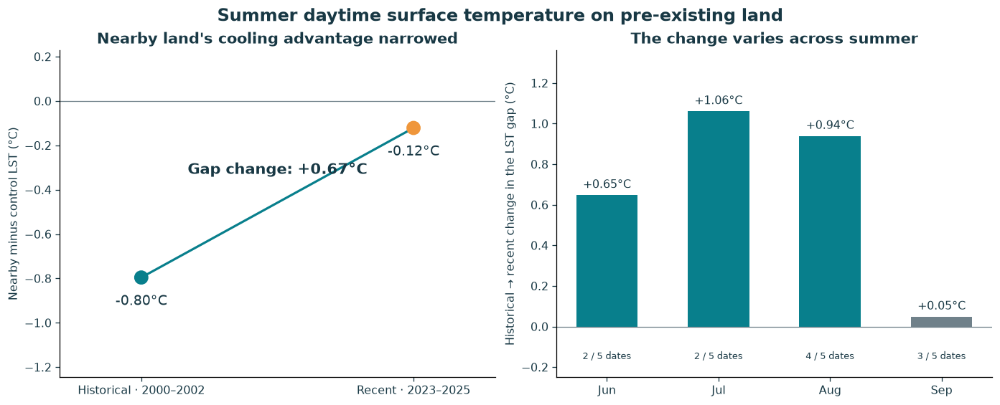

The nearby–control gap changed by +0.67°C. Resampling dates on their own gives an interval of +0.44 to +0.90°C. Resampling whole years and 960 m areas instead gives -0.13 to +1.23°C, which includes zero. With that broader interval, we cannot rule out no change. The checks in Section 3 use matched land groups and other coastal patches.

In [41]:
display(HTML(headline_html(change,stable_candidates,len(site_cards),comparison_checks,scenes,gaps)))
plot_gap_story(months,interval);plt.show()
broader=matched_intervals.set_index('comparison').loc['original']
display(Markdown(f"The nearby–control gap changed by {change:+.2f}°C. Resampling dates on their own gives an interval of {interval['date_bootstrap_2_5_c']:+.2f} to {interval['date_bootstrap_97_5_c']:+.2f}°C. Resampling whole years and 960 m areas instead gives {broader.lower_c:+.2f} to {broader.upper_c:+.2f}°C, which includes zero. With that broader interval, we cannot rule out no change. The checks in Section 3 use matched land groups and other coastal patches."))

## 2. Where the comparison takes place

Cyan marks land that changed from water to land in the satellite record. Orange is the nearby existing land we compare, and purple is the farther control land. The cyan outline is our estimate from imagery, not an official development boundary.

We only compare places that were land in both periods. Cells along the shoreline or with unclear histories are left out, which is why the nearby group starts a little inland. Appendix C gives the distances and selection rules.


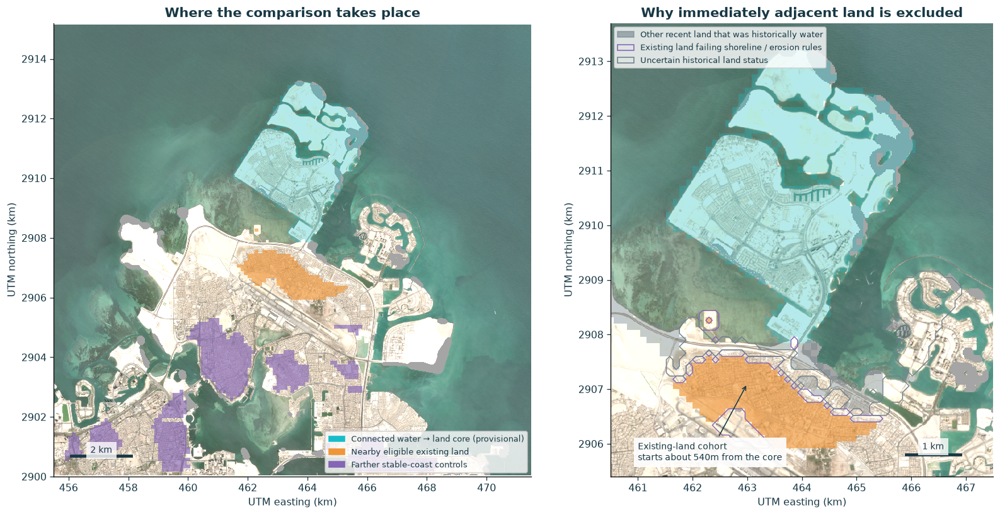

We compare 215 nearby cells and 768 control cells, each 120 m across. The closest cell in the nearby group is 537 m from the mapped reclamation area, which covers 12.60 km². Gray shading marks other newly formed land; gray background pixels indicate masked Sentinel observations. The outlined cells were left out because of the shoreline or unclear land history. The Sentinel-2 image is from 2025-09-25.

In [42]:
plot_cohorts(scenes,masks,diagnostics,native_rgb);plt.show()
nearest=masks['distance_to_fill_m'][masks['nearby']].min()
display(Markdown(f"We compare {int(masks['nearby'].sum())} nearby cells and {int(masks['control'].sum())} control cells, each 120 m across. The closest cell in the nearby group is {nearest:.0f} m from the mapped reclamation area, which covers {masks['fill'].sum()*.0144:.2f} km². Gray shading marks other newly formed land; gray background pixels indicate masked Sentinel observations. The outlined cells were left out because of the shoreline or unclear land history. The Sentinel-2 image is from {latest_pair.sentinel_date[:10]}."))

### A changing coastline

These four Landsat images show the same outline at different dates. Gray pixels are missing data. They show the broad transition from water to land, but do not give exact dates for each construction phase.


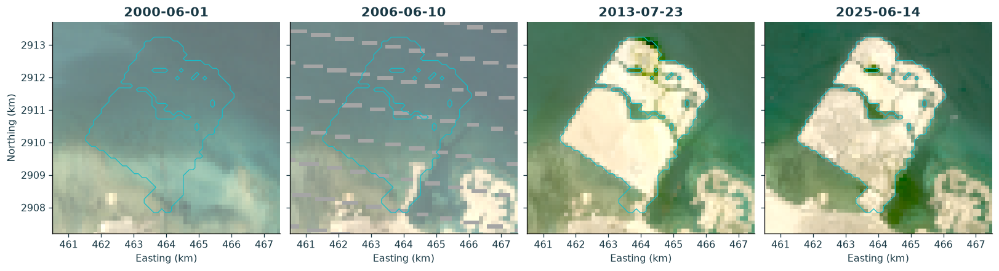

In [43]:
selected=[min(scenes,key=lambda s:abs(int(s['metadata']['date'][:4])-year)) for year in (2000,2006,2013,2025)]
fig,axes=plt.subplots(1,4,figsize=(14,4),sharex=True,sharey=True,layout='constrained')
for ax,scene in zip(axes,selected):
    ax.imshow(rgb(scene),extent=extent)
    ax.contour(masks['fill'],levels=[.5],colors=['#16bdc9'],extent=extent,origin='upper',linewidths=.8)
    ax.set(xlim=(460.5,467.5),ylim=(2907.2,2913.7),title=scene['metadata']['date'][:10],xlabel='Easting (km)')
axes[0].set_ylabel('Northing (km)');savefig('02_shoreline_rgb_epochs.png');plt.show()

## 3. Checking the comparison

We tried closer controls, farther controls and controls matched on historical surface characteristics. The estimated change stayed positive, though its size varied.

All of these comparisons use the same dates. We also removed one year at a time to check whether the result depended on a particular summer.


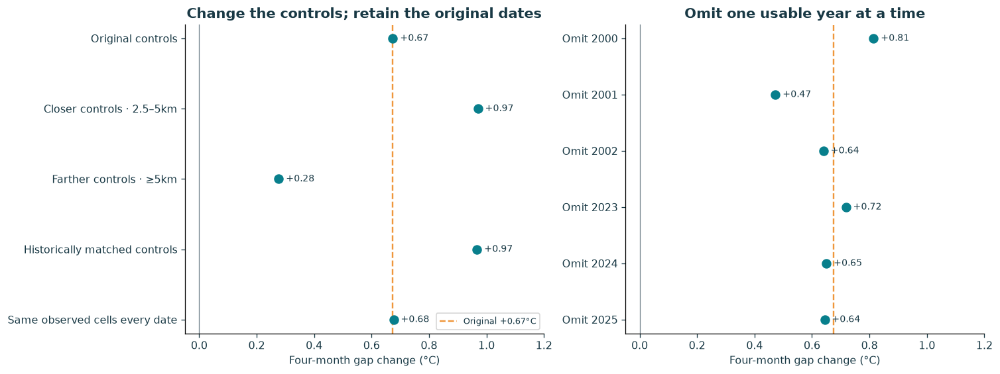

With different controls, the change ranges from +0.28 to +0.97°C. Removing one year at a time gives +0.47 to +0.81°C. These are ranges across choices, not confidence intervals. The full comparisons are in Appendix D.

In [44]:
plot_control_robustness(comparison_checks,year_checks,change);plt.show()
control_only=comparison_checks[comparison_checks.comparison.isin(['controls_2.5_to_5km_original_dates',
    'controls_at_least_5km_original_dates','historically_matched_original_dates','original'])]
display(Markdown(f"With different controls, the change ranges from {control_only.gap_change_c.min():+.2f} to {control_only.gap_change_c.max():+.2f}°C. Removing one year at a time gives {year_checks.gap_change_c.min():+.2f} to {year_checks.gap_change_c.max():+.2f}°C. These are ranges across choices, not confidence intervals. The full comparisons are in Appendix D."))

### Comparing land with similar surface changes

Land that existed before Diyar can still have new buildings, paving or landscaping. To check how much that matters, we compared greenness, brightness and other Landsat indicators between the two periods. We also used the 2017 and 2023 land-cover maps.

One set of checks keeps only cells with small measured changes. Another matches nearby cells to controls with similar histories. Each comparison uses the same 11 historical and 20 recent temperature dates. The chart includes cell counts because dropping or matching cells changes the area being compared.


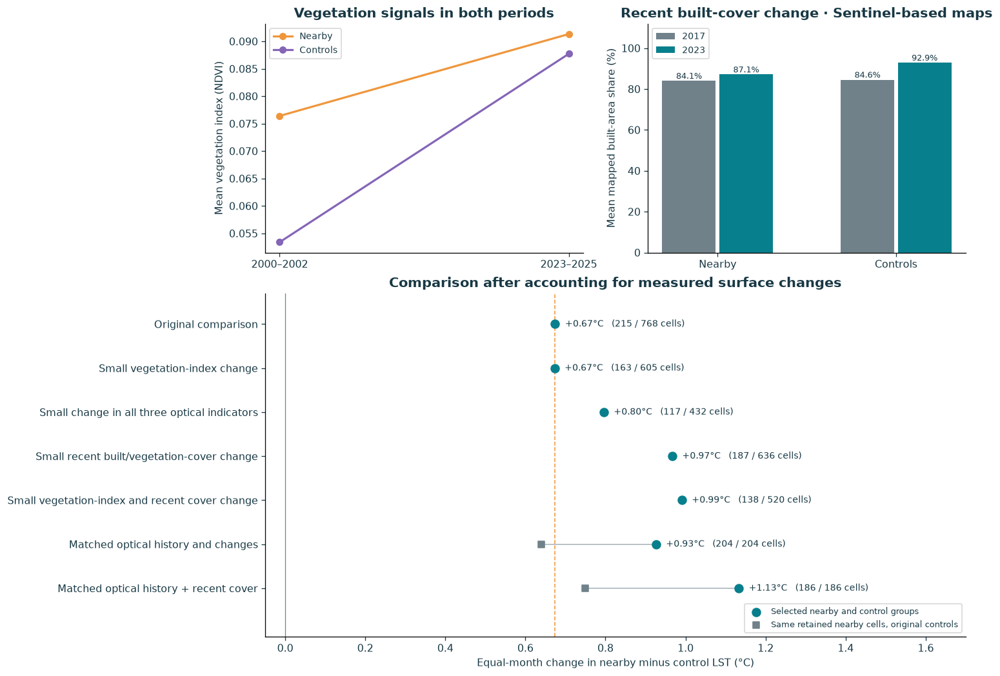

Keeping cells with an NDVI change of at most 0.05 gives +0.67°C. Matching optical histories and changes gives +0.93°C; adding the recent land-cover history gives +1.13°C. The gray squares compare the retained nearby cells with the original controls. That lets us see how much comes from dropping cells and how much from choosing different controls.

In [45]:
plot_surface_change(surface_tables['surface_change_profiles'],surface_checks);plt.show()
surface_values=surface_checks.set_index('comparison')
ndvi_check=surface_values.loc['small_ndvi_change_0.05','gap_change_c']
optical_check=surface_values.loc['matched_optical_history','gap_change_c']
cover_check=surface_values.loc['matched_optical_and_recent_cover','gap_change_c']
display(Markdown(f"Keeping cells with an NDVI change of at most 0.05 gives {ndvi_check:+.2f}°C. Matching optical histories and changes gives {optical_check:+.2f}°C; adding the recent land-cover history gives {cover_check:+.2f}°C. The gray squares compare the retained nearby cells with the original controls. That lets us see how much comes from dropping cells and how much from choosing different controls."))

The estimates stayed positive in these checks. That is useful, but the indicators have limits: NDBI responds to sand as well as buildings, and brightness is not a calibrated measure of albedo. The annual cover maps only begin in 2017, so we have no comparable building-cover map for 2000–2002.

There is also a change in the question being asked. Some surface changes may follow from the development itself. Matching on them compares places with similar changes; it does not measure the total effect of reclamation.


### A longer historical record

We searched summers from 1995 to 2014 to see how the result looked against a longer history. The land groups stayed the same. Both needed at least 80% valid land-temperature coverage for a date to be included.

The small gray dots are monthly means. The larger points are means of all four summer months, weighted equally. We left out incomplete summers. Much of 2003–2012 did not pass the coverage checks, and we have not sampled 2015–2022.


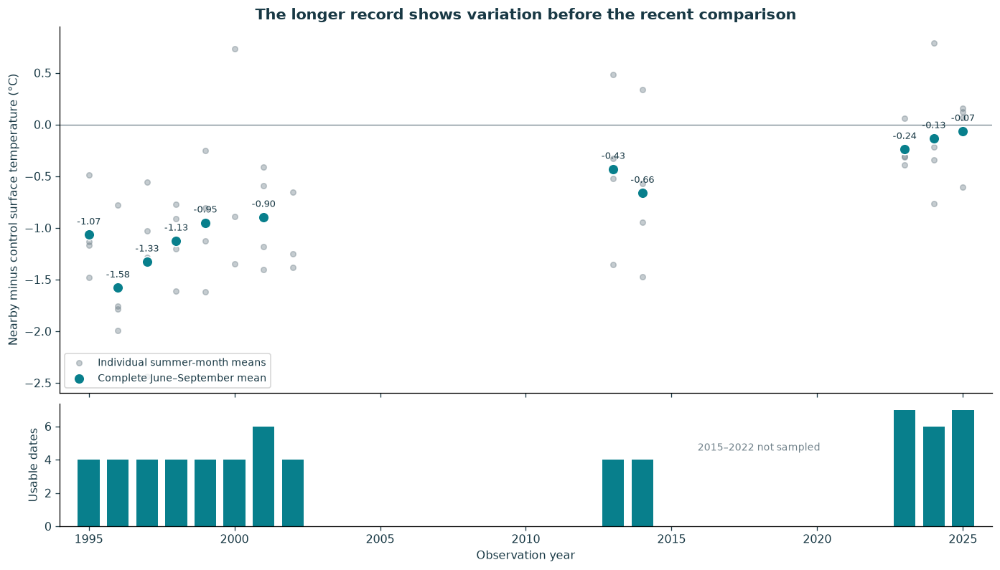

We found 34 usable historical dates from 1995–2002, with 6 complete summers. Against 2023–2025, giving years and months equal weight, the change is +1.01°C. This check screens land on each date, so we report it separately from the original +0.67°C result.

The historical gaps vary between years. The fitted trend is +0.074°C per year. Resampling historical years gives -0.023 to +0.212°C per year. There are too many gaps and too few years to establish a stable pre-development trend or make a causal claim.

In [46]:
plot_extended_timeline(timeline_years,timeline_months,timeline_dates);plt.show()
display(Markdown(f"We found {timeline_summary['admitted_historical_dates_1995_2002']} usable historical dates from 1995–2002, with {len(timeline_summary['complete_historical_years'])} complete summers. Against 2023–2025, giving years and months equal weight, the change is {timeline_summary['year_balanced_extended_gap_change_c']:+.2f}°C. This check screens land on each date, so we report it separately from the original +0.67°C result."))
display(Markdown(f"The historical gaps vary between years. The fitted trend is {timeline_summary['historical_gap_slope_c_per_year']:+.3f}°C per year. Resampling historical years gives {timeline_summary['historical_slope_resampling_lower']:+.3f} to {timeline_summary['historical_slope_resampling_upper']:+.3f}°C per year. There are too many gaps and too few years to establish a stable pre-development trend or make a causal claim."))

### Uncertainty across years and locations

Observations from the same year or area are related, so resampling individual dates can make the result look more certain than it is. We instead drew whole years and roughly 960 m blocks 500 times, recalculating the surface histories and matches each time.

The lines cover the middle 95% of the accepted results. We excluded attempts that were missing a summer month or had too little data, and recorded those failures in the appendix. Sensor bias, classification errors and unmeasured development changes are still outside these intervals.


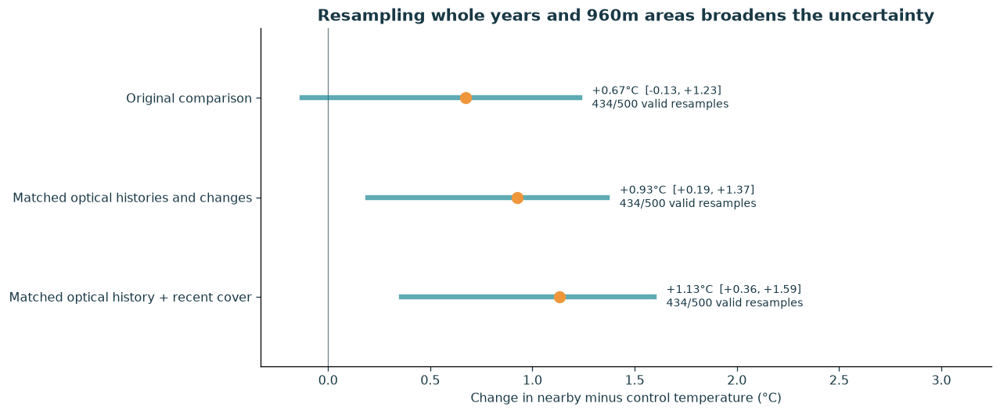

comparison,point_c,repeats,valid_repeats,valid_fraction,lower_c,upper_c,status
original,0.674,500,434,0.868,-0.129,1.231,conditional interval
matched_optical_history,0.926,500,434,0.868,0.195,1.366,conditional interval
matched_optical_and_recent_cover,1.133,500,434,0.868,0.359,1.595,conditional interval


The original interval includes zero. The two matched comparisons stay positive among the accepted resamples, suggesting a warming difference between places with similar measured histories. We still only have three years in each period. And because the matching uses changes after development, it cannot give us the total effect of reclamation.

In [47]:
plot_matched_uncertainty(matched_intervals);plt.show()
audit_table('Estimates and conditional year/area resampling intervals',matched_intervals)
display(Markdown("The original interval includes zero. The two matched comparisons stay positive among the accepted resamples, suggesting a warming difference between places with similar measured histories. We still only have three years in each period. And because the matching uses changes after development, it cannot give us the total effect of reclamation."))

### Comparisons elsewhere on the coast

We ran the same comparison on 960 m patches within the control areas. Each patch was compared with the remaining controls outside a 240 m buffer. We chose patches by their geometry and cell counts before looking at temperatures.

This gives us a check on how common similar changes are elsewhere. The patches are smaller than the nearby group and share reference areas, so the results are related. Their shorelines are stable, but other development may still have occurred.


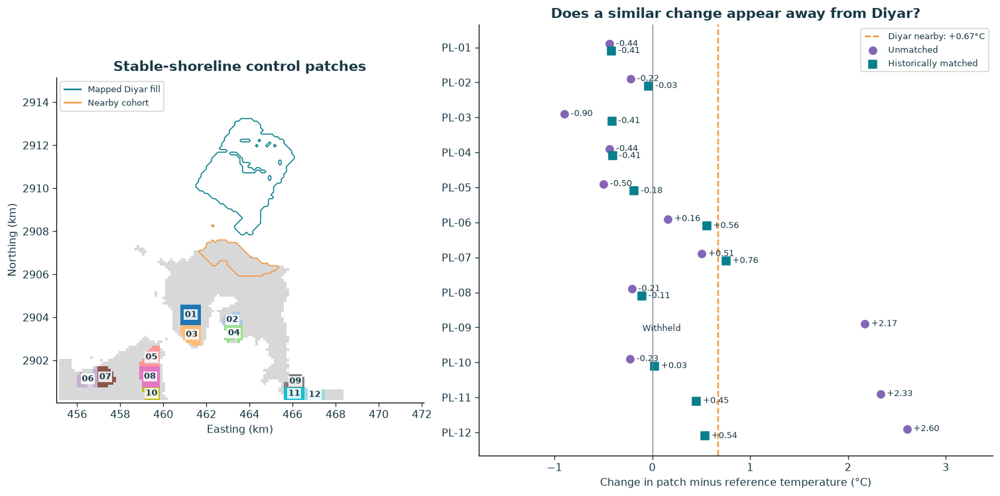

For the 12 patches, changes without matching range from -0.90 to +2.60°C. The 11 matched comparisons with enough data range from -0.41 to +0.76°C. Matching reduces several large differences, but relative warming still appears in some patches away from Diyar. We cannot treat it as a pattern unique to Diyar or as proof that reclamation caused it.

In [48]:
plot_coastal_placebos(placebo_checks,placebo_labels,masks,change);plt.show()
raw_placebos=placebo_checks[(placebo_checks.variant=='unmatched') & placebo_checks.gap_change_c.notna()]
matched_placebos=placebo_checks[(placebo_checks.variant=='historically matched') & placebo_checks.gap_change_c.notna()]
display(Markdown(f"For the {len(raw_placebos)} patches, changes without matching range from {raw_placebos.gap_change_c.min():+.2f} to {raw_placebos.gap_change_c.max():+.2f}°C. The {len(matched_placebos)} matched comparisons with enough data range from {matched_placebos.gap_change_c.min():+.2f} to {matched_placebos.gap_change_c.max():+.2f}°C. Matching reduces several large differences, but relative warming still appears in some patches away from Diyar. We cannot treat it as a pattern unique to Diyar or as proof that reclamation caused it."))

## 4. Using prediction to guide a field visit

We trained a gradient-boosting model on recent control-land observations, using satellite indicators and regional weather to predict surface temperature. We then applied it to nearby land and looked for cells that were repeatedly warmer than predicted. We call observed minus predicted temperature the residual.

To test the model, we held back locations, dates, and both together. We also trained on 2023–2024 and tested on 2025. In each case, we compared it with a simple prediction: the median temperature in the training data.

It did better at new locations than at new locations on unfamiliar dates. That limits how much weight we can put on the shortlist, but it gives us an area to investigate on the ground.


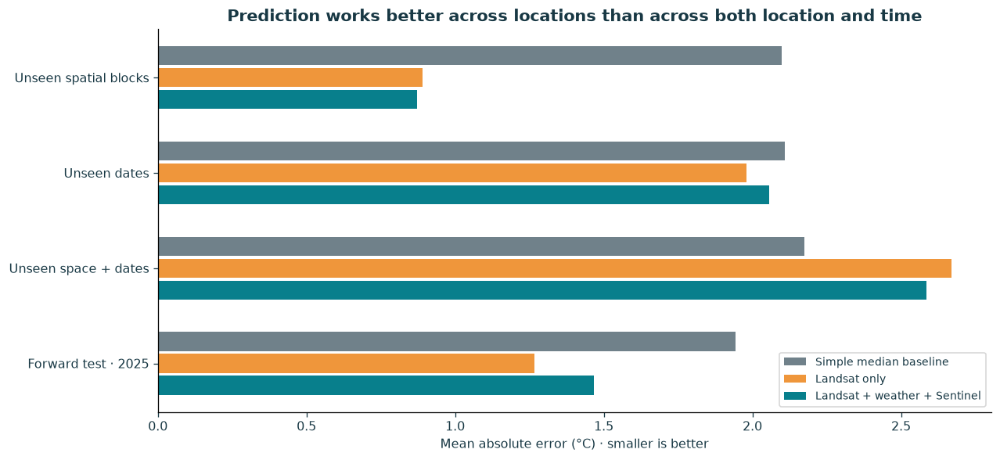

On dates left out of training, the full model's mean absolute error is 2.06°C, compared with 2.11°C for the baseline. When we leave out both locations and dates, its error rises to 2.58°C, compared with 2.18°C for the baseline. Appendix E has the results for each test and all four model configurations.

In [49]:
plot_validation_story(validation_summary);plt.show()
full=validation_summary[validation_summary.model=='Landsat+ERA5+Sentinel'].set_index('kind')
base=validation_summary[validation_summary.model=='training_median'].set_index('kind')
display(Markdown(f"On dates left out of training, the full model's mean absolute error is {full.loc['date','mean_mae_c']:.2f}°C, compared with {base.loc['date','mean_mae_c']:.2f}°C for the baseline. When we leave out both locations and dates, its error rises to {full.loc['space_and_date','mean_mae_c']:.2f}°C, compared with {base.loc['space_and_date','mean_mae_c']:.2f}°C for the baseline. Appendix E has the results for each test and all four model configurations."))

### Do extra satellite features help?

We tried adding land-cover shares inside each cell, surrounding cover within 240 m and 480 m, and variation in Sentinel indices and brightness inside the cell. Each addition was tested on its own and together with the others, keeping observations, splits and model settings the same.

The main test uses 2017 cover. That information predates the temperature observations but misses later construction. We also tried 2023 cover; this is labelled retrospective because it uses information that would not have been available for some earlier dates.

These tests have their own selections. The inspection cards below still use the original model's shortlist.


In [50]:
feature_summary,feature_candidates,feature_support,feature_settings=benchmark_satellite_features(
    training,scenes,masks,weather,sentinel,pairs,landcover_codes,original_review=review)
feature_candidate_comparison=pd.read_csv(OUT/'satellite_feature_candidate_comparison.csv')
summary.update(satellite_feature_validation=feature_summary.to_dict('records'),
    satellite_feature_experiment=feature_settings,
    satellite_feature_candidate_comparison=feature_candidate_comparison.to_dict('records'))
(OUT/'notebook_summary.json').write_text(json.dumps(summary,indent=2,default=lambda x:x.item()))

Satellite feature comparison: date_fold_1 complete


Satellite feature comparison: date_fold_2 complete


Satellite feature comparison: date_fold_3 complete


Satellite feature comparison: date_fold_4 complete


Satellite feature comparison: date_fold_5 complete


...

Satellite feature comparison: space_date_seed_23 complete


Satellite feature comparison: space_seed_37 complete


Satellite feature comparison: space_date_seed_37 complete


Satellite feature comparison: forward_2025 complete


60863

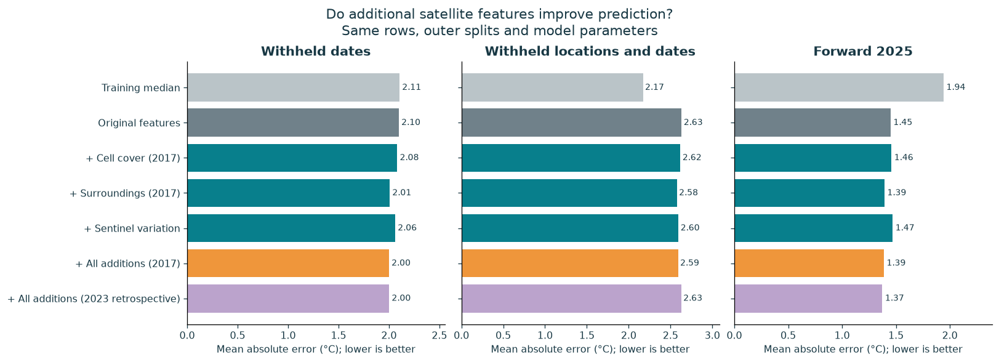

We have complete data for the extra features on 14,760 of 15,321 control observations. Adding all the features, including 2017 cover and Sentinel variation, gives withheld-date MAE of 2.00°C, compared with 2.10°C using the original features on those same observations. Leaving out both locations and dates gives MAE of 2.59°C, compared with 2.63°C. A negative change in the table means lower error. The additions help more in some tests than others.

kind,model,splits,mean_mae_c,min_mae_c,max_mae_c,mean_bias_c,mae_change_vs_original_c
date,+ All additions (2017),5,2.001,1.306,2.922,-0.020,-0.098
date,+ All additions (2023 retrospective),5,2.002,1.266,2.984,-0.008,-0.096
date,+ Cell cover (2017),5,2.083,1.385,2.958,-0.021,-0.016
date,+ Sentinel variation,5,2.062,1.352,3.006,-0.007,-0.036
date,+ Surroundings (2017),5,2.008,1.302,2.922,-0.020,-0.090
date,Original features,5,2.098,1.382,3.000,-0.020,0.000
date,Training median,5,2.105,1.936,2.456,0.411,0.007
forward_year,+ All additions (2017),1,1.389,1.389,1.389,0.536,-0.062
forward_year,+ All additions (2023 retrospective),1,1.374,1.374,1.374,0.521,-0.077
forward_year,+ Cell cover (2017),1,1.459,1.459,1.459,0.574,0.008


feature,control_rows,finite_control_rows,finite_nearby_observations
ndvi,15321,15321,4300
ndbi,15321,15321,4300
mndwi,15321,15321,4300
brightness,15321,15321,4300
swir22,15321,15321,4300
historical_coast_km,15321,15321,4300
season_sin,15321,15321,4300
season_cos,15321,15321,4300
sensor_l9,15321,15321,4300
air_c,15321,15321,4300


model,evaluation,supported_cells,shortlisted_cells,original_card_cells,original_cards_retained,original_cards_unassessable,original_cards_below_threshold
+ All additions (2017),all control dates,209,6,7,5,0,2
+ All additions (2017),date crossfit,209,7,7,5,0,2
+ All additions (2023 retrospective),all control dates,204,5,7,4,0,3
+ All additions (2023 retrospective),date crossfit,204,6,7,5,0,2
+ Cell cover (2017),all control dates,209,9,7,7,0,0
+ Cell cover (2017),date crossfit,209,8,7,6,0,1
+ Sentinel variation,all control dates,209,6,7,6,0,1
+ Sentinel variation,date crossfit,209,9,7,6,0,1
+ Surroundings (2017),all control dates,209,8,7,6,0,1
+ Surroundings (2017),date crossfit,209,10,7,6,0,1


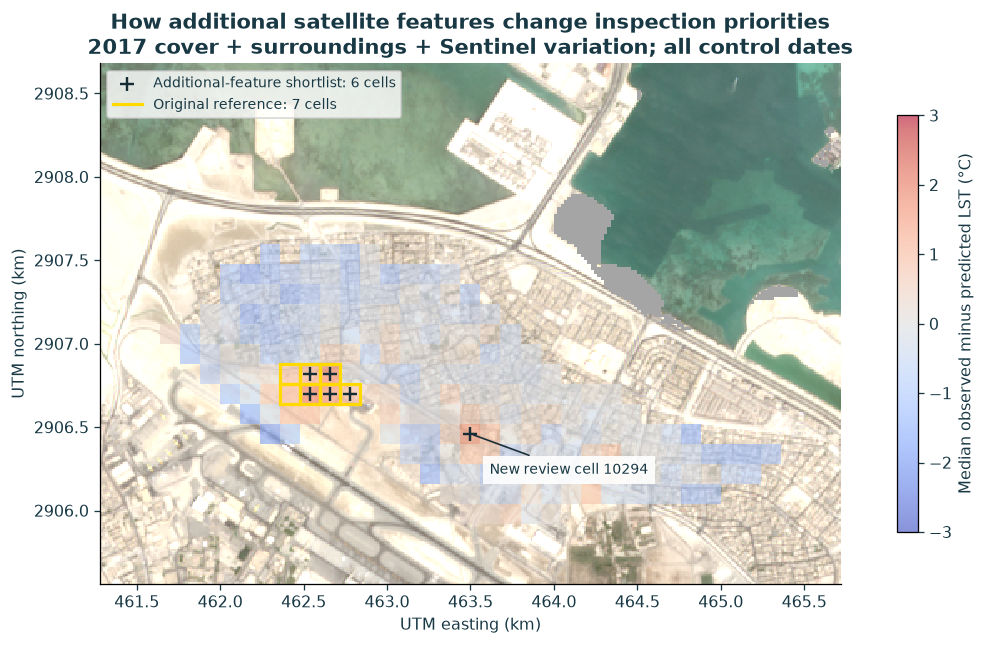

The yellow outlines are the seven cells from the original model. Crosses are cells chosen by the model with extra features, and the colours show median residuals where there is enough support. We would need to visit these 120 m cells to check their surfaces and possible treatments. The CSV also includes cells that were dropped or lacked enough feature data.

In [51]:
plot_feature_comparison(feature_summary);plt.show()
feature_original=feature_summary[feature_summary.model=='Original features'].set_index('kind')
feature_all=feature_summary[feature_summary.model=='+ All additions (2017)'].set_index('kind')
display(Markdown(f"We have complete data for the extra features on {feature_settings['common_rows']:,} of {feature_settings['original_rows']:,} control observations. Adding all the features, including 2017 cover and Sentinel variation, gives withheld-date MAE of {feature_all.loc['date','mean_mae_c']:.2f}°C, compared with {feature_original.loc['date','mean_mae_c']:.2f}°C using the original features on those same observations. Leaving out both locations and dates gives MAE of {feature_all.loc['space_and_date','mean_mae_c']:.2f}°C, compared with {feature_original.loc['space_and_date','mean_mae_c']:.2f}°C. A negative change in the table means lower error. The additions help more in some tests than others."))
audit_table('Each feature group on the same rows and splits',feature_summary)
audit_table('Feature completeness and observation support',feature_support)
audit_table('Shortlist changes with extra features and held-out-date predictions',feature_candidate_comparison)
plot_feature_screening(feature_candidates,review,masks,native_rgb);plt.show()
display(Markdown("The yellow outlines are the seven cells from the original model. Crosses are cells chosen by the model with extra features, and the colours show median residuals where there is enough support. We would need to visit these 120 m cells to check their surfaces and possible treatments. The CSV also includes cells that were dropped or lacked enough feature data."))
evidence_link('satellite_feature_candidates.csv','Download every cell and feature-variant screening result')
evidence_link('satellite_feature_settings.json','Download feature definitions, cover vintages and assumptions')
evidence_link('satellite_feature_splits.json','Download retained split dates, blocks and row counts')

## 5. Where to inspect

We shortlisted cells with a median residual above +1°C on at least ten supported dates. We chose +1°C as a working cutoff for this study.

We repeated the selection across 13 model/control choices. For the stability label, a cell must be assessable in at least 80% of those choices and selected in at least 80% of the assessable ones. A stable cell is one that keeps being selected; the label does not tell us whether it needs an intervention.

The seven neighbouring 120 m cells make up one area for a visit. The extra-feature selections are shown separately in Section 4 and do not change these cards' stability labels.


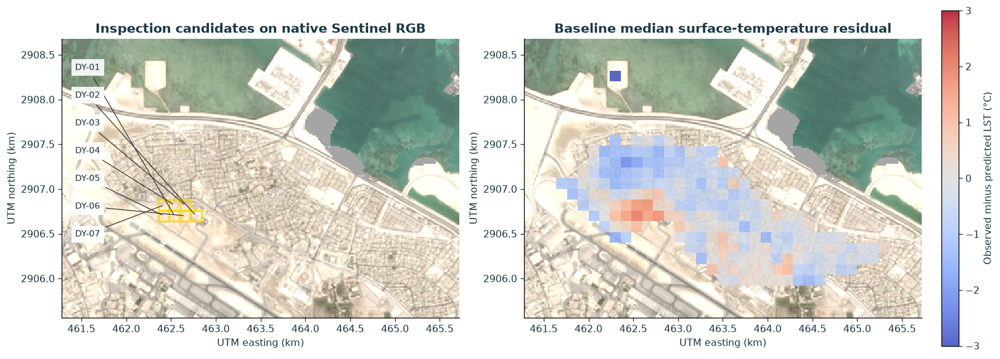

,Review cell,Median residual (°C),Selected / assessable,Stability
0,DY-01,1.95,13 / 13,Consistent across variants
1,DY-02,1.69,8 / 10,Sensitive to choices
2,DY-03,1.63,13 / 13,Consistent across variants
3,DY-04,1.51,13 / 13,Consistent across variants
4,DY-05,1.44,13 / 13,Consistent across variants
5,DY-06,1.44,12 / 13,Consistent across variants
6,DY-07,1.03,10 / 13,Sensitive to choices


The original model picked 7 cells for a visit, and 5 kept being selected across the model/control choices. All of the original cells have cards, including those whose selection was less consistent.

In [52]:
plot_candidate_overview(native_rgb,masks,site_cards,residual);plt.show()
card_table=site_cards[['site_id','median_residual_c','selected_variants','assessable_variants','stable_review']].copy()
card_table['Stability']=np.where(card_table.stable_review,'Consistent across variants','Sensitive to choices')
card_table['Selected / assessable']=card_table.selected_variants.astype(str)+' / '+card_table.assessable_variants.astype(str)
card_table=card_table.rename(columns={'site_id':'Review cell','median_residual_c':'Median residual (°C)'})
display(card_table[['Review cell','Median residual (°C)','Selected / assessable','Stability']].round(2))
display(Markdown(f"The original model picked {len(site_cards)} cells for a visit, and {stable_candidates} kept being selected across the model/control choices. All of the original cells have cards, including those whose selection was less consistent."))

### An inspection card

The yellow box marks the 120 m cell on Sentinel imagery. Beside it are residuals by date and the range across model/control choices. Those ranges show variation, not confidence intervals. The other six cards are in Appendix F.


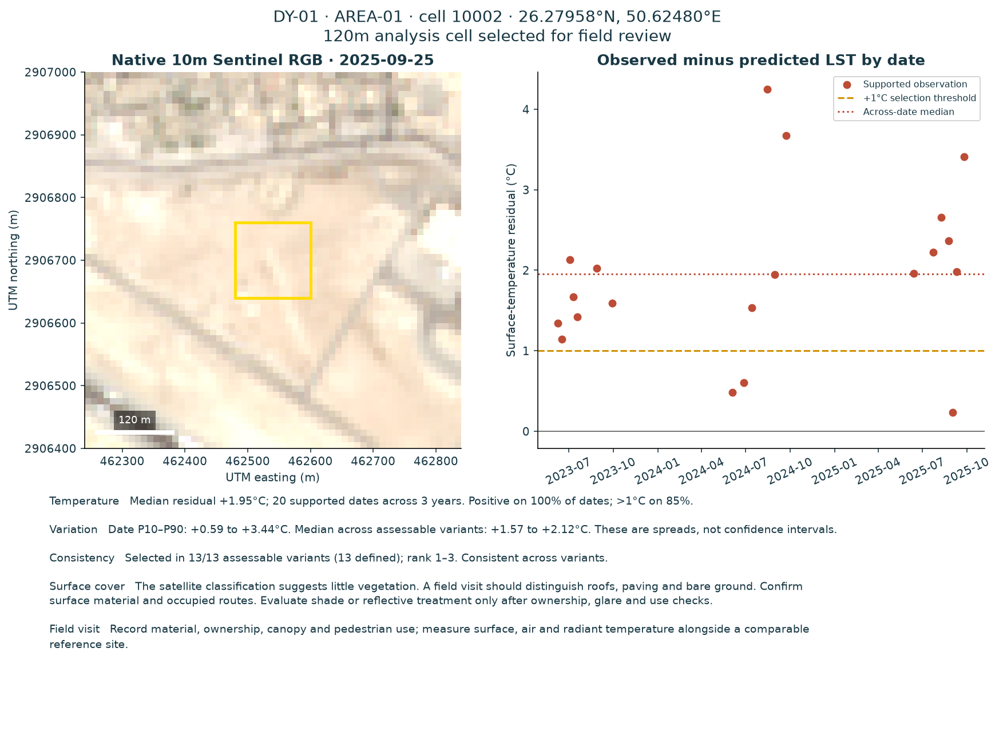

In [53]:
first=site_cards.iloc[0]
display(Image(filename=str(OUT/'site_cards'/f'{first.site_id}_cell_{first.cell}.png'),width=1100))
evidence_link('site_review.html','Open all illustrated inspection cards (offline gallery)')
evidence_link('candidate_site_cells.geojson','Download the 120m review-cell polygons')

## 6. From the map to a field pilot

We would start by visiting the shortlisted area and a similar reference location.

| Check on the ground | What it helps decide |
| --- | --- |
| Surface materials, ownership and pedestrian routes | Where shade or surface treatment could be feasible |
| Canopy gaps, irrigation and maintenance | Whether planting is appropriate |
| Surface, air and radiant temperature | Whether the satellite signal reflects heat where people spend time |
| Wind at relevant times | Whether an airflow study is needed |

If those measurements support a cooling measure, we would monitor the treated area and reference before and after installation to see whether it helps.

Part 1 looks at heat within the reclaimed development. Here we looked at the surrounding land. In both cases, the maps give us places to check rather than a measured cooling benefit.


## Evidence appendix

The tables below record which inputs we used and how we checked the results. Click a table title to expand it. CSV copies are saved with the outputs.

### A. Data sources

| Source | Sample | Use |
| --- | --- | --- |
| Landsat Collection 2 Level-2 | 50 June–September scenes: 20 historical, 10 transition, 20 recent | Daytime surface temperature and historical shoreline imagery |
| Additional Landsat history | 46 additional crops; 96 unique scenes including the original archive | Longer historical baseline and date-coverage checks |
| Sentinel-2 Level-2A | 20 distinct scenes within ±7 days of recent Landsat | Native-resolution RGB imagery, vegetation and spectral indicators |
| Esri / Impact Observatory annual land cover | 2017 and 2023 Sentinel-based 10 m crops | Recent built-area, bare-ground and vegetation changes |
| ERA5 single levels | 100 observation days and preceding days; 2,400 UTC hours; nine 0.25° cells | Regional temperature, dew point, wind, radiation and rainfall |

We take surface temperatures from Landsat, finer imagery and optical indicators from Sentinel, and regional weather from ERA5. The weather inputs include 2 m air temperature on a 0.25° grid. We interpolate one regional weather series to the study location and each overpass time, then use it for every analysis cell. This helps account for weather shared across the area, but does not resolve air-temperature differences between streets or local sea breezes. The model tests show what each added source contributes.


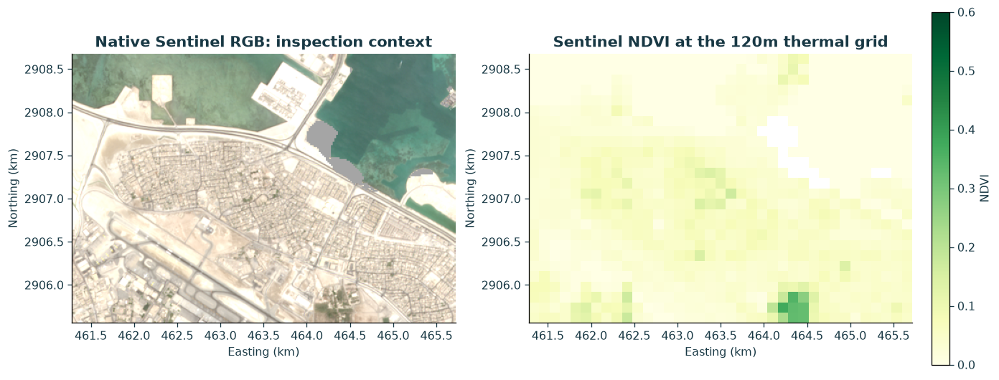

id,date,era,platform
LE07_L2SP_163042_20000609_02_T1,2000-06-09T06:56:33.903736+00:00,before,landsat-7
LE07_L2SP_163042_20010815_02_T1,2001-08-15T06:53:32.609528+00:00,before,landsat-7
LE07_L2SP_163042_20020802_02_T1,2002-08-02T06:52:55.567454+00:00,before,landsat-7
LE07_L2SP_163042_20030821_02_T1,2003-08-21T06:53:06.813651+00:00,before,landsat-7
LE07_L2SP_163042_20040604_02_T1,2004-06-04T06:53:49.432426+00:00,before,landsat-7
LE07_L2SP_163042_20040706_02_T1,2004-07-06T06:53:42.963473+00:00,before,landsat-7
LE07_L2SP_163042_20040722_02_T1,2004-07-22T06:53:38.526332+00:00,before,landsat-7
LE07_L2SP_163042_20050607_02_T1,2005-06-07T06:54:13.391602+00:00,before,landsat-7
LE07_L2SP_163042_20050623_02_T1,2005-06-23T06:54:07.836609+00:00,before,landsat-7
LE07_L2SP_163042_20050725_02_T1,2005-07-25T06:54:07.614585+00:00,before,landsat-7


landsat_date,sentinel_date,offset_days,local_scl_clear_fraction
2023-06-09T07:04:07.325825+00:00,2023-06-08T07:06:21.024000+00:00,-0.998,0.995
2023-06-17T07:04:10.793733+00:00,2023-06-18T07:06:31.024000+00:00,1.002,0.993
2023-07-03T07:04:20.832459+00:00,2023-07-03T07:06:29.024000+00:00,0.001,0.987
2023-07-11T07:04:17.937953+00:00,2023-07-13T07:06:29.024000+00:00,2.002,0.978
2023-07-19T07:04:24.724046+00:00,2023-07-18T07:06:31.024000+00:00,-0.999,0.998
2023-08-28T07:04:37.737748+00:00,2023-08-27T07:06:31.024000+00:00,-0.999,0.998
2023-09-29T07:04:43.830588+00:00,2023-09-26T07:06:41.024000+00:00,-2.999,0.991
2024-06-03T07:03:47.134756+00:00,2024-06-02T07:06:31.024000+00:00,-0.998,0.970
2024-06-27T07:03:46.055318+00:00,2024-06-27T07:06:29.024000+00:00,0.002,0.995
2024-07-13T07:04:07.897709+00:00,2024-07-07T07:06:29.024000+00:00,-5.998,0.990


In [54]:
ys,xs=np.where(masks['nearby']);y0,y1=max(0,ys.min()-3),min(height,ys.max()+4);x0,x1=max(0,xs.min()-3),min(width,xs.max()+4)
zoom_extent=np.array([affine.c+x0*120,affine.c+x1*120,affine.f-y1*120,affine.f-y0*120])/1000
fig,axes=plt.subplots(1,2,figsize=(12,4.5),layout='constrained')
axes[0].imshow(native_rgb[y0*12:y1*12,x0*12:x1*12],extent=zoom_extent)
axes[0].set_title('Native Sentinel RGB: inspection context')
im=axes[1].imshow(sentinel[latest_pair.landsat_id]['s2_ndvi'][y0:y1,x0:x1],extent=zoom_extent,cmap='YlGn',vmin=0,vmax=.6)
axes[1].set_title('Sentinel NDVI at the 120m thermal grid');fig.colorbar(im,ax=axes[1],label='NDVI')
for ax in axes:ax.set(xlabel='Easting (km)',ylabel='Northing (km)')
savefig('16_source_context.png');plt.show()
audit_table('Scene and pairing inventory',manifest[['id','date','era','platform']])
audit_table('Sentinel pairing offsets and clear fraction',pairs[['landsat_date','sentinel_date','offset_days','local_scl_clear_fraction']])
assert np.allclose(sentinel[latest_pair.landsat_id]['s2_ndmi'],-sentinel[latest_pair.landsat_id]['s2_ndbi'],equal_nan=True)

### B. Observation coverage and quality

We chose a 120 m grid because that is Landsat 5's native thermal resolution. Landsat 7 has 60 m thermal data and Landsat 8/9 have 100 m data. Although the products are distributed at 30 m, those pixels are not independent thermal measurements.

Before aggregation, we remove samples flagged as cloud, shadow, fill, snow or nonzero saturation. A thermal cell needs at least 80% clear samples, with a maximum valid ST_QA of 3 K or less. We use ST_QA to screen cells, not to estimate uncertainty in their mean temperature. Scan-line gaps stay empty. Tightening the ceiling to 2 K left too little overlap between the two periods.

The original search ran from 2000 to 2005, but the usable historical temperatures came from 2000–2002. The longer timeline adds earlier dates and checks land on each date. Both groups need at least 80% coverage. June–September are weighted equally, and the robustness comparisons require all four months.


In [55]:
audit_table('Downloaded versus usable dates',gaps.groupby(['era','included']).size().rename('dates').reset_index())
audit_table('Historical year/month coverage',robustness_tables['historical_coverage'])
audit_table('Per-scene cohort temperature and coverage',gaps[['date','platform','era','nearby_coverage','control_coverage','included','nearby_median_c','control_median_c','gap_c']])
audit_table('Four-month comparison',months)
audit_table('Quality ceiling and nearby-radius sensitivity',sensitivity)

era,included,dates
before,False,9
before,True,11
recent,True,20
transition,False,7
transition,True,3


era,year,month,downloaded_dates,usable_dates
before,2000,6,2,1
before,2000,9,2,1
before,2001,7,1,1
before,2001,8,2,2
before,2001,9,2,2
before,2002,6,1,1
before,2002,7,1,1
before,2002,8,2,2
before,2003,8,1,0
before,2004,6,1,0


date,platform,era,nearby_coverage,control_coverage,included,nearby_median_c,control_median_c,gap_c
2000-06-01,landsat-5,before,1.000,1.000,True,45.420,46.443,-1.022
2000-06-09,landsat-7,before,0.833,0.750,False,45.395,46.596,-1.201
2000-09-05,landsat-5,before,0.000,0.517,False,Insufficient data,41.377,Insufficient data
2000-09-21,landsat-5,before,1.000,1.000,True,45.033,44.303,0.730
2001-07-22,landsat-5,before,1.000,1.000,True,48.336,49.738,-1.402
2001-08-07,landsat-5,before,1.000,1.000,True,47.600,48.234,-0.634
2001-08-15,landsat-7,before,1.000,1.000,True,51.392,51.935,-0.543
2001-09-08,landsat-5,before,1.000,1.000,True,44.290,44.762,-0.471
2001-09-24,landsat-5,before,1.000,1.000,True,43.712,44.067,-0.355
2002-06-07,landsat-5,before,1.000,0.997,True,43.435,44.817,-1.382


month,before_dates,recent_dates,before_gap_c,recent_gap_c,change_c
6,2,5,-1.202,-0.555,0.648
7,2,5,-1.325,-0.264,1.061
8,4,5,-0.623,0.316,0.939
9,3,5,-0.032,0.017,0.049


max_st_qa_k,radius_m,nearby_cells,included_before,included_recent,months,gap_change_c
2.000,1000,32,0,18,none: insufficient overlap,Insufficient data
2.000,1500,115,0,18,none: insufficient overlap,Insufficient data
2.000,2000,215,0,18,none: insufficient overlap,Insufficient data
3.000,1000,32,11,20,"6,7,8,9",1.798
3.000,1500,115,11,20,"6,7,8,9",0.899
3.000,2000,215,11,20,"6,7,8,9",0.674
4.000,1000,32,11,20,"6,7,8,9",1.798
4.000,1500,115,11,20,"6,7,8,9",0.899
4.000,2000,215,11,20,"6,7,8,9",0.674
Insufficient data,1000,32,12,20,"6,7,8,9",1.794


### C. Study boundary and comparison groups

We classify a cell as historical water if it has at least eight clear observations and is water in at least 80% of them. Recent land also needs eight clear observations, with water in no more than 10%. We search within 50.595–50.660°E, 26.290–26.354°N and keep the connected core separately from disconnected changes. Cells without enough evidence remain unclassified.

The 50.660°E eastern edge includes the northeast fringe of the connected area, bringing the total to about 12.60 km². Moving it to 50.655°E removes 25 cells (0.36 km²), but leaves the nearby and control groups and their temperature comparison unchanged.

For the existing-land groups, cells must be land in both periods. We erode that mask by one cell and keep cells 240–1200 m from historical water and 240–2040 m from recent water. Nearby cells are within 2 km of the core. Controls are at least 2.5 km away and have a nearest-water-distance change of no more than 120 m.

The nearest water may not be open sea, so its distance is only a rough guide to coastal exposure. The core-only distance check changes water just beneath the mapped core; it cannot show that coastal cooling was lost.

A [June 2006 contractor SEC filing](https://www.sec.gov/Archives/edgar/data/885538/000110465906053960/a06-15410_110q.htm) records a reclamation contract. [Nass](https://www.nasscorporation.com/diyaar-al-muharraq-dredging-reclamation-shore-protection/) describes stages without dated polygons, and Diyar's [December 2024 infrastructure update](https://www.diyar.bh/en/press/121/9536485) does not date every island's filling. We use 2006–2014 as an observation window because those records do not provide a complete phase map.


distance_to_core_m,recent_land_outside_core_cells,historically_water_cells,historically_uncertain_cells,land_in_both_eras_cells,eligible_existing_cells
500,33,17,10,6,0
1000,116,30,32,54,32
1500,296,59,85,152,115
2000,601,132,180,289,215


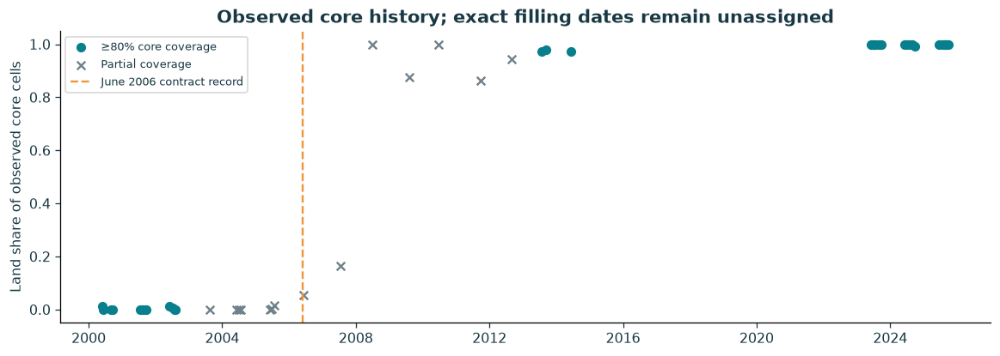

In [56]:
audit_table('Why adjacent recent land is not eligible existing land',cohort_audit)
fig,ax=plt.subplots(figsize=(10,3.5),layout='constrained')
usable=history.coverage>=.8
ax.scatter(pd.to_datetime(history.loc[usable,'date']),history.loc[usable,'observed_land_fraction'],label='≥80% core coverage',color='#087f8c')
ax.scatter(pd.to_datetime(history.loc[~usable,'date']),history.loc[~usable,'observed_land_fraction'],label='Partial coverage',marker='x',color='#70818a')
ax.axvline(pd.Timestamp('2006-06-01'),ls='--',color='#ef963b',label='June 2006 contract record')
ax.set(ylim=(-.05,1.05),ylabel='Land share of observed core cells',title='Observed core history; exact filling dates remain unassigned')
ax.legend(fontsize=8);savefig('03_shoreline_history.png');plt.show()

### D. Sensitivity to control selection and observation years

We tried stable-coast controls 2.5–5 km away, controls at least 5 km away, and controls matched using historical coast distance, NDVI, NDBI and brightness. For matching, we standardize features by the original controls' standard deviations and minimize distance within a ceiling of 2. Each control is used once; nearby cells can remain unmatched. Temperature is not used in matching, and similar optical characteristics do not guarantee similar building histories.

We also kept only cells valid on every original date, used non-overlapping distance bands, and removed each usable year in turn. Drawing whole years preserves the dependence within a year, but we only have three years in each period. The resampling results should be read with that small sample in mind. Attempts missing a summer month are counted and excluded. Neither bootstrap interval captures uncertainty in the boundary, sensors or development history.


In [57]:
audit_table('All control, date, complete-case and distance comparisons',comparison_checks)
audit_table('Historical covariate balance',robustness_tables['control_covariate_balance'])
audit_table('Leave one year out',year_checks)
audit_table('Whole-year resampling audit',pd.DataFrame([{
    'valid_replicates':year_interval['valid_repeats'],'missing_month_replicates':year_interval['missing_month_repeats'],
    'conditional_lower_c':year_interval['lower_c'],'conditional_upper_c':year_interval['upper_c']}]))
evidence_link('historical_control_matches.csv','Download the unique historical control matches')

comparison,nearby_cells,control_cells,before_dates,recent_dates,overlapping_months,gap_change_c,status
original,215,768,11,20,"6,7,8,9",0.674,all four summer months
controls_2.5_to_5km,215,303,12,20,"6,7,8,9",0.949,all four summer months
controls_2.5_to_5km_original_dates,215,303,11,20,"6,7,8,9",0.970,all four summer months
controls_at_least_5km,215,465,11,20,"6,7,8,9",0.277,all four summer months
controls_at_least_5km_original_dates,215,465,11,20,"6,7,8,9",0.277,all four summer months
historically_matched,215,215,11,20,"6,7,8,9",0.967,all four summer months
historically_matched_original_dates,215,215,11,20,"6,7,8,9",0.967,all four summer months
same_cells_every_date,215,765,11,20,"6,7,8,9",0.677,all four summer months
distance_band_0_1000m,32,768,11,20,"6,7,8,9",1.798,all four summer months
distance_band_1000_1500m,83,768,11,20,"6,7,8,9",0.481,all four summer months


cohort,feature,nearby_cells,control_cells,nearby_mean,control_mean,standardized_mean_difference
original,historical_coast_km,215,768,0.683,0.672,0.040
original,historical_ndvi,215,768,0.071,0.051,0.504
original,historical_ndbi,215,768,0.052,0.041,0.362
original,historical_brightness,215,768,0.230,0.236,-0.113
controls_2.5_to_5km,historical_coast_km,215,303,0.683,0.743,-0.234
controls_2.5_to_5km,historical_ndvi,215,303,0.071,0.055,0.387
controls_2.5_to_5km,historical_ndbi,215,303,0.052,0.042,0.323
controls_2.5_to_5km,historical_brightness,215,303,0.230,0.226,0.083
controls_at_least_5km,historical_coast_km,215,465,0.683,0.626,0.219
controls_at_least_5km,historical_ndvi,215,465,0.071,0.047,0.581


comparison,nearby_cells,control_cells,before_dates,recent_dates,overlapping_months,gap_change_c,status,omitted_era,omitted_year
omit_before_2000,215,768,9,20,"6,7,8,9",0.815,all four summer months,before,2000
omit_before_2001,215,768,6,20,"6,7,8,9",0.473,all four summer months,before,2001
omit_before_2002,215,768,7,20,"6,7,8,9",0.640,all four summer months,before,2002
omit_recent_2023,215,768,11,13,"6,7,8,9",0.718,all four summer months,recent,2023
omit_recent_2024,215,768,11,14,"6,7,8,9",0.650,all four summer months,recent,2024
omit_recent_2025,215,768,11,13,"6,7,8,9",0.644,all four summer months,recent,2025


valid_replicates,missing_month_replicates,conditional_lower_c,conditional_upper_c
1781,219,0.410,0.860


### D2. Accounting for changes in surface cover

For each Landsat indicator, we take the median over the original accepted dates within each month, then average June–September equally. A cell must have valid optical data on at least 80% of dates in every month. If a month is missing, we leave the value missing. The changes compare 2000–2002 with 2023–2025. We have not harmonized the sensors, so a measured optical change is not necessarily a change in vegetation or materials.

We test small NDVI changes with absolute limits of 0.03, 0.05 and 0.10. The combined optical check limits absolute NDVI, NDBI and brightness changes to 0.05. These are thresholds we chose to test sensitivity, not estimates of detection accuracy.

The annual cover maps are [Impact Observatory Maps for Good](https://docs.impactobservatory.com/lulc-maps/maps-for-good.html) products 39R-2017 and 39R-2023, from Planetary Computer's `io-lulc-annual-v02` collection. We sample classes at 10 m and calculate their shares within each 120 m cell. Cloud, nodata and unknown codes are removed from the denominator. A cell with no known cover stays missing.

For reliable cover, we require at least 80% known samples and no more than 10% water in both years. The small-cover check allows up to ten percentage points of change in built-area and vegetation shares. Built area includes buildings, roads and other impervious surfaces. These are classified estimates that still need checking locally. The maps are credited to Esri, Impact Observatory and Microsoft under CC BY 4.0 and contain modified Copernicus Sentinel data (2017 and 2023).

The first matching check uses historical coast distance, historical NDVI, NDBI and brightness, and their changes. The second adds 2017 built-area and vegetation shares and changes to 2023. We standardize by the eligible controls' standard deviations, retain as many unique pairs as possible within a Euclidean distance of 2, then minimize distance. We do not use temperature. The tables show balance and dropped cells. Each matched result also has a comparison using the same retained nearby cells against the original controls, so we can see what dropping cells contributes.

We require all original accepted dates and all four months for every temperature comparison. Too few cells or too little coverage means no estimate is reported. Matching changes which places are being compared; matching on changes after development also means the result cannot represent reclamation's total effect. We still lack a reliable building-cover baseline for 2000–2002.


In [58]:
audit_table('Every surface-change comparison, including alternate thresholds',surface_checks)
audit_table('Observed optical and recent-cover profiles',surface_tables['surface_change_profiles'])
audit_table('Balance after each surface-change comparison',surface_tables['surface_change_balance'])
audit_table('Monthly optical support requirements',surface_tables['surface_change_optical_coverage'])
audit_table('Annual land-cover source records',pd.DataFrame(landcover_manifest)[['year','item_id','collection','path','sha256']])
evidence_link('surface_change_matches.csv','Download the unique matched cell pairs')
evidence_link('surface_change_cells.csv','Download the optical and land-cover history of every comparison cell')
evidence_link('surface_change_settings.json','Download thresholds, features, source records and limitations')

comparison,nearby_cells,control_cells,before_dates,recent_dates,overlapping_months,gap_change_c,status,original_dates_retained
original,215,768,11,20,"6,7,8,9",0.674,all four summer months,True
small_ndvi_change_0.03,95,308,11,20,"6,7,8,9",0.951,all four summer months,True
small_ndvi_change_0.05,163,605,11,20,"6,7,8,9",0.673,all four summer months,True
small_ndvi_change_0.10,208,735,11,20,"6,7,8,9",0.629,all four summer months,True
small_optical_change,117,432,11,20,"6,7,8,9",0.796,all four summer months,True
small_recent_cover_change,187,636,11,20,"6,7,8,9",0.967,all four summer months,True
small_vegetation_and_recent_cover_change,138,520,11,20,"6,7,8,9",0.991,all four summer months,True
matched_optical_history,204,204,11,20,"6,7,8,9",0.926,all four summer months,True
matched_optical_history_same_nearby_original_controls,204,768,11,20,"6,7,8,9",0.640,all four summer months,True
matched_optical_and_recent_cover,186,186,11,20,"6,7,8,9",1.133,all four summer months,True


cohort,feature,supported_cells,median,mean
nearby,before_ndvi,215,0.053,0.076
nearby,before_ndbi,215,0.057,0.052
nearby,before_brightness,215,0.228,0.231
nearby,recent_ndvi,215,0.087,0.091
nearby,recent_ndbi,215,0.034,0.035
nearby,recent_brightness,215,0.198,0.201
nearby,change_ndvi,215,0.026,0.015
nearby,change_ndbi,215,-0.022,-0.018
nearby,change_brightness,215,-0.027,-0.030
nearby,built_2017,215,1.000,0.841


comparison,feature,nearby_mean,control_mean,standardized_mean_difference
original,historical_coast_km,0.683,0.672,0.040
original,before_ndvi,0.076,0.053,0.546
original,before_ndbi,0.052,0.044,0.270
original,before_brightness,0.231,0.237,-0.123
original,change_ndvi,0.015,0.034,-0.585
original,change_ndbi,-0.018,-0.019,0.048
original,change_brightness,-0.030,-0.046,0.371
original,built_2017,0.841,0.844,-0.011
original,change_built_2017_2023,0.031,0.084,-0.225
original,vegetation_2017,0.000,0.000,-0.056


era,month,index,source_dates,minimum_valid_dates,supported_grid_cells
before,6,ndvi,2,2,17865
before,7,ndvi,2,2,17886
before,8,ndvi,4,4,17854
before,9,ndvi,3,3,17892
before,6,ndbi,2,2,17865
before,7,ndbi,2,2,17886
before,8,ndbi,4,4,17854
before,9,ndbi,3,3,17892
before,6,brightness,2,2,17865
before,7,brightness,2,2,17886


year,item_id,collection,path,sha256
2017,39R-2017,io-lulc-annual-v02,data/expanded/landcover/io_39R_2017_10m.npz,7f93843db5b324a4dea2c10e236622f314d11ec45545836e6324d1963b20b0f7
2023,39R-2023,io-lulc-annual-v02,data/expanded/landcover/io_39R_2023_10m.npz,29d4625fcfa7858c6b8170f998f35c351b20a449c7c00e67f3055cec9193ff72


### D3. Extended history, uncertainty and coastal placebos

For the longer archive, we search Tier-1 summer products from path/row 163/042 with catalogue cloud cover below 30%. Up to three candidates per year and month are ranked by preferred sensor (Landsat 5 through 2012, Landsat 8 thereafter), cloud metadata, distance from mid-month and product ID. We take the first that passes local land and temperature coverage, keeping a record of failed candidates. Original cached scenes are included without duplicates. We choose dates without looking at their temperatures and keep the original groups and +0.67°C calculation.

The timeline needs clear optical observations and excludes mapped water on each date. For an annual value, all four months from June to September must be present. We average dates within months and give each month equal weight. The extended-baseline check gives each complete summer in 1995–2002 and 2023–2025 equal weight, leaving out incomplete years.

For the historical trend, we draw whole years in 2,000 attempts (seed 710), keeping draws with at least three distinct years. This describes the fitted trend but is not enough to validate a pre-treatment trend. [USGS records Landsat 7's scan-line-corrector failure in May 2003](https://www.usgs.gov/landsat-missions/landsat-7). We keep its gaps and the same quality criteria.

Matched uncertainty uses the original 11 historical and 20 recent dates. In 500 attempts (seed 731), we draw years with replacement independently in each period and occupied 960 m blocks independently in each group. Every cell in a drawn block is kept. Repeated copies carry their bootstrap weight, and matching is unique across sampled copies.

We recalculate optical histories, support, control standard deviations and matching each time, while holding recent classified cover fixed. Every drawn date needs 80% coverage, all four months must remain, and the minimum cell counts still apply. We report an interval only if at least 80% of attempts and at least 100 resamples are valid. Failures and source-year draws are saved too. The percentile intervals depend on these choices and do not establish causation.

The coastal placebo checks use every original-control block with at least 30 cells and at least 100 reference cells outside a 240 m buffer. Historical matching uses coast distance, NDVI, NDBI and brightness, with unique assignment and the same distance ceiling of 2. Every original date must remain. We withhold matched checks with fewer than 30 controls. The patches are different in size from the nearby group, their reference areas overlap, and locations were not randomly assigned. We therefore do not report a randomization p-value.


In [59]:
audit_table('Extended historical dates, including excluded observations',timeline_dates)
audit_table('Complete and incomplete summers',timeline_years)
audit_table('Archive candidates, rejected coverage and missing catalog months',timeline_selection)
audit_table('Every coastal placebo, including withheld comparisons',placebo_checks)
audit_table('Resampling failures by comparison',matched_replicates.groupby(['comparison','status']).size().reset_index(name='attempts'))
evidence_link('extended_timeline_summary.json','Download the longer-record settings and findings')
evidence_link('timeline_source_manifest.csv','Download exact additional source IDs, retrieval metadata and hashes')
evidence_link('matched_uncertainty_replicates.csv','Download all year/area resampling attempts')
evidence_link('matched_uncertainty_settings.json','Download the resampling assumptions and limitations')
evidence_link('coastal_placebo_matches.csv','Download the placebo matched pairs')
evidence_link('coastal_placebo_settings.json','Download placebo geometry, criteria and limitations')

id,date,month,year,era,platform,nearby_coverage,control_coverage,included,nearby_median_c,control_median_c,gap_c
LT05_L2SP_163042_19950620_02_T1,1995-06-20,6,1995,before,landsat-5,0.995,0.837,True,43.897,45.374,-1.477
LT05_L2SP_163042_19950706_02_T1,1995-07-06,7,1995,before,landsat-5,0.995,0.815,True,42.879,44.049,-1.170
LT05_L2SP_163042_19950823_02_T1,1995-08-23,8,1995,before,landsat-5,0.995,0.880,True,42.880,44.014,-1.134
LT05_L2SP_163042_19950908_02_T1,1995-09-08,9,1995,before,landsat-5,1.000,0.924,True,40.867,41.353,-0.486
LT05_L2SP_163042_19960622_02_T1,1996-06-22,6,1996,before,landsat-5,0.995,0.820,True,41.931,43.922,-1.991
LT05_L2SP_163042_19960708_02_T1,1996-07-08,7,1996,before,landsat-5,0.995,0.837,True,43.039,44.796,-1.757
LT05_L2SP_163042_19960809_02_T1,1996-08-09,8,1996,before,landsat-5,1.000,0.870,True,45.510,47.296,-1.786
LT05_L2SP_163042_19960910_02_T1,1996-09-10,9,1996,before,landsat-5,1.000,0.902,True,44.343,45.125,-0.782
LT05_L2SP_163042_19970609_02_T1,1997-06-09,6,1997,before,landsat-5,1.000,0.888,True,46.922,49.359,-2.437
LT05_L2SP_163042_19970711_02_T1,1997-07-11,7,1997,before,landsat-5,1.000,0.889,True,45.842,47.130,-1.287


year,months,gap_c,complete_summer,dates
1995,4,-1.067,True,4
1996,4,-1.579,True,4
1997,4,-1.328,True,4
1998,4,-1.126,True,4
1999,4,-0.951,True,4
2000,3,Insufficient data,False,4
2001,4,-0.896,True,6
2002,3,Insufficient data,False,4
2013,4,-0.431,True,4
2014,4,-0.663,True,4


year,month,id,rank,nearby_coverage,control_coverage,selected,status
1995,6,LT05_L2SP_163042_19950620_02_T1,1.000,0.995,0.837,True,passes local land/thermal QA
1995,8,LT05_L2SP_163042_19950823_02_T1,1.000,0.995,0.880,True,passes local land/thermal QA
1995,7,LT05_L2SP_163042_19950706_02_T1,1.000,0.995,0.815,True,passes local land/thermal QA
1996,7,LT05_L2SP_163042_19960708_02_T1,1.000,0.995,0.837,True,passes local land/thermal QA
1996,6,LT05_L2SP_163042_19960622_02_T1,1.000,0.995,0.820,True,passes local land/thermal QA
1995,9,LT05_L2SP_163042_19950908_02_T1,1.000,1.000,0.924,True,passes local land/thermal QA
1996,8,LT05_L2SP_163042_19960809_02_T1,1.000,1.000,0.870,True,passes local land/thermal QA
1996,9,LT05_L2SP_163042_19960910_02_T1,1.000,1.000,0.902,True,passes local land/thermal QA
1997,6,LT05_L2SP_163042_19970609_02_T1,1.000,1.000,0.888,True,passes local land/thermal QA
1997,7,LT05_L2SP_163042_19970711_02_T1,1.000,1.000,0.889,True,passes local land/thermal QA


comparison,nearby_cells,control_cells,before_dates,recent_dates,overlapping_months,gap_change_c,status,original_dates_retained,placebo,variant,block
PL-01,64,640,11,20,"6,7,8,9",-0.436,all four summer months,True,PL-01,unmatched,204
PL-01_matched,64,64,11,20,"6,7,8,9",-0.414,all four summer months,True,PL-01,historically matched,204
PL-02,32,717,11,20,"6,7,8,9",-0.220,all four summer months,True,PL-02,unmatched,206
PL-02_matched,32,32,11,20,"6,7,8,9",-0.034,all four summer months,True,PL-02,historically matched,206
PL-03,56,675,11,20,"6,7,8,9",-0.898,all four summer months,True,PL-03,unmatched,222
PL-03_matched,56,56,11,20,"6,7,8,9",-0.414,all four summer months,True,PL-03,historically matched,222
PL-04,40,702,11,20,"6,7,8,9",-0.435,all four summer months,True,PL-04,unmatched,224
PL-04_matched,40,40,11,20,"6,7,8,9",-0.406,all four summer months,True,PL-04,historically matched,224
PL-05,41,701,11,20,"6,7,8,9",-0.497,all four summer months,True,PL-05,unmatched,238
PL-05_matched,41,41,11,20,"6,7,8,9",-0.184,all four summer months,True,PL-05,historically matched,238


comparison,status,attempts
matched_optical_and_recent_cover,missing month,66
matched_optical_and_recent_cover,valid,434
matched_optical_history,missing month,66
matched_optical_history,valid,434
original,missing month,66
original,valid,434


### E. Model features, splits and support

The histogram gradient-boosting model predicts land surface temperature (LST) using Landsat indices, SWIR2, brightness, historical coast distance, season, sensor identity, six ERA5 measurements, and paired Sentinel indices and vegetation share. NDMI is exactly −NDBI with our formulas, so we include only NDBI. In Bahrain, that index can respond to sand as well as buildings. Vegetation from Sentinel's scene classification (SCL) is also only a preliminary proxy.

The initial validation holds back the last four recent dates and 20% of roughly 960 m blocks. We then add three spatial seeds with a 240 m buffer, five whole-date folds assigned round-robin after month/year ordering, three combined space/date splits, and a forward test on 2025. The training-median baseline and three feature configurations use the same rows. For date cross-fitting, each nearby date is predicted by a model trained without that date.

We recalculate feature-range support from each training set. Every configuration uses the full model's marginal range screen, and a candidate median needs at least ten supported dates. A cell can fall within the range of each feature separately while still having a combination unlike anything in training. Nearby cells may also have different land uses from controls. We need to consider those differences alongside temperature quality and test errors when reading the residuals.


In [60]:
audit_table('Original validation',scores)
audit_table('Broader validation summary',validation_summary)
audit_table('Every repeated split and model',repeat_scores)
audit_table('Candidate overlap and rank correlation by variant',variant_comparison)
audit_table('Permutation importance (descriptive spatial row permutations)',importance)
evidence_link('repeated_ml_per_date.csv','Download validation errors by date')
evidence_link('repeated_ml_splits.json','Download the split definitions')
evidence_link('candidate_variant_scores.csv','Download candidate support, residuals and ranks for every variant')

model,test,rows,dates,blocks,mae_c,r2
training_median,space,2447,16,8,1.938,-0.007
training_median,date,3061,4,40,2.649,-0.633
training_median,space_and_date,612,4,8,2.455,-0.488
Landsat,space,2447,16,8,0.801,0.815
Landsat,date,3061,4,40,1.323,0.612
Landsat,space_and_date,612,4,8,1.419,0.551
Landsat+ERA5,space,2447,16,8,0.805,0.812
Landsat+ERA5,date,3061,4,40,1.409,0.595
Landsat+ERA5,space_and_date,612,4,8,1.524,0.529
Landsat+ERA5+Sentinel,space,2447,16,8,0.756,0.835


kind,model,splits,mean_mae_c,min_mae_c,max_mae_c,mean_bias_c
date,Landsat,5,1.980,1.148,2.997,-0.060
date,Landsat+ERA5,5,2.075,1.330,2.961,-0.031
date,Landsat+ERA5+Sentinel,5,2.057,1.391,2.930,0.009
date,training_median,5,2.110,1.935,2.465,0.410
forward_year,Landsat,1,1.266,1.266,1.266,0.303
forward_year,Landsat+ERA5,1,1.429,1.429,1.429,0.553
forward_year,Landsat+ERA5+Sentinel,1,1.468,1.468,1.468,0.554
forward_year,training_median,1,1.942,1.942,1.942,1.166
space,Landsat,3,0.892,0.716,1.014,0.189
space,Landsat+ERA5,3,0.887,0.710,1.013,0.196


split,kind,model,rows,dates,blocks,mae_c,bias_c,r2
date_fold_1,date,training_median,3071,4,40,1.935,0.257,-0.011
date_fold_1,date,Landsat,3071,4,40,2.754,-2.288,-0.751
date_fold_1,date,Landsat+ERA5,3071,4,40,2.696,-1.397,-0.680
date_fold_1,date,Landsat+ERA5+Sentinel,3071,4,40,2.583,-1.275,-0.545
date_fold_2,date,training_median,3065,4,40,1.954,0.013,-0.000
date_fold_2,date,Landsat,3065,4,40,1.511,-0.233,0.409
date_fold_2,date,Landsat+ERA5,3065,4,40,1.441,-0.768,0.433
date_fold_2,date,Landsat+ERA5+Sentinel,3065,4,40,1.391,-0.673,0.482
date_fold_3,date,training_median,3056,4,40,2.465,1.953,-0.853
date_fold_3,date,Landsat,3056,4,40,2.997,2.435,-1.502


variant,supported_cells,priority_cells,baseline_candidates_retained,rank_spearman_on_common_support,priority_jaccard
original / Landsat,215,8,7,0.923,0.875
original / Landsat+ERA5,215,7,7,0.932,1.000
original / Landsat+ERA5+Sentinel,215,7,7,1.000,1.000
controls_2.5_to_5km / Landsat,215,28,6,0.771,0.207
controls_2.5_to_5km / Landsat+ERA5,215,32,7,0.774,0.219
controls_2.5_to_5km / Landsat+ERA5+Sentinel,215,22,7,0.803,0.318
controls_at_least_5km / Landsat,215,5,5,0.880,0.714
controls_at_least_5km / Landsat+ERA5,215,8,6,0.878,0.667
controls_at_least_5km / Landsat+ERA5+Sentinel,215,8,6,0.921,0.667
historically_matched / Landsat,214,20,5,0.849,0.227


feature,mae_increase_c,sd_c
season_sin,1.076,0.022
v10_ms,0.177,0.006
air_c,0.144,0.013
s2_ndbi,0.127,0.002
ndbi,0.068,0.003
historical_coast_km,0.067,0.004
swir22,0.057,0.002
s2_brightness,0.043,0.006
s2_ndvi,0.024,0.005
sensor_l9,0.022,0.002


### F. All inspection cards

The cards show recent daytime surface-temperature residuals. P10–P90 describes variation between dates; the minimum and maximum model medians describe variation between choices. Neither range is a confidence interval.

Adjacent cells share one inspection-area ID and should be visited together. We have not confirmed their materials, ownership or likely cooling benefit.


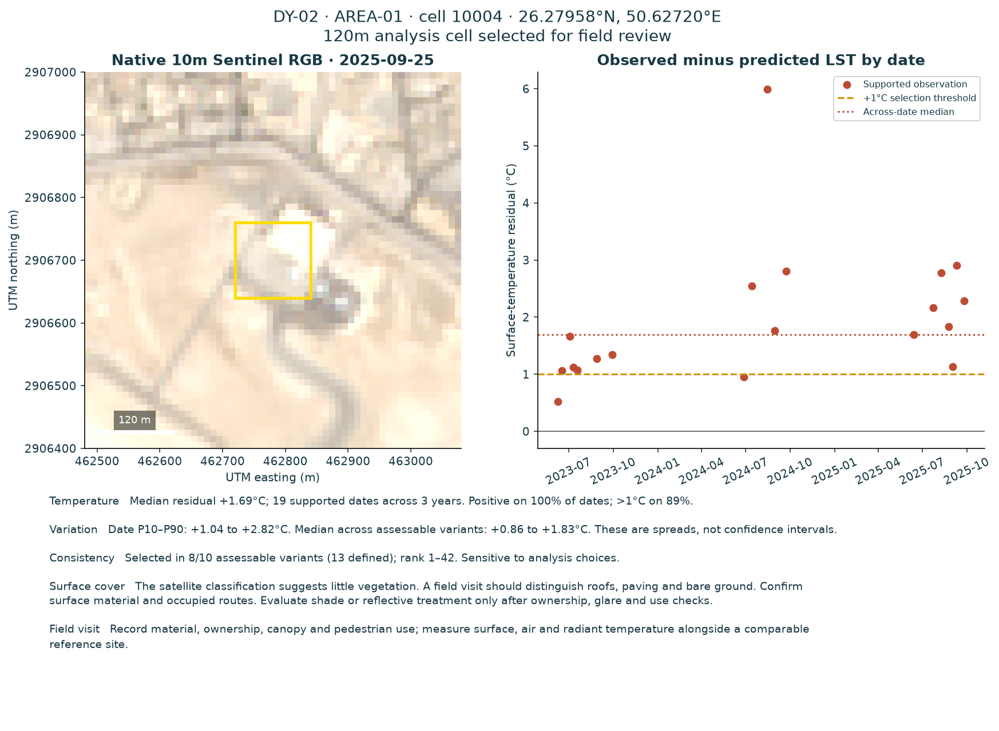

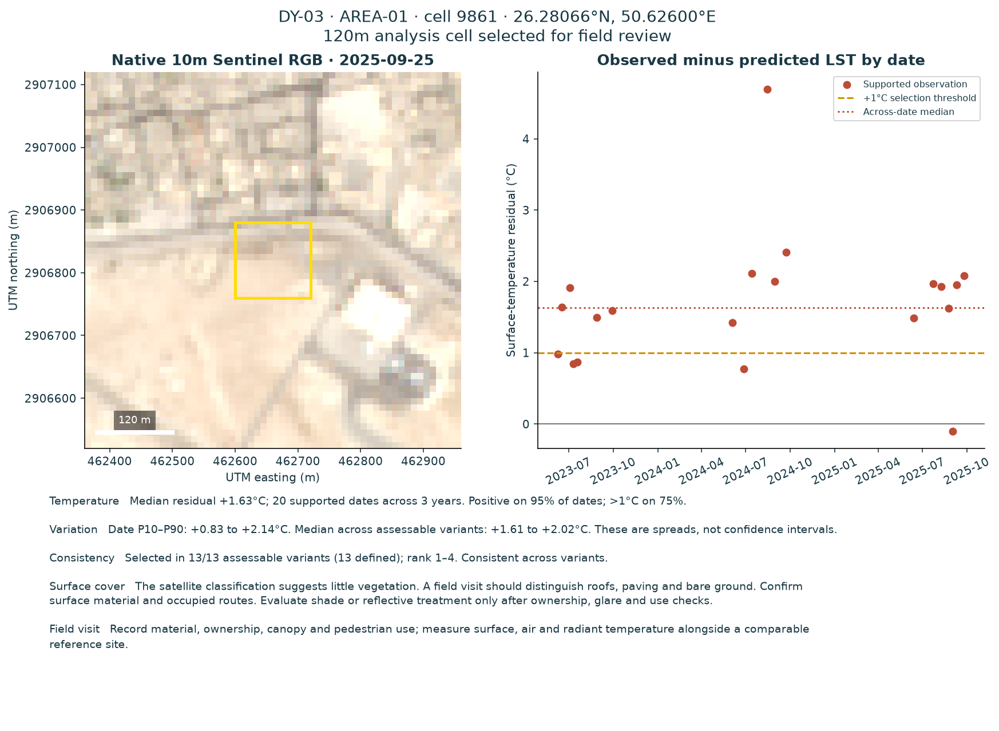

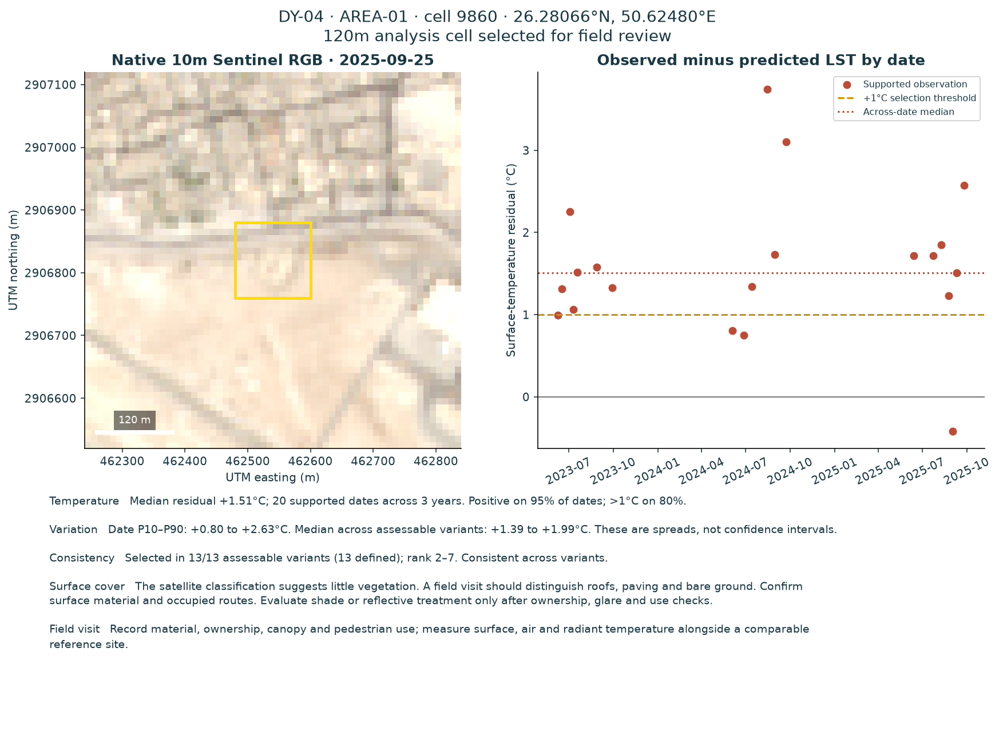

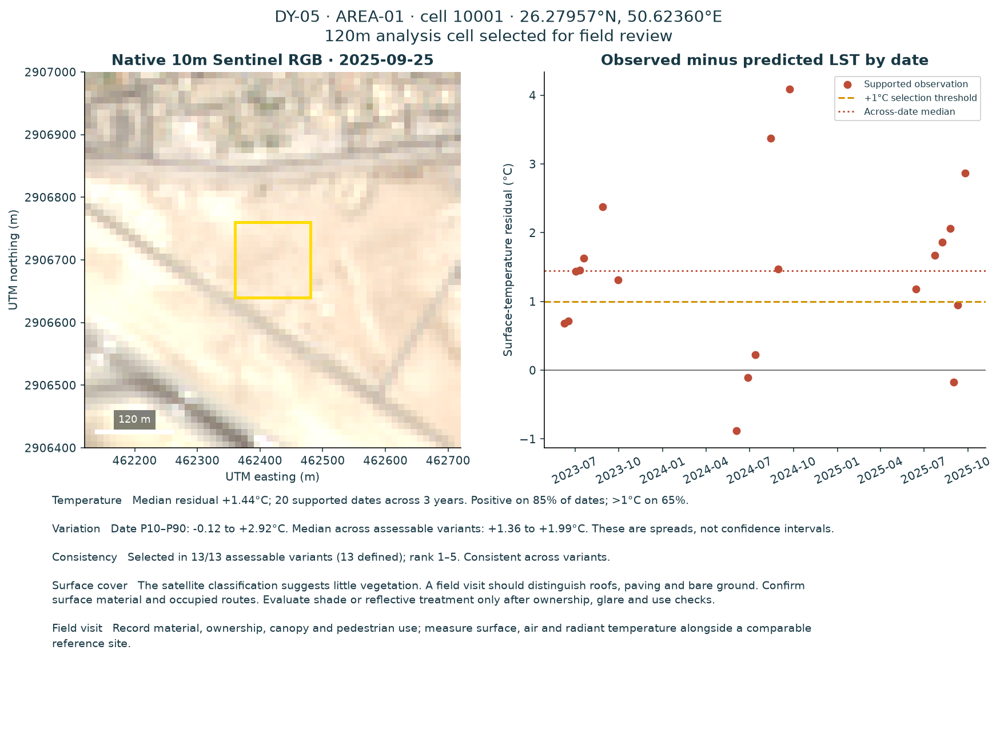

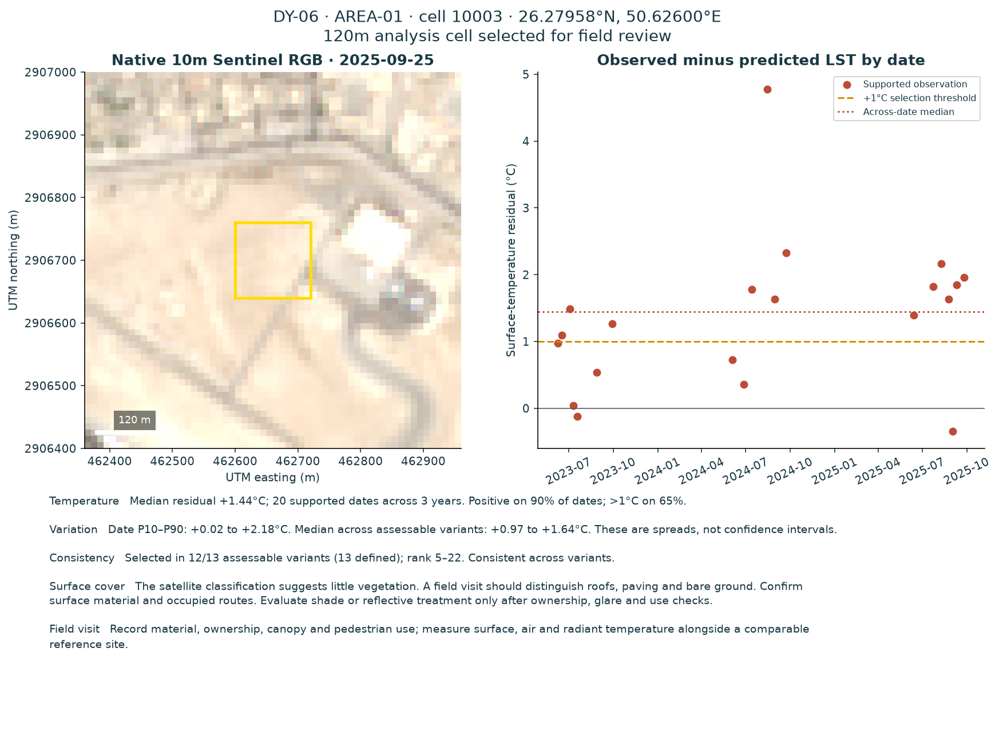

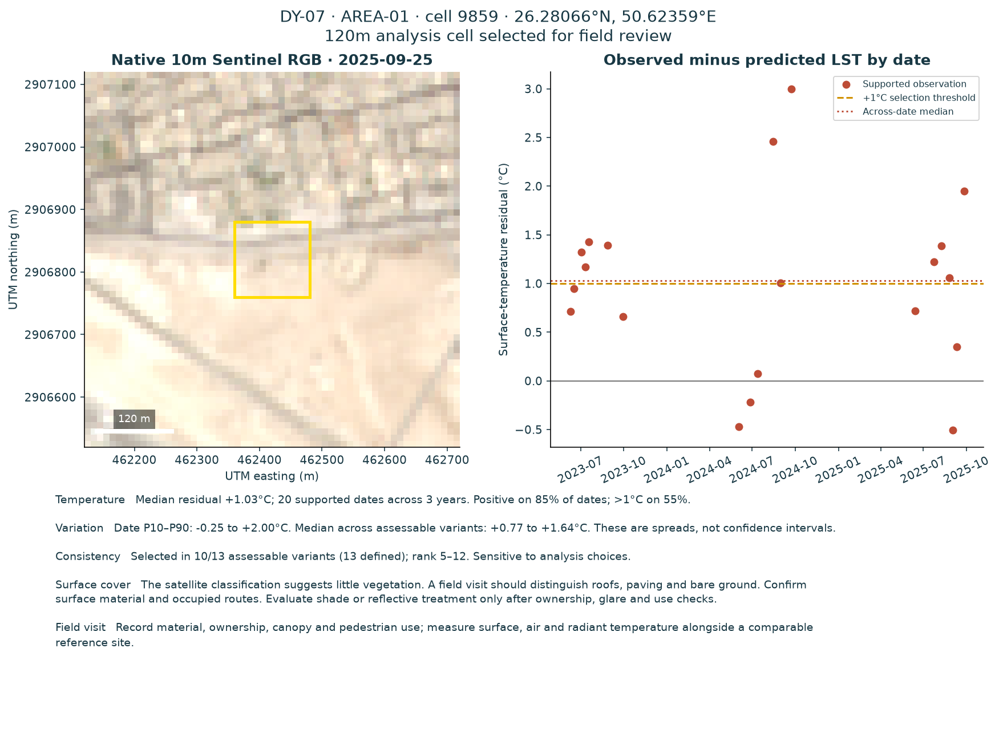

In [61]:
for card in site_cards.iloc[1:].itertuples():
    display(Image(filename=str(OUT/'site_cards'/f'{card.site_id}_cell_{card.cell}.png'),width=1100))

### G. References
Source documentation:

- [USGS quality bands](https://www.usgs.gov/landsat-missions/landsat-collection-2-quality-assessment-bands)
- [USGS surface temperature](https://www.usgs.gov/landsat-missions/landsat-collection-2-surface-temperature)
- [Sentinel processing](https://sentiwiki.copernicus.eu/web/s2-processing)
- [ERA5 dataset](https://doi.org/10.24381/cds.adbb2d47)
- [ERA5 time conventions](https://confluence.ecmwf.int/pages/viewpage.action?pageId=177484060)


In [62]:
audit_table('Recorded execution environment',pd.DataFrame(versions.items(),columns=['Package','Version']))
evidence_link('notebook_summary.json','Download the findings and validation summary')

Package,Version
Python,3.14.8
numpy,2.5.3
pandas,3.0.6
scikit-learn,1.9.1
rasterio,1.5.2
xarray,2026.9.0
icechunk,2.2.2
matplotlib,3.11.2
eccodes,2.49.0
